#0. Configuración global

In [4]:
from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# GUARDAR RESULTADOS ACUMULADOS DE MODELOS
# ============================================================

import os
import pandas as pd
import numpy as np

SENTINEL_RATIO=3
SEQ_LEN = 7
MODEL_RESULTS_PATH = "/content/drive/MyDrive/TFM/model_results_summary.csv"

def save_model_test_results(
    model_name,
    total_training_time_s,
    n_epochs,
    test_metrics,
    csv_path=MODEL_RESULTS_PATH
):
    seconds_per_epoch = (
        total_training_time_s / n_epochs
        if n_epochs is not None and n_epochs > 0
        else np.nan
    )

    new_row = pd.DataFrame([{
        "model": model_name,
        "total_training_time_s": total_training_time_s,
        "n_epochs": n_epochs,
        "seconds_per_epoch": seconds_per_epoch,
        "test_MAE": test_metrics.get("MAE"),
        "test_RMSE": test_metrics.get("RMSE"),
        "test_R2": test_metrics.get("R2"),
        "test_MAPE": test_metrics.get("MAPE"),
        "sentinel_ratio": SENTINEL_RATIO,
        "seq_len": SEQ_LEN

    }])

    if os.path.exists(csv_path):
        old_df = pd.read_csv(csv_path)
        results_df = pd.concat([old_df, new_row], ignore_index=True)
    else:
        results_df = new_row

    results_df.to_csv(csv_path, index=False)

    print("Resultados acumulados guardados en:")
    print(csv_path)

    display(results_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import json

notebook_path = "TFM_LIBORIO_v2.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Eliminar metadata.widgets si existe
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("Notebook limpiado correctamente.")

FileNotFoundError: [Errno 2] No such file or directory: 'TFM_LIBORIO_v2.ipynb'

#1. Creación de dataset

##1.1. Descarga de datos satelitales de Landsat 8/9 desde Google Earth Engine

En esta sección se construye el dataset base del área de estudio en Sevilla.

El proceso incluye:

1. Definición del ROI de aproximadamente 1.5 km × 1.5 km.
2. Creación de una malla de nodos a escala aproximada de 100 m.
3. Descarga de variables temporales desde Landsat 8/9:
   - NDVI
   - LST en Kelvin
4. Descarga de variables estáticas:
   - DEM
   - NDBI
   - ALBEDO
5. Exportación de los resultados a Google Drive.
6. Unión posterior de los CSV temporales y estáticos.

In [ ]:
# ============================================================
# 1. IMPORTS, AUTENTICACIÓN Y CONFIGURACIÓN GENERAL
# ============================================================

import ee
import geemap
import math
import time
import pandas as pd

# Autenticación e inicialización de Google Earth Engine
ee.Authenticate()
ee.Initialize(project="tfm-gnn")

# Carpeta de salida en Google Drive
DRIVE_FOLDER = "TFM"

# Periodo de estudio
START_YEAR = 2013
END_YEAR = 2025

START_DATE = f"{START_YEAR}-01-01"
END_DATE = f"{END_YEAR + 1}-01-01"  # fecha final exclusiva en GEE

# Meses de interés: mayo-octubre
START_MONTH = 5
END_MONTH = 10

# Escala de muestreo
SCALE = 100

print("Google Earth Engine inicializado correctamente.")

Google Earth Engine inicializado correctamente.


In [ ]:
# ============================================================
# 2. DEFINICIÓN DEL ROI Y CREACIÓN DE NODOS A 100 m
# ============================================================

def create_roi(center_lat=37.4035, center_lon=-5.9810, half_side_m=750):
    """
    Crea un ROI cuadrado alrededor de un punto central.

    Parámetros:
    - center_lat, center_lon: centro del área de estudio.
    - half_side_m: mitad del lado del cuadrado en metros.

    Devuelve:
    - roi: geometría rectangular de Earth Engine.
    - bbox: coordenadas min/max del rectángulo.
    """

    meters_per_degree_lat = 111320
    meters_per_degree_lon = 111320 * math.cos(math.radians(center_lat))

    dlat = half_side_m / meters_per_degree_lat
    dlon = half_side_m / meters_per_degree_lon

    min_lat = center_lat - dlat
    max_lat = center_lat + dlat
    min_lon = center_lon - dlon
    max_lon = center_lon + dlon

    roi = ee.Geometry.Rectangle(
        [min_lon, min_lat, max_lon, max_lat],
        proj=None,
        geodesic=False
    )

    bbox = {
        "min_lon": min_lon,
        "min_lat": min_lat,
        "max_lon": max_lon,
        "max_lat": max_lat,
    }

    return roi, bbox


def compute_bbox_size_m(bbox):
    """
    Calcula el ancho, alto y área aproximada del ROI en metros.
    """

    min_lon = bbox["min_lon"]
    min_lat = bbox["min_lat"]
    max_lon = bbox["max_lon"]
    max_lat = bbox["max_lat"]

    mid_lat = (min_lat + max_lat) / 2

    meters_per_degree_lat = 111320
    meters_per_degree_lon = 111320 * math.cos(math.radians(mid_lat))

    width_m = (max_lon - min_lon) * meters_per_degree_lon
    height_m = (max_lat - min_lat) * meters_per_degree_lat
    area_m2 = width_m * height_m

    return width_m, height_m, area_m2


def create_nodes_grid(roi, scale=100):
    """
    Crea una malla aproximada de nodos usando pixelLonLat().
    Cada nodo representa una celda aproximada de 100 m.
    """

    lonlat = ee.Image.pixelLonLat().clip(roi)

    nodes_fc = lonlat.sample(
        region=roi,
        scale=scale,
        geometries=True
    )

    return nodes_fc


roi, bbox = create_roi()
width_m, height_m, area_m2 = compute_bbox_size_m(bbox)
nodes_fc = create_nodes_grid(roi, scale=SCALE)

print("Centro ROI:", (37.4035, -5.9810))
print("BBOX:", bbox)
print(f"Ancho: {width_m:.1f} m | Alto: {height_m:.1f} m | Área: {area_m2 / 1e6:.3f} km²")
print("Número de nodos:", nodes_fc.size().getInfo())

Centro ROI: (37.4035, -5.981)
BBOX: {'min_lon': -5.9894812745475035, 'min_lat': 37.39676266618757, 'max_lon': -5.972518725452496, 'max_lat': 37.41023733381243}
Ancho: 1500.0 m | Alto: 1500.0 m | Área: 2.250 km²
Número de nodos: 270


In [ ]:
# ============================================================
# MAPA INTERACTIVO DEL GRAFO: NODOS + ARISTAS
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import folium
from shapely.geometry import LineString

# ------------------------------------------------------------
# 1. Pasar nodos de Earth Engine a GeoDataFrame
# ------------------------------------------------------------

nodes_gdf = geemap.ee_to_gdf(nodes_fc)

nodes_gdf = nodes_gdf.to_crs("EPSG:4326").copy()

nodes_gdf["longitude"] = nodes_gdf.geometry.x
nodes_gdf["latitude"] = nodes_gdf.geometry.y

# Ordenar espacialmente
nodes_gdf["lat_key"] = nodes_gdf["latitude"].round(6)
nodes_gdf["lon_key"] = nodes_gdf["longitude"].round(6)

lat_vals = np.sort(nodes_gdf["lat_key"].unique())[::-1]  # norte-sur
lon_vals = np.sort(nodes_gdf["lon_key"].unique())        # oeste-este

lat_to_row = {lat: i for i, lat in enumerate(lat_vals)}
lon_to_col = {lon: j for j, lon in enumerate(lon_vals)}

nodes_gdf["row"] = nodes_gdf["lat_key"].map(lat_to_row)
nodes_gdf["col"] = nodes_gdf["lon_key"].map(lon_to_col)

nodes_gdf = nodes_gdf.sort_values(["row", "col"]).reset_index(drop=True)
nodes_gdf["node_id"] = nodes_gdf.index.astype(str)

n_rows = len(lat_vals)
n_cols = len(lon_vals)

print(f"Malla detectada: {n_rows} filas x {n_cols} columnas")
print(f"Nodos totales: {len(nodes_gdf)}")

# ------------------------------------------------------------
# 2. Construir aristas con vecindad Moore 8-neighbors
# ------------------------------------------------------------

pos_to_idx = {
    (int(r.row), int(r.col)): idx
    for idx, r in nodes_gdf.iterrows()
}

displacements = [
    (-1, -1), (-1, 0), (-1, 1),
    ( 0, -1),          ( 0, 1),
    ( 1, -1), ( 1, 0), ( 1, 1)
]

edges = []

for idx, r in nodes_gdf.iterrows():
    row = int(r["row"])
    col = int(r["col"])

    for dr, dc in displacements:
        neigh_pos = (row + dr, col + dc)

        if neigh_pos in pos_to_idx:
            neigh_idx = pos_to_idx[neigh_pos]

            # Evitar duplicar visualmente aristas
            if idx < neigh_idx:
                edges.append((idx, neigh_idx))

print(f"Aristas visuales: {len(edges)}")

# ------------------------------------------------------------
# 3. Crear GeoDataFrame de aristas
# ------------------------------------------------------------

edge_geoms = []

for i, j in edges:
    p1 = nodes_gdf.loc[i].geometry
    p2 = nodes_gdf.loc[j].geometry
    edge_geoms.append(LineString([p1, p2]))

edges_gdf = gpd.GeoDataFrame(
    {"edge_id": range(len(edge_geoms))},
    geometry=edge_geoms,
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# 4. Crear mapa interactivo
# ------------------------------------------------------------

center_lat = nodes_gdf["latitude"].mean()
center_lon = nodes_gdf["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=15,
    tiles="CartoDB positron"
)

# ROI
roi_coords = [
    [bbox["min_lat"], bbox["min_lon"]],
    [bbox["min_lat"], bbox["max_lon"]],
    [bbox["max_lat"], bbox["max_lon"]],
    [bbox["max_lat"], bbox["min_lon"]],
    [bbox["min_lat"], bbox["min_lon"]],
]

folium.PolyLine(
    roi_coords,
    color="red",
    weight=3,
    tooltip="ROI"
).add_to(m)

# Aristas
for _, edge in edges_gdf.iterrows():
    coords = [(lat, lon) for lon, lat in edge.geometry.coords]

    folium.PolyLine(
        coords,
        color="gray",
        weight=1,
        opacity=0.5
    ).add_to(m)

# Nodos
for _, node in nodes_gdf.iterrows():
    folium.CircleMarker(
        location=[node["latitude"], node["longitude"]],
        radius=3,
        color="blue",
        fill=True,
        fill_opacity=0.8,
        popup=(
            f"node_id: {node['node_id']}<br>"
            f"row: {node['row']}<br>"
            f"col: {node['col']}"
        )
    ).add_to(m)

m

Malla detectada: 15 filas x 18 columnas
Nodos totales: 270
Aristas visuales: 983


In [ ]:
# ============================================================
# 4. FUNCIONES DE PROCESADO LANDSAT 8/9
# ============================================================

def mask_landsat_l2(img):
    """
    Aplica máscara de calidad a Landsat Collection 2 Level-2.

    Se eliminan píxeles con:
    - nubes
    - sombras de nubes
    - nieve
    - cirros
    """

    qa = img.select("QA_PIXEL")

    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloud_shadow = qa.bitwiseAnd(1 << 4).eq(0)
    snow = qa.bitwiseAnd(1 << 5).eq(0)
    cirrus = qa.bitwiseAnd(1 << 7).eq(0)

    mask = cloud.And(cloud_shadow).And(snow).And(cirrus)

    return img.updateMask(mask)


def scale_sr_band(img, band_name):
    """
    Escala una banda de reflectancia de superficie Landsat L2.
    Fórmula oficial:
    reflectancia = DN * 2.75e-05 - 0.2
    """

    return img.select(band_name).multiply(2.75e-05).add(-0.2)


def add_ndvi_lst(img):
    """
    Añade NDVI y LST_K a una imagen Landsat.

    NDVI:
    - RED: SR_B4
    - NIR: SR_B5

    LST:
    - ST_B10 escalada a Kelvin.
    """

    red = scale_sr_band(img, "SR_B4")
    nir = scale_sr_band(img, "SR_B5")

    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")

    lst_k = img.select("ST_B10").multiply(0.00341802).add(149.0).rename("LST_K")

    return (
        img.addBands(ndvi)
           .addBands(lst_k)
           .select(["NDVI", "LST_K"])
           .copyProperties(img, ["system:time_start"])
    )


def add_ndbi(img):
    """
    Añade NDBI a partir de:
    - NIR: SR_B5
    - SWIR1: SR_B6
    """

    nir = scale_sr_band(img, "SR_B5")
    swir = scale_sr_band(img, "SR_B6")

    ndbi = swir.subtract(nir).divide(swir.add(nir)).rename("NDBI")

    return img.addBands(ndbi)


def add_albedo(img):
    """
    Calcula una aproximación sencilla de albedo como media de:
    - Blue
    - Green
    - Red
    - NIR
    """

    blue = scale_sr_band(img, "SR_B2")
    green = scale_sr_band(img, "SR_B3")
    red = scale_sr_band(img, "SR_B4")
    nir = scale_sr_band(img, "SR_B5")

    albedo = blue.add(green).add(red).add(nir).divide(4).rename("ALBEDO")

    return img.addBands(albedo)

In [ ]:
# ============================================================
# 5. CONSTRUCCIÓN DE COLECCIONES LANDSAT 8/9
# ============================================================

def get_landsat_collection(roi, start_date, end_date):
    """
    Carga y fusiona Landsat 8 y Landsat 9 Collection 2 Level-2.
    Filtra espacialmente, temporalmente y por meses de interés.
    """

    l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

    collection = (
        l8.merge(l9)
          .filterBounds(roi)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.calendarRange(START_MONTH, END_MONTH, "month"))
    )

    return collection


landsat_raw = get_landsat_collection(
    roi=roi,
    start_date=START_DATE,
    end_date=END_DATE
)

landsat_temporal = (
    landsat_raw
    .map(mask_landsat_l2)
    .map(add_ndvi_lst)
)

print("Imágenes Landsat disponibles:", landsat_raw.size().getInfo())
print("Imágenes Landsat procesadas:", landsat_temporal.size().getInfo())

Imágenes Landsat disponibles: 188
Imágenes Landsat procesadas: 188


In [ ]:
# ============================================================
# 6. PREVISUALIZACIÓN DE NDVI Y LST
# ============================================================

first_img = ee.Image(landsat_temporal.first())

Map_preview = geemap.Map()
Map_preview.centerObject(roi, 15)

Map_preview.addLayer(roi, {"color": "red"}, "ROI")
Map_preview.addLayer(
    first_img.select("NDVI"),
    {"min": 0.0, "max": 1.0},
    "NDVI primera imagen"
)
Map_preview.addLayer(
    first_img.select("LST_K"),
    {"min": 280, "max": 320},
    "LST_K primera imagen"
)

Map_preview

Map(center=[37.40349989980162, -5.980999999984676], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
# ============================================================
# 7. EXPORTACIÓN DE SERIE TEMPORAL: NDVI + LST
# ============================================================

def sample_temporal_image_to_nodes(img):
    """
    Extrae NDVI y LST_K para todos los nodos de una imagen Landsat.
    Añade:
    - date
    - time_start
    """

    ts = ee.Number(img.get("system:time_start"))
    date_str = ee.Date(ts).format("YYYY-MM-dd")

    samples = img.sampleRegions(
        collection=nodes_fc,
        scale=SCALE,
        geometries=True
    )

    return samples.map(
        lambda f: f.set({
            "date": date_str,
            "time_start": ts
        })
    )


samples_temporal_fc = landsat_temporal.map(sample_temporal_image_to_nodes).flatten()

print("Filas temporales estimadas:", samples_temporal_fc.size().getInfo())

task_ts = ee.batch.Export.table.toDrive(
    collection=samples_temporal_fc,
    description="Sevilla_TS_NDVI_LST_timeStart",
    folder=DRIVE_FOLDER,
    fileFormat="CSV"
)

task_ts.start()

print("Exportación lanzada: Sevilla_TS_NDVI_LST_timeStart")

Filas temporales estimadas: 40539
Exportación lanzada: Sevilla_TS_NDVI_LST_timeStart


In [ ]:
# ============================================================
# 8. EXPORTACIÓN DE VARIABLES ESTÁTICAS: DEM, NDBI Y ALBEDO
# ============================================================

dem = (
    ee.Image("USGS/SRTMGL1_003")
    .select("elevation")
    .rename("DEM")
    .clip(roi)
)

ndbi_static = (
    landsat_raw
    .map(mask_landsat_l2)
    .map(add_ndbi)
    .select("NDBI")
    .median()
    .clip(roi)
)

albedo_static = (
    landsat_raw
    .map(mask_landsat_l2)
    .map(add_albedo)
    .select("ALBEDO")
    .median()
    .clip(roi)
)

static_img = dem.addBands(ndbi_static).addBands(albedo_static)

nodes_static_fc = static_img.sampleRegions(
    collection=nodes_fc,
    scale=SCALE,
    geometries=True
)

print("Filas estáticas estimadas:", nodes_static_fc.size().getInfo())

task_static = ee.batch.Export.table.toDrive(
    collection=nodes_static_fc,
    description="Sevilla_nodes_static_DEM_NDBI_ALBEDO",
    folder=DRIVE_FOLDER,
    fileFormat="CSV"
)

task_static.start()

print("Exportación lanzada: Sevilla_nodes_static_DEM_NDBI_ALBEDO")

Filas estáticas estimadas: 270
Exportación lanzada: Sevilla_nodes_static_DEM_NDBI_ALBEDO


In [ ]:
# ============================================================
# 9. COMPROBACIÓN DEL ESTADO DE EXPORTACIONES
# ============================================================

def wait_for_task(task, task_name, sleep_seconds=20):
    """
    Espera hasta que una tarea de Earth Engine termine.
    """

    while task.active():
        status = task.status()
        print(f"Exportando {task_name}... Estado: {status['state']}")
        time.sleep(sleep_seconds)

    final_status = task.status()

    print(f"Estado final de {task_name}: {final_status['state']}")
    print(final_status)


wait_for_task(task_ts, "serie temporal NDVI + LST")
wait_for_task(task_static, "variables estáticas")

Estado final de serie temporal NDVI + LST: COMPLETED
{'state': 'COMPLETED', 'description': 'Sevilla_TS_NDVI_LST_timeStart', 'priority': 100, 'creation_timestamp_ms': 1778927629858, 'update_timestamp_ms': 1778927763563, 'start_timestamp_ms': 1778927631784, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/1jy8BN3jzDy-Gdr__zmR1xydUYRoyySUC'], 'attempt': 1, 'batch_eecu_usage_seconds': 52.40755844116211, 'id': 'ISHANZQEVYCDFX576GBCRJ43', 'name': 'projects/tfm-gnn/operations/ISHANZQEVYCDFX576GBCRJ43'}
Exportando variables estáticas... Estado: READY
Estado final de variables estáticas: COMPLETED
{'state': 'COMPLETED', 'description': 'Sevilla_nodes_static_DEM_NDBI_ALBEDO', 'priority': 100, 'creation_timestamp_ms': 1778927764605, 'update_timestamp_ms': 1778927776133, 'start_timestamp_ms': 1778927772737, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/1jy8BN3jzDy-Gdr__zmR1xydUYRoyySUC'], 'attempt': 1, 'batch_eecu_usag

## 1.2 Unión de datos temporales y estáticos de Landsat

Una vez finalizadas las exportaciones desde Google Earth Engine, se cargan los dos CSV generados:

- `Sevilla_TS_NDVI_LST_timeStart.csv`
- `Sevilla_nodes_static_DEM_NDBI_ALBEDO.csv`

Después se crea un identificador estable de nodo y se unen las variables estáticas a cada observación temporal.

In [ ]:
# ============================================================
# 10. CARGA DE CSVs EXPORTADOS DESDE GOOGLE EARTH ENGINE
# ============================================================

TS_PATH = "/content/drive/MyDrive/TFM/Sevilla_TS_NDVI_LST_timeStart.csv"
STATIC_PATH = "/content/drive/MyDrive/TFM/Sevilla_nodes_static_DEM_NDBI_ALBEDO.csv"

df_ts = pd.read_csv(TS_PATH)
df_static = pd.read_csv(STATIC_PATH)

print("df_ts:", df_ts.shape)
print("df_static:", df_static.shape)

display(df_ts.head())
display(df_static.head())

df_ts: (40539, 8)
df_static: (270, 7)


,system:index,LST_K,NDVI,date,latitude,longitude,time_start,.geo
0,1_LC08_202034_20130505_0_0,307.756775,0.168248,2013-05-05,37.397314,-5.988619,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1_LC08_202034_20130505_1_0,308.665968,0.115894,2013-05-05,37.397314,-5.987721,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,1_LC08_202034_20130505_2_0,308.057561,0.176459,2013-05-05,37.397314,-5.986822,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,1_LC08_202034_20130505_3_0,308.266060,0.212276,2013-05-05,37.397314,-5.985924,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,1_LC08_202034_20130505_4_0,309.530727,0.127058,2013-05-05,37.397314,-5.985026,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


,system:index,ALBEDO,DEM,NDBI,latitude,longitude,.geo
0,0_0,0.167382,15,0.109885,37.397314,-5.988619,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1_0,0.182070,14,0.116722,37.397314,-5.987721,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2_0,0.170697,11,0.086520,37.397314,-5.986822,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3_0,0.189823,11,0.116592,37.397314,-5.985924,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4_0,0.189981,9,0.119788,37.397314,-5.985026,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [ ]:
# ============================================================
# 11. LIMPIEZA DE COLUMNAS Y CREACIÓN DE IDENTIFICADOR DE NODO
# ============================================================

def find_col(df, candidates):
    """
    Busca la primera columna existente dentro de una lista de nombres candidatos.
    """

    for c in candidates:
        if c in df.columns:
            return c

    return None


def standardize_lat_lon(df, df_name):
    """
    Normaliza los nombres de columnas de coordenadas a:
    - lat
    - lon
    """

    lat_col = find_col(df, ["latitude", "lat", "latitude_1", "lat_1"])
    lon_col = find_col(df, ["longitude", "lon", "longitude_1", "lon_1"])

    if lat_col is None or lon_col is None:
        raise ValueError(
            f"No encuentro columnas lat/lon en {df_name}. "
            f"Columnas disponibles: {df.columns.tolist()}"
        )

    return df.rename(columns={
        lat_col: "lat",
        lon_col: "lon"
    })


df_ts = standardize_lat_lon(df_ts, "df_ts")
df_static = standardize_lat_lon(df_static, "df_static")

# Conversión de tipos principales
for col in ["time_start", "NDVI", "LST_K"]:
    if col in df_ts.columns:
        df_ts[col] = pd.to_numeric(df_ts[col], errors="coerce")

for col in ["DEM", "NDBI", "ALBEDO"]:
    if col in df_static.columns:
        df_static[col] = pd.to_numeric(df_static[col], errors="coerce")

print("Columnas temporales:", df_ts.columns.tolist())
print("Columnas estáticas:", df_static.columns.tolist())

Columnas temporales: ['system:index', 'LST_K', 'NDVI', 'date', 'lat', 'lon', 'time_start', '.geo']
Columnas estáticas: ['system:index', 'ALBEDO', 'DEM', 'NDBI', 'lat', 'lon', '.geo']


In [ ]:
# ============================================================
# 12. UNIÓN DE VARIABLES TEMPORALES Y ESTÁTICAS
# ============================================================

def add_node_key_from_system_index(df_ts, df_static):
    """
    Crea un identificador estable de nodo usando system:index.

    En el CSV estático, system:index suele corresponder directamente al nodo.
    En el CSV temporal, system:index suele terminar en el patrón del nodo.
    """

    df_static = df_static.copy()
    df_ts = df_ts.copy()

    df_static["node_key"] = df_static["system:index"].astype(str)

    df_ts["node_key"] = (
        df_ts["system:index"]
        .astype(str)
        .str.extract(r"(\d+_\d+)$")[0]
    )

    node_map = (
        pd.DataFrame({"node_key": pd.unique(df_static["node_key"])})
        .dropna()
        .sort_values("node_key")
        .reset_index(drop=True)
    )

    node_map["node_id"] = range(len(node_map))

    df_static = df_static.merge(node_map, on="node_key", how="left")
    df_ts = df_ts.merge(node_map, on="node_key", how="left")

    return df_ts, df_static, node_map


df_ts, df_static, node_map = add_node_key_from_system_index(df_ts, df_static)

static_cols = ["node_key", "DEM", "NDBI", "ALBEDO"]

df_static_small = (
    df_static[static_cols]
    .drop_duplicates("node_key")
)

df_final = df_ts.merge(
    df_static_small,
    on="node_key",
    how="left"
)

print("Filas finales:", df_final.shape)
print("Nodos únicos:", df_final["node_id"].nunique())

print("\nNulos en variables estáticas:")
print(df_final[["DEM", "NDBI", "ALBEDO"]].isna().sum())

display(df_final.head())

Filas finales: (40539, 13)
Nodos únicos: 270

Nulos en variables estáticas:
DEM       0
NDBI      0
ALBEDO    0
dtype: int64


,system:index,LST_K,NDVI,date,lat,lon,time_start,.geo,node_key,node_id,DEM,NDBI,ALBEDO
0,1_LC08_202034_20130505_0_0,307.756775,0.168248,2013-05-05,37.397314,-5.988619,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",0_0,0,15,0.109885,0.167382
1,1_LC08_202034_20130505_1_0,308.665968,0.115894,2013-05-05,37.397314,-5.987721,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1_0,111,14,0.116722,0.182070
2,1_LC08_202034_20130505_2_0,308.057561,0.176459,2013-05-05,37.397314,-5.986822,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",2_0,192,11,0.086520,0.170697
3,1_LC08_202034_20130505_3_0,308.266060,0.212276,2013-05-05,37.397314,-5.985924,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",3_0,203,11,0.116592,0.189823
4,1_LC08_202034_20130505_4_0,309.530727,0.127058,2013-05-05,37.397314,-5.985026,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",4_0,214,9,0.119788,0.189981


In [ ]:
# ============================================================
# 13. GUARDAR DATASET FINAL
# ============================================================

OUTPUT_PATH = "/content/drive/MyDrive/TFM/sevilla_ts_static_merged.csv"

df_final.to_csv(OUTPUT_PATH, index=False)

print("Dataset final guardado en:")
print(OUTPUT_PATH)
print("Shape final:", df_final.shape)

Dataset final guardado en:
/content/drive/MyDrive/TFM/sevilla_ts_static_merged.csv
Shape final: (40539, 13)


##1.3 Downscaling para obtener más registros de LST

###1.3.1 Datos para entrenar el modelo de downscaling


In [ ]:
import pandas as pd
import numpy as np

INPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio_fixed.csv"

df = pd.read_csv(INPUT_CSV)

df["date"] = pd.to_datetime(df["date"])

cols = [
    "node_id",
    "date",
    "latitude",
    "longitude",
    "row",
    "col",
    "LST_K",
    "NDVI",
    "NDBI",
    "ALBEDO",
    "aspect_ratio"
]

df = df[cols].copy()

print("Shape:", df.shape)
print("Fechas:", df["date"].nunique())
print("Nodos:", df["node_id"].nunique())

display(df.head())

Shape: (40539, 11)
Fechas: 161
Nodos: 270


,node_id,date,latitude,longitude,row,col,LST_K,NDVI,NDBI,ALBEDO,aspect_ratio
0,0,2013-05-05,37.397314,-5.988619,14,0,307.756775,0.168248,0.108977,0.153776,0.4604
1,1,2013-05-05,37.397314,-5.987721,14,1,308.665968,0.115894,0.114731,0.167390,0.5165
2,2,2013-05-05,37.397314,-5.986822,14,2,308.057561,0.176459,0.085371,0.156572,0.5548
3,3,2013-05-05,37.397314,-5.985924,14,3,308.266060,0.212276,0.114006,0.171174,0.2873
4,4,2013-05-05,37.397314,-5.985026,14,4,309.530727,0.127058,0.122376,0.184999,0.3580


In [ ]:
# ============================================================
# AGREGACIÓN ESPACIAL 100 m → 1 km
# ============================================================

BLOCK_SIZE = 10

df["block_row"] = (df["row"] // BLOCK_SIZE).astype(int)
df["block_col"] = (df["col"] // BLOCK_SIZE).astype(int)

df["pixel_1km_id"] = (
    df["block_row"].astype(str) + "_" + df["block_col"].astype(str)
)

print("Píxeles 1 km aproximados:", df["pixel_1km_id"].nunique())

display(
    df[["node_id", "row", "col", "pixel_1km_id"]]
    .drop_duplicates()
    .head()
)

Píxeles 1 km aproximados: 4


,node_id,row,col,pixel_1km_id
0,0,14,0,1_0
1,1,14,1,1_0
2,2,14,2,1_0
3,3,14,3,1_0
4,4,14,4,1_0


In [ ]:
# ============================================================
# VARIABLES A ESCALA 1 km
# ============================================================

agg_1km = (
    df.groupby(["date", "pixel_1km_id"])
    .agg(
        LST_1km=("LST_K", "mean"),
        NDVI_1km=("NDVI", "mean"),
        NDBI_1km=("NDBI", "mean"),
        ALBEDO_1km=("ALBEDO", "mean"),
        aspect_ratio_1km=("aspect_ratio", "mean")
    )
    .reset_index()
)

print("Dataset 1 km:", agg_1km.shape)
display(agg_1km.head())

Dataset 1 km: (625, 7)


,date,pixel_1km_id,LST_1km,NDVI_1km,NDBI_1km,ALBEDO_1km,aspect_ratio_1km
0,2013-05-05,0_0,309.054529,0.184731,0.016234,0.146557,0.391749
1,2013-05-05,0_1,307.663164,0.188660,0.032922,0.145583,0.385544
2,2013-05-05,1_0,308.450975,0.162444,0.064541,0.158349,0.517482
3,2013-05-05,1_1,308.400901,0.185367,0.040698,0.157452,0.247463
4,2013-05-21,0_0,310.094256,0.183545,0.016234,0.146557,0.391749


In [ ]:
# ============================================================
# DATASET SUPERVISADO 1 km → 100 m
# ============================================================

df_down = df.merge(
    agg_1km,
    on=["date", "pixel_1km_id"],
    how="left"
)

# Diferencias locales respecto al píxel grueso
df_down["NDVI_delta"] = df_down["NDVI"] - df_down["NDVI_1km"]
df_down["NDBI_delta"] = df_down["NDBI"] - df_down["NDBI_1km"]
df_down["ALBEDO_delta"] = df_down["ALBEDO"] - df_down["ALBEDO_1km"]
df_down["aspect_ratio_delta"] = df_down["aspect_ratio"] - df_down["aspect_ratio_1km"]

features = [
    "LST_1km",
    "NDVI_1km",
    "NDVI_delta",
    "NDBI_delta",
    "ALBEDO_delta",
    "aspect_ratio_delta"
]

target = "LST_K"

df_model = df_down[
    [
        "date",
        "node_id",
        "latitude",
        "longitude",
        "pixel_1km_id",
        target
    ] + features
].copy()

print("Dataset para downscaling:", df_model.shape)
print("NaNs:")
print(df_model.isna().sum())

display(df_model.head())

Dataset para downscaling: (40539, 12)
NaNs:
date                  0
node_id               0
latitude              0
longitude             0
pixel_1km_id          0
LST_K                 0
LST_1km               0
NDVI_1km              0
NDVI_delta            0
NDBI_delta            0
ALBEDO_delta          0
aspect_ratio_delta    0
dtype: int64


,date,node_id,latitude,longitude,pixel_1km_id,LST_K,LST_1km,NDVI_1km,NDVI_delta,NDBI_delta,ALBEDO_delta,aspect_ratio_delta
0,2013-05-05,0,37.397314,-5.988619,1_0,307.756775,308.450975,0.162444,0.005805,0.044435,-0.004573,-0.057082
1,2013-05-05,1,37.397314,-5.987721,1_0,308.665968,308.450975,0.162444,-0.046549,0.050190,0.009041,-0.000982
2,2013-05-05,2,37.397314,-5.986822,1_0,308.057561,308.450975,0.162444,0.014015,0.020830,-0.001777,0.037318
3,2013-05-05,3,37.397314,-5.985924,1_0,308.266060,308.450975,0.162444,0.049832,0.049464,0.012826,-0.230182
4,2013-05-05,4,37.397314,-5.985026,1_0,309.530727,308.450975,0.162444,-0.035385,0.057835,0.026650,-0.159482


In [ ]:
# ============================================================
# SPLIT TEMPORAL TRAIN / VALIDATION / TEST
# ============================================================

dates = np.array(sorted(df_model["date"].unique()))

n_dates = len(dates)

train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = dates[:train_end]
val_dates = dates[train_end:val_end]
test_dates = dates[val_end:]

train_df = df_model[df_model["date"].isin(train_dates)].copy()
val_df = df_model[df_model["date"].isin(val_dates)].copy()
test_df = df_model[df_model["date"].isin(test_dates)].copy()

print("Fechas totales:", n_dates)
print("Train fechas:", len(train_dates), "| filas:", len(train_df))
print("Val fechas:", len(val_dates), "| filas:", len(val_df))
print("Test fechas:", len(test_dates), "| filas:", len(test_df))

Fechas totales: 161
Train fechas: 112 | filas: 28090
Val fechas: 24 | filas: 5981
Test fechas: 25 | filas: 6468


In [ ]:
# ============================================================
# GUARDAR DATASETS
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

df_model.to_csv(f"{BASE_PATH}/downscaling_dataset_1km_to_100m.csv", index=False)
train_df.to_csv(f"{BASE_PATH}/downscaling_train.csv", index=False)
val_df.to_csv(f"{BASE_PATH}/downscaling_val.csv", index=False)
test_df.to_csv(f"{BASE_PATH}/downscaling_test.csv", index=False)

print("Guardado:")
print(f"{BASE_PATH}/downscaling_dataset_1km_to_100m.csv")
print(f"{BASE_PATH}/downscaling_train.csv")
print(f"{BASE_PATH}/downscaling_val.csv")
print(f"{BASE_PATH}/downscaling_test.csv")

Guardado:
/content/drive/MyDrive/TFM/downscaling_dataset_1km_to_100m.csv
/content/drive/MyDrive/TFM/downscaling_train.csv
/content/drive/MyDrive/TFM/downscaling_val.csv
/content/drive/MyDrive/TFM/downscaling_test.csv


###1.3.2 Modelo de downscaling

In [ ]:
# ============================================================
# MODELO RESIDUAL DE DOWNSCALING
# ============================================================

!pip -q install xgboost

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

BASE_PATH = "/content/drive/MyDrive/TFM"

DATASET = f"{BASE_PATH}/downscaling_dataset_1km_to_100m.csv"

df = pd.read_csv(DATASET)
df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")

# Target residual
df["Delta_LST"] = df["LST_K"] - df["LST_1km"]

features = [
    "LST_1km",
    "NDVI_1km",
    "NDVI_delta",
    "NDBI_delta",
    "ALBEDO_delta",
    "aspect_ratio_delta",
]

target = "Delta_LST"

df = df.dropna(subset=features + [target, "LST_K", "date"]).copy()

print("Shape usable:", df.shape)
print("Fechas:", df["date"].nunique())

Shape usable: (40539, 13)
Fechas: 161


In [ ]:
# ============================================================
# SPLIT POR FECHAS, COMO EN TU VERSIÓN ANTERIOR
# ============================================================

X = df[features]
y = df[target]
groups = df["date"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

print("Train filas:", len(df_train), "| fechas:", df_train["date"].nunique())
print("Test filas:", len(df_test), "| fechas:", df_test["date"].nunique())

Train filas: 32152 | fechas: 128
Test filas: 8387 | fechas: 33


In [ ]:
# ============================================================
# BASELINE
# ============================================================

y_true_lst = df_test["LST_K"].values
y_pred_baseline = df_test["LST_1km"].values

mae_base = mean_absolute_error(y_true_lst, y_pred_baseline)
rmse_base = mean_squared_error(y_true_lst, y_pred_baseline) ** 0.5
r2_base = r2_score(y_true_lst, y_pred_baseline)

print("BASELINE")
print("MAE :", mae_base)
print("RMSE:", rmse_base)
print("R2  :", r2_base)

BASELINE
MAE : 0.621510859632826
RMSE: 0.8824209394250216
R2  : 0.9877091995286139


In [ ]:
# ============================================================
# XGBOOST RESIDUAL
# ============================================================

model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    reg_alpha=0.1,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

delta_pred = model.predict(X_test)

df_test["Delta_pred"] = delta_pred
df_test["LST_pred"] = df_test["LST_1km"] + df_test["Delta_pred"]

y_pred_lst = df_test["LST_pred"].values

mae_xgb = mean_absolute_error(y_true_lst, y_pred_lst)
rmse_xgb = mean_squared_error(y_true_lst, y_pred_lst) ** 0.5
r2_xgb = r2_score(y_true_lst, y_pred_lst)

print("XGBOOST RESIDUAL")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

print("\nMejora MAE:", mae_base - mae_xgb)
print("Mejora RMSE:", rmse_base - rmse_xgb)

XGBOOST RESIDUAL
MAE : 0.42578579391360544
RMSE: 0.7252729427656244
R2  : 0.9916970674516636

Mejora MAE: 0.1957250657192206
Mejora RMSE: 0.15714799665939727


In [ ]:
import joblib
import os

MODEL_PATH = os.path.join(BASE_PATH, "modelo_downscaling_xgb.pkl")

joblib.dump(model, MODEL_PATH)

print("Modelo guardado en:")
print(MODEL_PATH)

Modelo guardado en:
/content/drive/MyDrive/TFM/modelo_downscaling_xgb.pkl


In [ ]:
# ============================================================
# DIAGNÓSTICO: ¿EL BASELINE ES DEMASIADO FUERTE?
# ============================================================

diag = (
    df.groupby(["date", "pixel_1km_id"])
    .agg(
        n_nodes=("node_id", "nunique"),
        LST_mean=("LST_K", "mean"),
        LST_std=("LST_K", "std"),
        LST_min=("LST_K", "min"),
        LST_max=("LST_K", "max")
    )
    .reset_index()
)

print("Tamaño de bloques 1km:")
print(diag["n_nodes"].describe())

print("\nVariabilidad térmica interna por bloque:")
print(diag["LST_std"].describe())

display(diag.sort_values("LST_std").head(10))
display(diag.sort_values("LST_std", ascending=False).head(10))

Tamaño de bloques 1km:
count    625.00000
mean      64.86240
std       25.86411
min        1.00000
25%       40.00000
50%       50.00000
75%       80.00000
max      100.00000
Name: n_nodes, dtype: float64

Variabilidad térmica interna por bloque:
count    622.000000
mean       0.743159
std        0.377520
min        0.000000
25%        0.593873
50%        0.677887
75%        0.763571
max        4.208179
Name: LST_std, dtype: float64


,date,pixel_1km_id,n_nodes,LST_mean,LST_std,LST_min,LST_max
262,2019-10-29,1_1,2,297.707796,0.000000,297.707796,297.707796
261,2019-10-29,0_1,3,299.463519,0.098847,299.375790,299.570617
92,2015-06-12,0_0,2,306.095617,0.169183,305.975987,306.215248
307,2020-10-31,1_1,40,299.521141,0.318184,298.941701,300.281565
496,2023-10-24,0_1,80,296.291070,0.355025,295.516845,297.130151
603,2025-08-26,1_0,50,305.488645,0.371986,304.619033,306.509198
259,2019-10-13,1_1,40,305.691436,0.377190,304.813860,306.488690
616,2025-09-27,1_1,40,299.580444,0.387701,298.893849,300.561843
485,2023-09-14,0_1,6,313.973584,0.391994,313.348656,314.459512
260,2019-10-29,0_0,13,298.765279,0.395013,298.258097,299.358700


,date,pixel_1km_id,n_nodes,LST_mean,LST_std,LST_min,LST_max
359,2022-06-15,0_1,7,299.007620,4.208179,291.281919,303.501340
492,2023-10-08,0_1,47,297.130223,3.447406,287.963021,299.741518
113,2016-05-29,0_1,18,301.318554,3.222423,292.153514,305.794831
52,2014-06-25,0_0,62,312.176661,3.160342,305.206932,315.826720
590,2025-07-25,0_1,80,316.528440,2.959756,309.390589,320.263310
114,2016-05-29,1_0,19,305.383050,2.894893,298.398236,308.590772
568,2025-05-30,1_1,4,285.121792,2.737428,281.882364,288.294569
309,2021-05-11,0_1,69,303.961534,2.668028,297.191675,308.419871
358,2022-06-15,0_0,39,303.539727,2.390641,298.589645,307.421809
574,2025-06-23,0_1,80,314.879630,2.287026,309.082967,318.045015


###1.3.3 Descarga de LST de Sentinel 3 SLSTR

In [ ]:
# ============================================================
# SENTINEL-3 SLSTR CON SENTINEL HUB PROCESS API
# 2019-2025 | MAYO-OCTUBRE | UNA TOMA DE MAÑANA POR DÍA
# Usa tus 270 nodos reales desde CSV existente
# ============================================================

!pip -q install requests pandas numpy rasterio pyproj tqdm

import os
import math
import getpass
import requests
import numpy as np
import pandas as pd
from tqdm import tqdm
from rasterio.io import MemoryFile
from pyproj import Transformer
from google.colab import drive

drive.mount("/content/drive")

# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

OUTPUT_CSV = os.path.join(
    BASE_PATH,
    "datos_sentinel_3_slstr_f1_2013_2025_mayo_octubre.csv"
)

START_YEAR = 2013
END_YEAR = 2025
MONTHS = [5, 6, 7, 8, 9, 10]

MORNING_START_HOUR_UTC = 7
MORNING_END_HOUR_UTC = 13
TARGET_MORNING_HOUR_UTC = 10

TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"
CATALOG_URL = "https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/search"

COLLECTION_SH = "sentinel-3-slstr"

# ============================================================
# 2. CREDENCIALES SENTINEL HUB
# ============================================================

CLIENT_ID = "sh-6d7dd7d3-7acf-45a8-b2b6-de4f40fca8a5"
CLIENT_SECRET = "BhV8H5CbRstlGS79xgZvqDiokOehXlWd"


def get_sh_token(client_id, client_secret):
    data = {
        "grant_type": "client_credentials",
        "client_id": client_id,
        "client_secret": client_secret,
    }

    r = requests.post(TOKEN_URL, data=data)

    if not r.ok:
        raise RuntimeError(f"Error obteniendo token: {r.status_code}\n{r.text}")

    return r.json()["access_token"]


access_token = get_sh_token(CLIENT_ID, CLIENT_SECRET)

headers = {
    "Authorization": f"Bearer {access_token}",
    "Content-Type": "application/json",
}

print("Token obtenido correctamente.")

# ============================================================
# 3. CARGAR TUS 270 NODOS REALES
# ============================================================

candidate_node_files = [
    os.path.join(BASE_PATH, "sevilla_dataset_final_with_aspect_ratio_fixed.csv"),
]

nodes = None

for path in candidate_node_files:
    if os.path.exists(path):
        tmp = pd.read_csv(path)

        lat_col = "lat" if "lat" in tmp.columns else "latitude" if "latitude" in tmp.columns else None
        lon_col = "lon" if "lon" in tmp.columns else "longitude" if "longitude" in tmp.columns else None

        if "node_id" in tmp.columns and lat_col and lon_col:
            nodes = (
                tmp[["node_id", lat_col, lon_col]]
                .drop_duplicates("node_id")
                .rename(columns={lat_col: "lat", lon_col: "lon"})
                .sort_values("node_id")
                .reset_index(drop=True)
            )
            print("Nodos cargados desde:", path)
            break

if nodes is None:
    raise FileNotFoundError(
        "No he encontrado ningún CSV con node_id, lat/lon o latitude/longitude. "
        "Indica manualmente la ruta del CSV de nodos."
    )

print("Nodos cargados:", len(nodes))

if len(nodes) != 270:
    print("AVISO: no hay 270 nodos. Nodos encontrados:", len(nodes))

# ============================================================
# 4. ROI A PARTIR DE LOS NODOS
# ============================================================

min_lon = nodes["lon"].min()
max_lon = nodes["lon"].max()
min_lat = nodes["lat"].min()
max_lat = nodes["lat"].max()

# margen para asegurar cobertura
margin = 0.01

bbox_wgs84 = [
    min_lon - margin,
    min_lat - margin,
    max_lon + margin,
    max_lat + margin,
]

print("BBOX WGS84:", bbox_wgs84)

to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32630", always_xy=True)

nodes["x"], nodes["y"] = to_utm.transform(
    nodes["lon"].values,
    nodes["lat"].values
)

xmin = nodes["x"].min() - 500
xmax = nodes["x"].max() + 500
ymin = nodes["y"].min() - 500
ymax = nodes["y"].max() + 500

bbox_utm = [xmin, ymin, xmax, ymax]

# Raster de salida. Lo ponemos a 100 m para samplear sobre tus nodos,
# aunque Sentinel-3 SLSTR tenga resolución nativa mucho más gruesa.
resolution_m = 100
width = int(np.ceil((xmax - xmin) / resolution_m))
height = int(np.ceil((ymax - ymin) / resolution_m))

print("BBOX UTM:", bbox_utm)
print("Raster:", width, "x", height)

# ============================================================
# 5. BUSCAR PRODUCTOS SENTINEL-3 SLSTR
# ============================================================

def sh_catalog_search_s3_month(year, month):
    start = f"{year}-{month:02d}-01T00:00:00Z"

    if month == 12:
        end = f"{year + 1}-01-01T00:00:00Z"
    else:
        end = f"{year}-{month + 1:02d}-01T00:00:00Z"

    payload = {
        "collections": [COLLECTION_SH],
        "bbox": bbox_wgs84,
        "datetime": f"{start}/{end}",
        "limit": 100,
    }

    features = []
    current_payload = payload.copy()

    while True:
        r = requests.post(
            CATALOG_URL,
            headers=headers,
            json=current_payload
        )

        if r.status_code == 401:
            new_token = get_sh_token(CLIENT_ID, CLIENT_SECRET)
            headers["Authorization"] = f"Bearer {new_token}"

            r = requests.post(
                CATALOG_URL,
                headers=headers,
                json=current_payload
            )

        if not r.ok:
            raise RuntimeError(
                f"Error catálogo {year}-{month:02d}: "
                f"{r.status_code}\n{r.text}"
            )

        data = r.json()
        features.extend(data.get("features", []))

        next_body = None

        for link in data.get("links", []):
            if link.get("rel") == "next":
                next_body = link.get("body")
                break

        if next_body is None:
            break

        current_payload = payload.copy()
        current_payload.update(next_body)

    return features


all_records = []

for year in range(START_YEAR, END_YEAR + 1):
    for month in MONTHS:
        print(f"Buscando {year}-{month:02d}...")

        features = sh_catalog_search_s3_month(year, month)

        print("  productos encontrados:", len(features))

        for f in features:
            props = f.get("properties", {})
            dt = pd.to_datetime(props.get("datetime"), utc=True, errors="coerce")

            if pd.isna(dt):
                continue

            hour = dt.hour

            if MORNING_START_HOUR_UTC <= hour <= MORNING_END_HOUR_UTC:
                all_records.append({
                    "item_id": f.get("id"),
                    "datetime_utc": dt,
                    "date": dt.date(),
                    "hour_utc": hour
                })

catalog = pd.DataFrame(all_records)

if len(catalog) == 0:
    raise RuntimeError("No se encontraron tomas de mañana.")

catalog["hour_distance"] = (
    catalog["hour_utc"] - TARGET_MORNING_HOUR_UTC
).abs()

catalog_one_per_day = (
    catalog
    .sort_values(["date", "hour_distance", "datetime_utc"])
    .groupby("date", as_index=False)
    .first()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Días con toma de mañana:", len(catalog_one_per_day))
display(catalog_one_per_day.head())

# ============================================================
# 6. EVALSCRIPT: BANDA TÉRMICA F1
# ============================================================

EVALSCRIPT_S3_F1 = """
//VERSION=3

function setup() {
  return {
    input: [{
      bands: ["F1", "dataMask"]
    }],
    output: {
      bands: 1,
      sampleType: "FLOAT32"
    }
  };
}

function evaluatePixel(sample) {
  if (sample.dataMask === 0) {
    return [NaN];
  }

  return [sample.F1];
}
"""

# ============================================================
# 7. PROCESS API Y SAMPLEO EN NODOS
# ============================================================

def process_s3_for_day(date_str, evalscript):
    start = f"{date_str}T{MORNING_START_HOUR_UTC:02d}:00:00Z"
    end = f"{date_str}T{MORNING_END_HOUR_UTC:02d}:00:00Z"

    payload = {
        "input": {
            "bounds": {
                "bbox": bbox_utm,
                "properties": {
                    "crs": "http://www.opengis.net/def/crs/EPSG/0/32630"
                }
            },
            "data": [{
                "type": COLLECTION_SH,
                "dataFilter": {
                    "timeRange": {
                        "from": start,
                        "to": end
                    },
                    "mosaickingOrder": "mostRecent"
                }
            }]
        },
        "output": {
            "width": width,
            "height": height,
            "responses": [{
                "identifier": "default",
                "format": {
                    "type": "image/tiff"
                }
            }]
        },
        "evalscript": evalscript
    }

    r = requests.post(PROCESS_URL, headers=headers, json=payload)

    if r.status_code == 401:
        new_token = get_sh_token(CLIENT_ID, CLIENT_SECRET)
        headers["Authorization"] = f"Bearer {new_token}"
        r = requests.post(PROCESS_URL, headers=headers, json=payload)

    if not r.ok:
        raise RuntimeError(
            f"Error Process API {date_str}: "
            f"{r.status_code}\n{r.text}"
        )

    return r.content


def sample_nodes_from_tiff(tiff_bytes, nodes_df):
    with MemoryFile(tiff_bytes) as memfile:
        with memfile.open() as src:
            coords = list(zip(nodes_df["x"], nodes_df["y"]))
            values = []

            for v in src.sample(coords):
                val = float(v[0])
                values.append(val if np.isfinite(val) else np.nan)

    return values


# ============================================================
# 8. DESCARGA FINAL 2019-2025
# ============================================================

rows = []
errors = []

for _, r in tqdm(
    catalog_one_per_day.iterrows(),
    total=len(catalog_one_per_day)
):
    date_str = str(r["date"])

    try:
        tiff_bytes = process_s3_for_day(date_str, EVALSCRIPT_S3_F1)
        values = sample_nodes_from_tiff(tiff_bytes, nodes)

        tmp = nodes[["node_id", "lat", "lon"]].copy()
        tmp["date"] = date_str
        tmp["datetime_utc"] = r["datetime_utc"]
        tmp["hour_utc"] = r["hour_utc"]
        tmp["F1_SLSTR"] = values
        tmp["item_id"] = r["item_id"]

        rows.append(tmp)

    except Exception as e:
        errors.append({
            "date": date_str,
            "datetime_utc": r["datetime_utc"],
            "hour_utc": r["hour_utc"],
            "item_id": r["item_id"],
            "error": str(e)
        })

        print("Error en", date_str, ":", e)

if len(rows) == 0:
    raise RuntimeError("No se pudo descargar ningún día.")

df_s3_process = pd.concat(rows, ignore_index=True)

df_s3_process.to_csv(OUTPUT_CSV, index=False)

print("\nCSV guardado en:")
print(OUTPUT_CSV)

print("\nEstadísticas:")
print("Filas:", len(df_s3_process))
print("Días:", df_s3_process["date"].nunique())
print("Nodos:", df_s3_process["node_id"].nunique())
print("NaNs:", df_s3_process["F1_SLSTR"].isna().sum())
print("Rango F1:")
print(df_s3_process["F1_SLSTR"].describe())

display(df_s3_process.head())

if len(errors) > 0:
    ERRORS_CSV = os.path.join(
        BASE_PATH,
        "errores_sentinel_3_slstr_f1_2019_2025.csv"
    )

    pd.DataFrame(errors).to_csv(ERRORS_CSV, index=False)

    print("\nErrores guardados en:")
    print(ERRORS_CSV)
    print("Número de errores:", len(errors))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Token obtenido correctamente.
Nodos cargados desde: /content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio_fixed.csv
Nodos cargados: 270
BBOX WGS84: [-5.99861884158279, 37.387314435537746, -5.963347481752758, 37.41989084951541]
BBOX UTM: [234942.69092953892, 4142599.1624484207, 237338.89415610512, 4145037.667318091]
Raster: 24 x 25
Buscando 2013-05...
  productos encontrados: 0
Buscando 2013-06...
  productos encontrados: 0
Buscando 2013-07...
  productos encontrados: 0
Buscando 2013-08...
  productos encontrados: 0
Buscando 2013-09...
  productos encontrados: 0
Buscando 2013-10...
  productos encontrados: 0
Buscando 2014-05...
  productos encontrados: 0
Buscando 2014-06...
  productos encontrados: 0
Buscando 2014-07...
  productos encontrados: 0
Buscando 2014-08...
  productos encontrados: 0
Buscando 2014-09...
  productos encontrados: 0
Buscando

,date,item_id,datetime_utc,hour_utc,hour_distance
0,2016-05-01,S3A_SL_1_RBT____20160501T105315_20160501T10561...,2016-05-01 10:53:14.675000+00:00,10,0
1,2016-05-02,S3A_SL_1_RBT____20160502T102704_20160502T10300...,2016-05-02 10:27:03.767000+00:00,10,0
2,2016-05-05,S3A_SL_1_RBT____20160505T104930_20160505T10523...,2016-05-05 10:49:30.267000+00:00,10,0
3,2016-05-06,S3A_SL_1_RBT____20160506T102319_20160506T10261...,2016-05-06 10:23:19.360000+00:00,10,0
4,2016-05-08,S3A_SL_1_RBT____20160508T111157_20160508T11145...,2016-05-08 11:11:56.766000+00:00,11,1


100%|██████████| 1646/1646 [21:47<00:00,  1.26it/s]



CSV guardado en:
/content/drive/MyDrive/TFM/datos_sentinel_3_slstr_f1_2013_2025_mayo_octubre.csv

Estadísticas:
Filas: 444420
Días: 1646
Nodos: 270
NaNs: 10763
Rango F1:
count    433657.000000
mean        309.016504
std          13.441302
min         222.979996
25%         305.519989
50%         312.100006
75%         316.089996
max         453.480011
Name: F1_SLSTR, dtype: float64


,node_id,lat,lon,date,datetime_utc,hour_utc,F1_SLSTR,item_id
0,0,37.397314,-5.988619,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...
1,1,37.397314,-5.987721,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...
2,2,37.397314,-5.986822,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...
3,3,37.397314,-5.985924,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...
4,4,37.397314,-5.985026,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...


In [ ]:
# ============================================================
# INSPECCIONAR DÍAS CON Y SIN NaNs
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Ruta CSV Sentinel
# ------------------------------------------------------------

CSV_PATH = "/content/drive/MyDrive/TFM/datos_sentinel_3_slstr_f1_2013_2025_mayo_octubre.csv"

# ------------------------------------------------------------
# Cargar CSV
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

print("Filas totales:", len(df))
print("Días totales:", df["date"].nunique())

# ------------------------------------------------------------
# Columna a analizar
# ------------------------------------------------------------

VALUE_COL = "F1_SLSTR"

# ------------------------------------------------------------
# NaNs por día
# ------------------------------------------------------------

nan_stats = (
    df.groupby("date")[VALUE_COL]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="num_nans")
)

# ------------------------------------------------------------
# Días COMPLETOS (sin NaNs)
# ------------------------------------------------------------

days_without_nans = nan_stats.loc[
    nan_stats["num_nans"] == 0,
    "date"
].tolist()

# ------------------------------------------------------------
# Días con ALGÚN NaN
# ------------------------------------------------------------

days_with_nans = nan_stats.loc[
    nan_stats["num_nans"] > 0,
    "date"
].tolist()

# ------------------------------------------------------------
# Estadísticas
# ------------------------------------------------------------

print("\n==============================")
print("DÍAS SIN NaNs")
print("==============================")

print("Número:", len(days_without_nans))

display(
    pd.DataFrame({
        "date": days_without_nans
    }).head(20)
)

print("\n==============================")
print("DÍAS CON NaNs")
print("==============================")

print("Número:", len(days_with_nans))

display(
    nan_stats[nan_stats["num_nans"] > 0]
    .sort_values("num_nans", ascending=False)
    .head(20)
)

# ------------------------------------------------------------
# Variables útiles para siguientes celdas
# ------------------------------------------------------------

print("\nVariables creadas:")
print("- days_without_nans")
print("- days_with_nans")

Filas totales: 444420
Días totales: 1646

DÍAS SIN NaNs
Número: 1601


,date
0,2016-05-01
1,2016-05-02
2,2016-05-05
3,2016-05-06
4,2016-05-08
5,2016-05-09
6,2016-05-10
7,2016-05-12
8,2016-05-20
9,2016-05-21



DÍAS CON NaNs
Número: 45


,date,num_nans
8,2016-05-13,270
179,2017-07-31,270
146,2017-06-14,270
100,2016-10-06,270
99,2016-10-04,270
201,2017-09-06,270
244,2018-05-09,270
245,2018-05-10,270
265,2018-06-05,270
259,2018-05-26,270



Variables creadas:
- days_without_nans
- days_with_nans


In [ ]:
# ============================================================
# CREAR lst_sentinel_predownscaling.csv
# 1) Elimina días Sentinel-3 con algún NaN
# 2) Elimina días que ya existan en el dataset original
# ============================================================

import pandas as pd

SENTINEL_CSV = "/content/drive/MyDrive/TFM/datos_sentinel_3_slstr_f1_2013_2025_mayo_octubre.csv"
ORIGINAL_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio_fixed.csv"

OUTPUT_CSV = "/content/drive/MyDrive/TFM/lst_sentinel_predownscaling.csv"

VALUE_COL = "F1_SLSTR"

# ------------------------------------------------------------
# Cargar datasets
# ------------------------------------------------------------

df_sentinel = pd.read_csv(SENTINEL_CSV)
df_original = pd.read_csv(ORIGINAL_CSV)

df_sentinel["date"] = pd.to_datetime(df_sentinel["date"]).dt.strftime("%Y-%m-%d")
df_original["date"] = pd.to_datetime(df_original["date"]).dt.strftime("%Y-%m-%d")

# ------------------------------------------------------------
# 1. Eliminar días Sentinel-3 con algún NaN
# ------------------------------------------------------------

nan_stats = (
    df_sentinel.groupby("date")[VALUE_COL]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="num_nans")
)

days_without_nans = nan_stats.loc[
    nan_stats["num_nans"] == 0,
    "date"
].tolist()

df_no_nan = df_sentinel[
    df_sentinel["date"].isin(days_without_nans)
].copy()

# ------------------------------------------------------------
# 2. Eliminar días que ya existan en el dataset original
# ------------------------------------------------------------

original_days = set(df_original["date"].unique())

df_predownscaling = df_no_nan[
    ~df_no_nan["date"].isin(original_days)
].copy()

# ------------------------------------------------------------
# Guardar resultado
# ------------------------------------------------------------

df_predownscaling.to_csv(OUTPUT_CSV, index=False)

print("CSV guardado en:")
print(OUTPUT_CSV)

print("\nEstadísticas:")
print("Días Sentinel originales:", df_sentinel["date"].nunique())
print("Días sin NaNs:", df_no_nan["date"].nunique())
print("Días eliminados por NaNs:", df_sentinel["date"].nunique() - df_no_nan["date"].nunique())
print("Días eliminados por existir en original:", df_no_nan["date"].nunique() - df_predownscaling["date"].nunique())
print("Días finales:", df_predownscaling["date"].nunique())
print("Filas finales:", len(df_predownscaling))
print("NaNs restantes:", df_predownscaling[VALUE_COL].isna().sum())

display(df_predownscaling.head())

CSV guardado en:
/content/drive/MyDrive/TFM/lst_sentinel_predownscaling.csv

Estadísticas:
Días Sentinel originales: 1646
Días sin NaNs: 1601
Días eliminados por NaNs: 45
Días eliminados por existir en original: 116
Días finales: 1485
Filas finales: 400950
NaNs restantes: 0


,node_id,lat,lon,date,datetime_utc,hour_utc,F1_SLSTR,item_id
0,0,37.397314,-5.988619,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...
1,1,37.397314,-5.987721,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...
2,2,37.397314,-5.986822,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...
3,3,37.397314,-5.985924,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...
4,4,37.397314,-5.985026,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...


###1.3.4 Descarga y aproximación de NDVI con Sentinel 2

In [ ]:
!pip install requests pandas numpy rasterio pyproj tqdm -q

import os
import time
import requests
import numpy as np
import pandas as pd
import rasterio
from rasterio.io import MemoryFile
from pyproj import Transformer
from tqdm import tqdm
from google.colab import drive

drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/TFM"

INPUT_DATASET = f"{BASE_DIR}/lst_sentinel_predownscaling.csv"

NDVI_ALL_CSV = f"{BASE_DIR}/sentinel2_ndvi_100m_may_oct_2013_2025.csv"
SCENES_CSV = f"{BASE_DIR}/sentinel2_ndvi_scenes_may_oct_2013_2025.csv"
MATCHES_CSV = f"{BASE_DIR}/lst_sentinel_predownscaling_ndvi_matches.csv"

OUTPUT_CSV = f"{BASE_DIR}/lst_sentinel_predownscaling.csv"

EXPECTED_NODES = 270

CLIENT_ID = "sh-6d7dd7d3-7acf-45a8-b2b6-de4f40fca8a5"
CLIENT_SECRET = "BhV8H5CbRstlGS79xgZvqDiokOehXlWd"

TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"
CATALOG_URL = "https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/search"


def get_sh_token(client_id, client_secret):
    data = {
        "grant_type": "client_credentials",
        "client_id": client_id,
        "client_secret": client_secret,
    }

    r = requests.post(TOKEN_URL, data=data)

    if not r.ok:
        raise RuntimeError(f"Error obteniendo token: {r.status_code}\n{r.text}")

    return r.json()["access_token"]


access_token = get_sh_token(CLIENT_ID, CLIENT_SECRET)

headers = {
    "Authorization": f"Bearer {access_token}",
    "Content-Type": "application/json",
}

print("Token obtenido correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Token obtenido correctamente.


In [ ]:
center_lat = 37.4035
center_lon = -5.9810

half_side_m = 750
resolution_m = 100

to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32630", always_xy=True)
to_wgs84 = Transformer.from_crs("EPSG:32630", "EPSG:4326", always_xy=True)

center_x, center_y = to_utm.transform(center_lon, center_lat)

xmin = center_x - half_side_m
xmax = center_x + half_side_m
ymin = center_y - half_side_m
ymax = center_y + half_side_m

bbox_utm = [xmin, ymin, xmax, ymax]

width = int(round((xmax - xmin) / resolution_m))
height = int(round((ymax - ymin) / resolution_m))

min_lon, min_lat = to_wgs84.transform(xmin, ymin)
max_lon, max_lat = to_wgs84.transform(xmax, ymax)

print("BBOX UTM:", bbox_utm)
print("Raster:", width, "x", height)

df = pd.read_csv(INPUT_DATASET)

date_col = None
for c in ["date", "fecha", "datetime", "datetime_utc"]:
    if c in df.columns:
        date_col = c
        break

if date_col is None:
    raise ValueError(f"No encuentro columna de fecha. Columnas: {df.columns.tolist()}")

df[date_col] = pd.to_datetime(df[date_col]).dt.date

lat_col = "lat" if "lat" in df.columns else "latitude" if "latitude" in df.columns else None
lon_col = "lon" if "lon" in df.columns else "longitude" if "longitude" in df.columns else None

if "node_id" not in df.columns:
    raise ValueError("El dataset debe tener columna node_id.")

if lat_col is None or lon_col is None:
    raise ValueError("El dataset debe tener columnas lat/lon o latitude/longitude.")

nodes = (
    df[["node_id", lat_col, lon_col]]
    .drop_duplicates("node_id")
    .rename(columns={lat_col: "lat", lon_col: "lon"})
    .sort_values("node_id")
    .reset_index(drop=True)
)

nodes["x"], nodes["y"] = to_utm.transform(nodes["lon"].values, nodes["lat"].values)

print("Nodos detectados:", len(nodes))

if len(nodes) != EXPECTED_NODES:
    print(f"AVISO: se esperaban {EXPECTED_NODES} nodos, pero aparecen {len(nodes)}.")

display(nodes.head())

BBOX UTM: [235388.99713906576, 4143057.0417157365, 236888.99713906576, 4144557.0417157365]
Raster: 15 x 15
Nodos detectados: 270


,node_id,lat,lon,x,y
0,0,37.397314,-5.988619,235442.690930,4.143142e+06
1,1,37.397314,-5.987721,235522.230289,4.143139e+06
2,2,37.397314,-5.986822,235601.769631,4.143137e+06
3,3,37.397314,-5.985924,235681.308956,4.143134e+06
4,4,37.397314,-5.985026,235760.848264,4.143132e+06


In [ ]:
MAX_CLOUD_COVER = 80

features = []

for year in range(2013, 2026):

    start_date = f"{year}-05-01T00:00:00Z"
    end_date = f"{year}-11-01T00:00:00Z"

    catalog_payload = {
        "collections": ["sentinel-2-l2a"],
        "bbox": [min_lon, min_lat, max_lon, max_lat],
        "datetime": f"{start_date}/{end_date}",
        "limit": 100,
        "filter-lang": "cql2-json",
        "filter": {
            "op": "<=",
            "args": [
                {"property": "eo:cloud_cover"},
                MAX_CLOUD_COVER
            ]
        }
    }

    payload = catalog_payload.copy()

    while True:
        r = requests.post(CATALOG_URL, headers=headers, json=payload)

        if r.status_code == 401:
            access_token = get_sh_token(CLIENT_ID, CLIENT_SECRET)
            headers["Authorization"] = f"Bearer {access_token}"
            r = requests.post(CATALOG_URL, headers=headers, json=payload)

        if not r.ok:
            raise RuntimeError(f"Error catálogo {year}: {r.status_code}\n{r.text}")

        data = r.json()
        features.extend(data.get("features", []))

        next_body = None

        for link in data.get("links", []):
            if link.get("rel") == "next":
                next_body = link.get("body")
                break

        if next_body is None:
            break

        payload = catalog_payload.copy()
        payload.update(next_body)

    print(year, "escenas acumuladas:", len(features))

print("Escenas Sentinel-2 encontradas:", len(features))

if len(features) == 0:
    raise RuntimeError("No se encontraron escenas Sentinel-2 L2A.")

scenes = []

for f in features:
    props = f["properties"]
    dt = pd.to_datetime(props["datetime"]).tz_convert(None)

    scenes.append({
        "scene_id": f["id"],
        "source_datetime": dt,
        "source_date": dt.date(),
        "cloud_cover": props.get("eo:cloud_cover", np.nan)
    })

scenes_df = (
    pd.DataFrame(scenes)
    .drop_duplicates("scene_id")
    .sort_values("source_datetime")
    .reset_index(drop=True)
)

scenes_df.to_csv(SCENES_CSV, index=False)

print("Escenas únicas:", len(scenes_df))
print("CSV escenas guardado en:", SCENES_CSV)

display(scenes_df.head())

2013 escenas acumuladas: 0
2014 escenas acumuladas: 0
2015 escenas acumuladas: 10
2016 escenas acumuladas: 38
2017 escenas acumuladas: 106
2018 escenas acumuladas: 174
2019 escenas acumuladas: 245
2020 escenas acumuladas: 314
2021 escenas acumuladas: 381
2022 escenas acumuladas: 449
2023 escenas acumuladas: 512
2024 escenas acumuladas: 569
2025 escenas acumuladas: 664
Escenas Sentinel-2 encontradas: 664
Escenas únicas: 664
CSV escenas guardado en: /content/drive/MyDrive/TFM/sentinel2_ndvi_scenes_may_oct_2013_2025.csv


,scene_id,source_datetime,source_date,cloud_cover
0,S2A_MSIL2A_20150712T111036_N0500_R137_T30STG_2...,2015-07-12 11:20:52.132,2015-07-12,0.00
1,S2A_MSIL2A_20150712T111036_N0500_R137_T29SQB_2...,2015-07-12 11:20:53.356,2015-07-12,0.00
2,S2A_MSIL2A_20150801T111036_N0500_R137_T30STG_2...,2015-08-01 11:20:52.610,2015-08-01,0.02
3,S2A_MSIL2A_20150801T111036_N0500_R137_T29SQB_2...,2015-08-01 11:20:53.826,2015-08-01,0.04
4,S2A_MSIL2A_20150821T111056_N0500_R137_T30STG_2...,2015-08-21 11:20:53.779,2015-08-21,1.67


In [ ]:
EVALSCRIPT_NDVI = """
//VERSION=3

function setup() {
  return {
    input: [{
      bands: ["B04", "B08", "SCL", "dataMask"],
      units: "DN"
    }],
    output: {
      bands: 1,
      sampleType: "FLOAT32"
    }
  };
}

function evaluatePixel(sample) {
  if (sample.dataMask === 0) {
    return [NaN];
  }

  if (sample.SCL === 3 || sample.SCL === 8 || sample.SCL === 9 ||
      sample.SCL === 10 || sample.SCL === 11) {
    return [NaN];
  }

  let b04 = sample.B04 / 10000.0;
  let b08 = sample.B08 / 10000.0;

  let ndvi = (b08 - b04) / (b08 + b04);

  return [ndvi];
}
"""


def download_ndvi_geotiff(source_date):
    date_ini = pd.to_datetime(source_date).strftime("%Y-%m-%dT00:00:00Z")
    date_end = (pd.to_datetime(source_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%dT00:00:00Z")

    payload = {
        "input": {
            "bounds": {
                "bbox": bbox_utm,
                "properties": {
                    "crs": "http://www.opengis.net/def/crs/EPSG/0/32630"
                }
            },
            "data": [{
                "type": "sentinel-2-l2a",
                "dataFilter": {
                    "timeRange": {
                        "from": date_ini,
                        "to": date_end
                    },
                    "mosaickingOrder": "leastCC",
                    "maxCloudCoverage": MAX_CLOUD_COVER
                }
            }]
        },
        "output": {
            "width": width,
            "height": height,
            "responses": [{
                "identifier": "default",
                "format": {
                    "type": "image/tiff"
                }
            }]
        },
        "evalscript": EVALSCRIPT_NDVI
    }

    r = requests.post(PROCESS_URL, headers=headers, json=payload)

    if r.status_code == 401:
        access_token = get_sh_token(CLIENT_ID, CLIENT_SECRET)
        headers["Authorization"] = f"Bearer {access_token}"
        r = requests.post(PROCESS_URL, headers=headers, json=payload)

    if not r.ok:
        raise RuntimeError(f"Error Process API {source_date}: {r.status_code}\n{r.text}")

    return r.content


def sample_nodes_from_tiff(tiff_bytes, nodes_df):
    with MemoryFile(tiff_bytes) as memfile:
        with memfile.open() as src:
            coords = list(zip(nodes_df["x"], nodes_df["y"]))
            vals = []

            for v in src.sample(coords):
                val = float(v[0])
                vals.append(val if np.isfinite(val) else np.nan)

    return vals


unique_source_dates = sorted(pd.to_datetime(scenes_df["source_date"]).dt.date.unique())

print("Fechas Sentinel-2 únicas a descargar:", len(unique_source_dates))

rows = []

for source_date in tqdm(unique_source_dates):

    try:
        tiff_bytes = download_ndvi_geotiff(source_date)
        ndvi_values = sample_nodes_from_tiff(tiff_bytes, nodes)
    except Exception as e:
        print(f"Error en {source_date}: {e}")
        ndvi_values = [np.nan] * len(nodes)

    tmp = nodes[["node_id", "lat", "lon"]].copy()
    tmp["source_date"] = source_date
    tmp["NDVI"] = ndvi_values

    scene_info = scenes_df[
        scenes_df["source_date"] == source_date
    ].sort_values("cloud_cover").iloc[0]

    tmp["scene_id"] = scene_info["scene_id"]
    tmp["cloud_cover"] = scene_info["cloud_cover"]

    rows.append(tmp)

    time.sleep(0.2)

ndvi_all = pd.concat(rows, ignore_index=True)

ndvi_all.to_csv(NDVI_ALL_CSV, index=False)

print("NDVI guardado en:", NDVI_ALL_CSV)
print("Filas NDVI:", len(ndvi_all))
print("Fechas NDVI:", ndvi_all["source_date"].nunique())
print("Nodos:", ndvi_all["node_id"].nunique())
print("NaNs NDVI:", ndvi_all["NDVI"].isna().sum())

display(ndvi_all.head())

Fechas Sentinel-2 únicas a descargar: 338


100%|██████████| 338/338 [04:30<00:00,  1.25it/s]


NDVI guardado en: /content/drive/MyDrive/TFM/sentinel2_ndvi_100m_may_oct_2013_2025.csv
Filas NDVI: 91260
Fechas NDVI: 338
Nodos: 270
NaNs NDVI: 16443


,node_id,lat,lon,source_date,NDVI,scene_id,cloud_cover
0,0,37.397314,-5.988619,2015-07-12,0.142421,S2A_MSIL2A_20150712T111036_N0500_R137_T30STG_2...,0.0
1,1,37.397314,-5.987721,2015-07-12,0.100167,S2A_MSIL2A_20150712T111036_N0500_R137_T30STG_2...,0.0
2,2,37.397314,-5.986822,2015-07-12,0.127791,S2A_MSIL2A_20150712T111036_N0500_R137_T30STG_2...,0.0
3,3,37.397314,-5.985924,2015-07-12,0.127791,S2A_MSIL2A_20150712T111036_N0500_R137_T30STG_2...,0.0
4,4,37.397314,-5.985026,2015-07-12,0.058090,S2A_MSIL2A_20150712T111036_N0500_R137_T30STG_2...,0.0


In [ ]:
df = pd.read_csv(INPUT_DATASET)
df[date_col] = pd.to_datetime(df[date_col]).dt.date

ndvi_all = pd.read_csv(NDVI_ALL_CSV)
ndvi_all["source_date"] = pd.to_datetime(ndvi_all["source_date"]).dt.date

ndvi_daily = (
    ndvi_all.groupby("source_date")
    .agg(
        n_nodes=("node_id", "nunique"),
        n_nan=("NDVI", lambda x: x.isna().sum()),
        cloud_cover=("cloud_cover", "min")
    )
    .reset_index()
)

complete_ndvi_dates = ndvi_daily[
    (ndvi_daily["n_nodes"] == EXPECTED_NODES) &
    (ndvi_daily["n_nan"] == 0)
]["source_date"].tolist()

complete_ndvi_dates = sorted(pd.to_datetime(complete_ndvi_dates))

print("Fechas NDVI completas:", len(complete_ndvi_dates))

if len(complete_ndvi_dates) == 0:
    raise ValueError("No hay ninguna fecha NDVI completa con 270 nodos sin NaN.")

unique_dates = sorted(pd.to_datetime(df[date_col].dropna().unique()))

mapping_rows = []

for d in unique_dates:
    diffs = [abs((c - d).days) for c in complete_ndvi_dates]
    best_idx = int(np.argmin(diffs))
    best_date = complete_ndvi_dates[best_idx]

    mapping_rows.append({
        date_col: d.date(),
        "ndvi_date_used": best_date.date(),
        "ndvi_diff_days": int(diffs[best_idx])
    })

date_mapping = pd.DataFrame(mapping_rows)
date_mapping.to_csv(MATCHES_CSV, index=False)

print("Fechas dataset:", len(date_mapping))
print("Distancia media al NDVI:", round(date_mapping["ndvi_diff_days"].mean(), 2))
print("Distancia máxima al NDVI:", date_mapping["ndvi_diff_days"].max())
print("CSV matches guardado en:", MATCHES_CSV)

display(date_mapping.head())

ndvi_complete = ndvi_all[
    ndvi_all["source_date"].isin([d.date() for d in complete_ndvi_dates])
].copy()

ndvi_complete = ndvi_complete[
    ["node_id", "source_date", "NDVI"]
].rename(columns={
    "source_date": "ndvi_date_used"
})

ndvi_complete["ndvi_date_used"] = pd.to_datetime(ndvi_complete["ndvi_date_used"]).dt.date

df_mapped = df.merge(
    date_mapping,
    on=date_col,
    how="left"
)

df_mapped["node_id"] = df_mapped["node_id"].astype(str)
ndvi_complete["node_id"] = ndvi_complete["node_id"].astype(str)

final_df = df_mapped.merge(
    ndvi_complete,
    on=["node_id", "ndvi_date_used"],
    how="left"
)

print("Filas originales:", len(df))
print("Filas finales:", len(final_df))
print("NaNs en NDVI:", final_df["NDVI"].isna().sum())

final_df.to_csv(OUTPUT_CSV, index=False)

print("Dataset actualizado guardado en:")
print(OUTPUT_CSV)

display(final_df.head())

Fechas NDVI completas: 252
Fechas dataset: 1485
Distancia media al NDVI: 3.24
Distancia máxima al NDVI: 38
CSV matches guardado en: /content/drive/MyDrive/TFM/lst_sentinel_predownscaling_ndvi_matches.csv


,date,ndvi_date_used,ndvi_diff_days
0,2016-05-01,2016-06-06,36
1,2016-05-02,2016-06-06,35
2,2016-05-05,2016-06-06,32
3,2016-05-06,2016-06-06,31
4,2016-05-08,2016-06-06,29


Filas originales: 400950
Filas finales: 400950
NaNs en NDVI: 0
Dataset actualizado guardado en:
/content/drive/MyDrive/TFM/lst_sentinel_predownscaling.csv


,node_id,lat,lon,date,datetime_utc,hour_utc,F1_SLSTR,item_id,ndvi_date_used,ndvi_diff_days,NDVI
0,0,37.397314,-5.988619,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...,2016-06-06,36,0.163869
1,1,37.397314,-5.987721,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...,2016-06-06,36,0.105900
2,2,37.397314,-5.986822,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...,2016-06-06,36,0.108700
3,3,37.397314,-5.985924,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...,2016-06-06,36,0.108700
4,4,37.397314,-5.985026,2016-05-01,2016-05-01 10:53:14.675000+00:00,10,310.140015,S3A_SL_1_RBT____20160501T105315_20160501T10561...,2016-06-06,36,0.063434


###1.3.5 Creación del dataset nuevo tras downscaling

In [ ]:
# ============================================================
# APLICAR DOWNSCALING SENTINEL-3 1KM -> 100M
# Versión optimizada en RAM
# ============================================================

!pip -q install joblib xgboost pyproj

import os
import gc
import joblib
import numpy as np
import pandas as pd
from google.colab import drive
from pyproj import Transformer

drive.mount("/content/drive")

# ============================================================
# 1. RUTAS
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

INPUT_DYNAMIC_CSV = os.path.join(
    BASE_PATH,
    "lst_sentinel_predownscaling.csv"
)

STATIC_CSV = os.path.join(
    BASE_PATH,
    "sevilla_dataset_final_with_aspect_ratio_fixed.csv"
)

MODEL_PATH = os.path.join(
    BASE_PATH,
    "modelo_downscaling_xgb.pkl"
)

OUTPUT_CSV = os.path.join(
    BASE_PATH,
    "sevilla_dataset_downscaled_sentinel3_100m.csv"
)

# ============================================================
# 2. CARGAR SOLO COLUMNAS NECESARIAS
# ============================================================

dyn_cols = [
    "date",
    "node_id",
    "lat",
    "lon",
    "F1_SLSTR",
    "NDVI"
]

df_dyn = pd.read_csv(
    INPUT_DYNAMIC_CSV,
    usecols=dyn_cols
)

df_dyn = df_dyn.rename(columns={
    "F1_SLSTR": "LST_1km",
    "NDVI": "NDVI_100m"
})

df_dyn["date"] = pd.to_datetime(df_dyn["date"]).dt.strftime("%Y-%m-%d")
df_dyn["node_id"] = df_dyn["node_id"].astype("int32")

for c in ["lat", "lon", "LST_1km", "NDVI_100m"]:
    df_dyn[c] = df_dyn[c].astype("float32")

print("Dinámico cargado:", df_dyn.shape)

# ============================================================
# 3. CARGAR VARIABLES ESTÁTICAS SOLO UNA VEZ POR NODO
# ============================================================

static_cols = [
    "node_id",
    "NDBI",
    "ALBEDO",
    "aspect_ratio"
]

df_static = pd.read_csv(
    STATIC_CSV,
    usecols=static_cols
)

df_static["node_id"] = df_static["node_id"].astype("int32")

for c in ["NDBI", "ALBEDO", "aspect_ratio"]:
    df_static[c] = df_static[c].astype("float32")

df_static = (
    df_static
    .drop_duplicates(subset=["node_id"])
    .reset_index(drop=True)
)

print("Estático reducido:", df_static.shape)

# ============================================================
# 4. MERGE ESTÁTICO SOLO POR node_id
# ============================================================

df = df_dyn.merge(
    df_static,
    on="node_id",
    how="left",
    validate="many_to_one"
)

del df_dyn, df_static
gc.collect()

print("Tras merge:", df.shape)

print("\nNaNs tras merge:")
print(df[["LST_1km", "NDVI_100m", "NDBI", "ALBEDO", "aspect_ratio"]].isna().sum())

# ============================================================
# 5. CREAR pixel_1km_id A PARTIR DE COORDENADAS
# ============================================================

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32630", always_xy=True)

x, y = transformer.transform(
    df["lon"].values,
    df["lat"].values
)

df["x"] = x.astype("float32")
df["y"] = y.astype("float32")

x0 = df["x"].min()
y0 = df["y"].min()

df["pixel_1km_col"] = np.floor((df["x"] - x0) / 1000).astype("int16")
df["pixel_1km_row"] = np.floor((df["y"] - y0) / 1000).astype("int16")

df["pixel_1km_id"] = (
    df["pixel_1km_row"].astype(str)
    + "_"
    + df["pixel_1km_col"].astype(str)
)

# ============================================================
# 6. AGREGADOS A 1KM
# ============================================================

df["NDVI_1km"] = (
    df.groupby(["date", "pixel_1km_id"], sort=False)["NDVI_100m"]
    .transform("mean")
    .astype("float32")
)

df["NDBI_1km"] = (
    df.groupby("pixel_1km_id", sort=False)["NDBI"]
    .transform("mean")
    .astype("float32")
)

df["ALBEDO_1km"] = (
    df.groupby("pixel_1km_id", sort=False)["ALBEDO"]
    .transform("mean")
    .astype("float32")
)

df["aspect_ratio_1km"] = (
    df.groupby("pixel_1km_id", sort=False)["aspect_ratio"]
    .transform("mean")
    .astype("float32")
)

# ============================================================
# 7. DELTAS
# ============================================================

df["NDVI_delta"] = (df["NDVI_100m"] - df["NDVI_1km"]).astype("float32")
df["NDBI_delta"] = (df["NDBI"] - df["NDBI_1km"]).astype("float32")
df["ALBEDO_delta"] = (df["ALBEDO"] - df["ALBEDO_1km"]).astype("float32")
df["aspect_ratio_delta"] = (
    df["aspect_ratio"] - df["aspect_ratio_1km"]
).astype("float32")

# ============================================================
# 8. APLICAR MODELO
# ============================================================

features = [
    "LST_1km",
    "NDVI_1km",
    "NDVI_delta",
    "NDBI_delta",
    "ALBEDO_delta",
    "aspect_ratio_delta",
]

before = len(df)
df = df.dropna(subset=features).copy()
after = len(df)

print("\nFilas eliminadas por NaNs:", before - after)
print("Filas válidas para downscaling:", after)

if after == 0:
    raise RuntimeError(
        "No queda ninguna fila válida. Revisa los NaNs de las features."
    )

model = joblib.load(MODEL_PATH)

X = df[features].astype("float32")

df["Delta_pred"] = model.predict(X).astype("float32")
df["LST_K"] = (df["LST_1km"] + df["Delta_pred"]).astype("float32")

del X
gc.collect()

# ============================================================
# 9. CSV FINAL LIMPIO
# ============================================================

df_final = df[
    [
        "date",
        "node_id",
        "lat",
        "lon",
        "LST_K",
        "NDVI_100m",
        "NDBI",
        "ALBEDO",
        "aspect_ratio"
    ]
].copy()

df_final = df_final.rename(columns={
    "NDVI_100m": "NDVI"
})

df_final.to_csv(OUTPUT_CSV, index=False)

print("\nCSV final guardado en:")
print(OUTPUT_CSV)

print("\nResumen final:")
print("Filas:", len(df_final))
print("Fechas:", df_final["date"].nunique())
print("Nodos:", df_final["node_id"].nunique())
print("NaNs totales:", df_final.isna().sum().sum())

display(df_final.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dinámico cargado: (400950, 6)
Estático reducido: (270, 4)
Tras merge: (400950, 9)

NaNs tras merge:
LST_1km         0
NDVI_100m       0
NDBI            0
ALBEDO          0
aspect_ratio    0
dtype: int64

Filas eliminadas por NaNs: 0
Filas válidas para downscaling: 400950

CSV final guardado en:
/content/drive/MyDrive/TFM/sevilla_dataset_downscaled_sentinel3_100m.csv

Resumen final:
Filas: 400950
Fechas: 1485
Nodos: 270
NaNs totales: 0


,date,node_id,lat,lon,LST_K,NDVI,NDBI,ALBEDO,aspect_ratio
0,2016-05-01,0,37.397316,-5.988619,310.266052,0.163869,0.108977,0.153776,0.4604
1,2016-05-01,1,37.397316,-5.987720,310.167633,0.105900,0.114731,0.167390,0.5165
2,2016-05-01,2,37.397316,-5.986822,310.037201,0.108700,0.085371,0.156572,0.5548
3,2016-05-01,3,37.397316,-5.985924,310.567627,0.108700,0.114006,0.171174,0.2873
4,2016-05-01,4,37.397316,-5.985025,310.687164,0.063434,0.122376,0.184999,0.3580


##1.4. Descarga meteorológica ERA5-Land para una primera base del dataset

En esta sección se descargan variables meteorológicas procedentes de **ERA5-Land** para acompañar las observaciones térmicas Landsat del área de estudio.

ERA5-Land proporciona datos horarios sobre una malla regular de aproximadamente **0.1° × 0.1°**, equivalente a una resolución nativa cercana a **9 km**. Por tanto, estas variables no tienen escala espacial de 100 m, sino que se usan como contexto meteorológico regional para cada observación satelital.

Esta descarga constituye una **primera base meteorológica del dataset**, que posteriormente podrá ampliarse o refinarse mediante otras fuentes, técnicas de interpolación, downscaling o productos satelitales adicionales.

A diferencia de una media diaria, aquí se toma la hora ERA5-Land más cercana a la hora real de adquisición Landsat. Para ello se usa la columna `time_start` exportada desde Google Earth Engine.

Variables descargadas desde ERA5-Land:

- Temperatura a 2 m
- Temperatura de rocío a 2 m
- Radiación solar superficial descendente
- Componentes U/V del viento a 10 m
- Precipitación total

Variables derivadas:

- `Tair_C`: temperatura del aire en ºC
- `RH`: humedad relativa en porcentaje
- `Rsol_Wm2`: radiación solar aproximada en W/m²
- `wind_speed`: velocidad del viento en m/s
- `rain_3d`: precipitación acumulada en los 3 días anteriores

In [ ]:
# ============================================================
# 1. INSTALACIÓN, IMPORTS Y CONFIGURACIÓN GENERAL
# ============================================================

!pip -q install cdsapi xarray netcdf4 h5netcdf scipy

import os
import glob
import zipfile
import getpass
import tempfile
from collections import defaultdict

import numpy as np
import pandas as pd
import xarray as xr
import cdsapi

from google.colab import drive

drive.mount("/content/drive")

# ------------------------------------------------------------
# Rutas principales
# ------------------------------------------------------------

BASE_PATH = "/content/drive/MyDrive/TFM"

INPUT_DATASET = os.path.join(BASE_PATH, "sevilla_ts_static_merged.csv")
ERA5_FOLDER = os.path.join(BASE_PATH, "ERA5_netcdf")
OUTPUT_DATASET = os.path.join(BASE_PATH, "sevilla_dataset_final.csv")

os.makedirs(ERA5_FOLDER, exist_ok=True)

# ------------------------------------------------------------
# Periodo de estudio
# ------------------------------------------------------------

START_YEAR = 2013
END_YEAR = 2025
ALLOWED_MONTHS = {5, 6, 7, 8, 9, 10}

# ------------------------------------------------------------
# Área ERA5-Land
# ------------------------------------------------------------
# ERA5-Land trabaja a escala aproximada de 9 km.
# El ROI del TFM es muy pequeño, por eso se solicita un área
# ligeramente ampliada alrededor del centro de estudio.

CENTER_LAT = 37.4035
CENTER_LON = -5.9810
ERA5_DELTA_DEG = 0.15

ERA5_AREA = [
    CENTER_LAT + ERA5_DELTA_DEG,  # North
    CENTER_LON - ERA5_DELTA_DEG,  # West
    CENTER_LAT - ERA5_DELTA_DEG,  # South
    CENTER_LON + ERA5_DELTA_DEG   # East
]

# ------------------------------------------------------------
# Variables ERA5-Land necesarias
# ------------------------------------------------------------

ERA5_VARIABLES = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "surface_solar_radiation_downwards",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation"
]

print("Configuración ERA5-Land")
print("Dataset base:", INPUT_DATASET)
print("Años:", START_YEAR, "-", END_YEAR)
print("Meses:", sorted(ALLOWED_MONTHS))
print("Área ERA5 [N, W, S, E]:", ERA5_AREA)
print("Carpeta ERA5:", ERA5_FOLDER)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuración ERA5-Land
Dataset base: /content/drive/MyDrive/TFM/sevilla_ts_static_merged.csv
Años: 2013 - 2025
Meses: [5, 6, 7, 8, 9, 10]
Área ERA5 [N, W, S, E]: [37.5535, -6.131, 37.2535, -5.8309999999999995]
Carpeta ERA5: /content/drive/MyDrive/TFM/ERA5_netcdf


In [ ]:
# ============================================================
# 2. CONFIGURACIÓN SEGURA DE CDS API
# ============================================================
# No conviene dejar la API key escrita directamente en el notebook.
# Lo hago para agilizar el proceso

CDS_API_KEY = "1a42877d-cd50-4ac8-a229-e62d2bd09fc4"

cds_config = f"""url: https://cds.climate.copernicus.eu/api
key: {CDS_API_KEY}
"""

with open("/root/.cdsapirc", "w") as f:
    f.write(cds_config)

print("Archivo .cdsapirc creado correctamente.")

Archivo .cdsapirc creado correctamente.


In [ ]:
# ============================================================
# 3. COMPROBAR HORAS REALES DE LANDSAT
# ============================================================

def load_base_dataset(input_csv):
    """
    Carga el dataset base exportado desde GEE.

    Debe contener:
    - date
    - time_start
    - node_id
    - LST_K
    - NDVI
    - variables estáticas
    """

    df = pd.read_csv(input_csv)

    if "time_start" not in df.columns:
        raise ValueError(
            "El dataset no contiene 'time_start'. "
            "Necesitas exportarlo desde GEE para conocer la hora real de Landsat."
        )

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["landsat_dt_utc"] = pd.to_datetime(
        df["time_start"],
        unit="ms",
        utc=True,
        errors="coerce"
    )

    return df


df_base = load_base_dataset(INPUT_DATASET)

# Una fila por escena Landsat
landsat_times = (
    df_base[["date", "landsat_dt_utc"]]
    .dropna()
    .drop_duplicates()
    .sort_values("landsat_dt_utc")
    .reset_index(drop=True)
)

landsat_times = landsat_times[
    (landsat_times["landsat_dt_utc"].dt.year.between(START_YEAR, END_YEAR)) &
    (landsat_times["landsat_dt_utc"].dt.month.isin(ALLOWED_MONTHS))
].copy()

landsat_times["landsat_hour_utc"] = landsat_times["landsat_dt_utc"].dt.hour
landsat_times["landsat_minute_utc"] = landsat_times["landsat_dt_utc"].dt.minute
landsat_times["era5_hour_utc"] = landsat_times["landsat_dt_utc"].dt.round("h").dt.hour
landsat_times["era5_dt_utc"] = landsat_times["landsat_dt_utc"].dt.round("h")

print("Número de escenas Landsat:", len(landsat_times))

print("\nDistribución de horas Landsat UTC:")
display(
    landsat_times["landsat_hour_utc"]
    .value_counts()
    .sort_index()
    .rename_axis("hour_utc")
    .reset_index(name="count")
)

print("\nDistribución de horas ERA5 usadas tras redondear:")
display(
    landsat_times["era5_hour_utc"]
    .value_counts()
    .sort_index()
    .rename_axis("era5_hour_utc")
    .reset_index(name="count")
)

display(landsat_times.head())

Número de escenas Landsat: 161

Distribución de horas Landsat UTC:


,hour_utc,count
0,11,161



Distribución de horas ERA5 usadas tras redondear:


,era5_hour_utc,count
0,11,161


,date,landsat_dt_utc,landsat_hour_utc,landsat_minute_utc,era5_hour_utc,era5_dt_utc
0,2013-05-05,2013-05-05 11:04:22.025000+00:00,11,4,11,2013-05-05 11:00:00+00:00
1,2013-05-21,2013-05-21 11:04:35.134000+00:00,11,4,11,2013-05-21 11:00:00+00:00
2,2013-06-22,2013-06-22 11:04:28.214000+00:00,11,4,11,2013-06-22 11:00:00+00:00
3,2013-07-08,2013-07-08 11:04:32.835000+00:00,11,4,11,2013-07-08 11:00:00+00:00
4,2013-07-24,2013-07-24 11:04:31.573000+00:00,11,4,11,2013-07-24 11:00:00+00:00


In [ ]:
# ============================================================
# 4. CONSTRUIR PETICIONES ERA5 SOLO PARA HORAS LANDSAT
# ============================================================

def build_era5_requests_from_landsat_times(landsat_times):
    """
    Agrupa las horas ERA5 necesarias por año y mes.

    En lugar de descargar todas las horas del día, solo se descargan
    las horas más cercanas a cada adquisición Landsat.
    """

    needed = defaultdict(set)

    for t in landsat_times["era5_dt_utc"].dropna().drop_duplicates():
        needed[(t.year, t.month)].add((t.day, t.hour))

    requests = []

    for (year, month), pairs in sorted(needed.items()):

        days = sorted({f"{day:02d}" for day, hour in pairs})
        times = sorted({f"{hour:02d}:00" for day, hour in pairs})

        requests.append({
            "year": str(year),
            "month": f"{month:02d}",
            "days": days,
            "times": times
        })

    return requests


era5_requests = build_era5_requests_from_landsat_times(landsat_times)

print("Bloques mensuales ERA5 a descargar:", len(era5_requests))

if era5_requests:
    print("Primera petición:")
    print(era5_requests[0])

total_requested_hours = sum(
    len(req["days"]) * len(req["times"])
    for req in era5_requests
)

print("Horas solicitadas aproximadas:", total_requested_hours)

Bloques mensuales ERA5 a descargar: 76
Primera petición:
{'year': '2013', 'month': '05', 'days': ['05', '21'], 'times': ['11:00']}
Horas solicitadas aproximadas: 161


In [ ]:
# ============================================================
# 5. DESCARGA ERA5-LAND CON DESCOMPRESIÓN AUTOMÁTICA
# ============================================================

import os
import zipfile
import tempfile
import shutil

def fix_if_zip_nc(file_path):
    """
    Algunos archivos ERA5 se descargan como ZIP aunque tengan extensión .nc.

    Esta función:
    - detecta si el archivo es realmente un ZIP,
    - extrae el NetCDF interno,
    - copia el .nc real sobre el archivo original,
    - elimina temporales automáticamente.

    Usa shutil.copy2 en vez de os.replace para evitar:
    OSError: Invalid cross-device link
    """

    if not zipfile.is_zipfile(file_path):
        return False

    with zipfile.ZipFile(file_path, "r") as z:
        nc_files = [name for name in z.namelist() if name.endswith(".nc")]

        if not nc_files:
            raise ValueError(f"El ZIP {file_path} no contiene ningún .nc.")

        nc_inside = nc_files[0]

        with tempfile.TemporaryDirectory() as tmpdir:
            extracted_path = z.extract(nc_inside, tmpdir)

            # Copiamos a un archivo temporal en la MISMA carpeta de Drive
            tmp_final_path = file_path + ".tmp"

            shutil.copy2(extracted_path, tmp_final_path)

            # Ahora sí: reemplazo dentro del mismo sistema de archivos
            os.replace(tmp_final_path, file_path)

    return True


def download_era5_month(request, output_folder, client):
    """
    Descarga un bloque mensual ERA5-Land con solo las horas Landsat necesarias.
    """

    year = request["year"]
    month = request["month"]
    days = request["days"]
    times = request["times"]

    out_name = f"ERA5_LandsatHour_{year}_{month}.nc"
    out_path = os.path.join(output_folder, out_name)

    if os.path.exists(out_path):
        fixed = fix_if_zip_nc(out_path)
        msg = "corregido" if fixed else "correcto"
        print(f"Ya existe {out_name} ({msg}), se omite descarga.")
        return out_path

    print(f"Descargando {out_name} | días={len(days)} | horas={times}")

    client.retrieve(
        "reanalysis-era5-land",
        {
            "variable": ERA5_VARIABLES,
            "year": year,
            "month": month,
            "day": days,
            "time": times,
            "area": ERA5_AREA,
            "data_format": "netcdf"
        },
        out_path
    )

    fixed = fix_if_zip_nc(out_path)

    if fixed:
        print(f"Descargado y descomprimido: {out_name}")
    else:
        print(f"Descargado: {out_name}")

    return out_path


def download_all_era5(requests, output_folder):
    """
    Ejecuta todas las descargas mensuales.
    """

    client = cdsapi.Client()
    files = []

    for request in requests:
        files.append(
            download_era5_month(
                request=request,
                output_folder=output_folder,
                client=client
            )
        )

    return files


era5_files = download_all_era5(
    requests=era5_requests,
    output_folder=ERA5_FOLDER
)

print("\nArchivos ERA5 disponibles:", len(era5_files))
for f in era5_files[:5]:
    print("-", os.path.basename(f))

2026-05-16 11:07:01,141 INFO [2026-05-14T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 19 May. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure/14954).
INFO:ecmwf.datastores.legacy_client:[2026-05-14T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 19 May. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure/14954).


Descargando ERA5_LandsatHour_2013_05.nc | días=2 | horas=['11:00']


2026-05-16 11:07:02,033 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-05-16 11:07:02,036

c908cf497a58be181f8caf1e9cdd831f.zip:   0%|          | 0.00/69.8k [00:00<?, ?B/s]

Descargado y descomprimido: ERA5_LandsatHour_2013_05.nc
Descargando ERA5_LandsatHour_2013_06.nc | días=1 | horas=['11:00']


...

b25fca4fd86a5d455b37bb600362eaa6.zip:   0%|          | 0.00/69.8k [00:00<?, ?B/s]

Descargado y descomprimido: ERA5_LandsatHour_2025_09.nc
Descargando ERA5_LandsatHour_2025_10.nc | días=2 | horas=['11:00']


2026-05-16 11:48:48,312 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-05-16 11:48:48,314

d2acd5b5c677edecafca95d58a109cd8.zip:   0%|          | 0.00/69.8k [00:00<?, ?B/s]

Descargado y descomprimido: ERA5_LandsatHour_2025_10.nc

Archivos ERA5 disponibles: 76
- ERA5_LandsatHour_2013_05.nc
- ERA5_LandsatHour_2013_06.nc
- ERA5_LandsatHour_2013_07.nc
- ERA5_LandsatHour_2013_08.nc
- ERA5_LandsatHour_2013_09.nc


In [ ]:
# ============================================================
# 6. LECTURA DE ERA5 Y CÁLCULO DE VARIABLES METEOROLÓGICAS
# ============================================================

def open_nc_safely(file_path):
    """
    Abre archivos NetCDF con distintos motores.
    """

    engines = [None, "netcdf4", "h5netcdf", "scipy"]
    last_error = None

    for engine in engines:
        try:
            if engine is None:
                return xr.open_dataset(file_path)
            return xr.open_dataset(file_path, engine=engine)
        except Exception as e:
            last_error = e

    raise RuntimeError(f"No se pudo abrir {file_path}. Último error: {last_error}")


def normalize_era5_time_column(df_nc, file_path):
    """
    Normaliza la columna temporal a dt_utc.
    """

    candidates = ["time", "valid_time", "datetime", "date"]
    time_col = next((c for c in candidates if c in df_nc.columns), None)

    if time_col is None:
        raise ValueError(
            f"No se encontró columna temporal en {os.path.basename(file_path)}. "
            f"Columnas disponibles: {df_nc.columns.tolist()}"
        )

    df_nc = df_nc.rename(columns={time_col: "dt_utc"})
    df_nc["dt_utc"] = pd.to_datetime(df_nc["dt_utc"], utc=True, errors="coerce")

    return df_nc


def compute_era5_variables(df_nc):
    """
    Calcula variables meteorológicas derivadas.
    """

    df_nc["Tair_C"] = df_nc["t2m"] - 273.15

    T = df_nc["t2m"] - 273.15
    Td = df_nc["d2m"] - 273.15

    df_nc["RH"] = 100 * np.exp(
        (17.625 * Td) / (243.04 + Td)
        - (17.625 * T) / (243.04 + T)
    )

    df_nc["Rsol_Wm2"] = df_nc["ssrd"] / 3600.0
    df_nc["wind_speed"] = np.sqrt(df_nc["u10"] ** 2 + df_nc["v10"] ** 2)
    df_nc["precip_mm"] = df_nc["tp"] * 1000

    return df_nc


def read_single_era5_file(file_path):
    """
    Lee un archivo ERA5 y devuelve un DataFrame con variables ya procesadas.
    """

    required_vars = ["t2m", "d2m", "ssrd", "u10", "v10", "tp"]

    ds = open_nc_safely(file_path)

    missing_vars = [v for v in required_vars if v not in ds.variables]
    if missing_vars:
        raise ValueError(
            f"Faltan variables en {os.path.basename(file_path)}: {missing_vars}"
        )

    df_nc = ds[required_vars].to_dataframe().reset_index()
    df_nc = normalize_era5_time_column(df_nc, file_path)
    df_nc = compute_era5_variables(df_nc)

    return df_nc[
        [
            "dt_utc",
            "Tair_C",
            "RH",
            "Rsol_Wm2",
            "wind_speed",
            "precip_mm"
        ]
    ]


def read_all_era5_landsat_hour(folder):
    """
    Lee todos los NetCDF descargados para horas Landsat.
    """

    files = sorted(
        glob.glob(os.path.join(folder, "ERA5_LandsatHour_[0-9][0-9][0-9][0-9]_[0-9][0-9].nc"))
    )

    if not files:
        raise FileNotFoundError(f"No se encontraron archivos ERA5_LandsatHour en {folder}")

    dfs = []

    for file_path in files:
        print("Leyendo:", os.path.basename(file_path))
        dfs.append(read_single_era5_file(file_path))

    df_era5 = pd.concat(dfs, ignore_index=True)

    # Como el área contiene varias celdas ERA5, se promedia espacialmente
    # para obtener un único contexto meteorológico por timestamp.
    df_era5 = (
        df_era5
        .groupby("dt_utc")
        .agg({
            "Tair_C": "mean",
            "RH": "mean",
            "Rsol_Wm2": "mean",
            "wind_speed": "mean",
            "precip_mm": "mean"
        })
        .reset_index()
        .sort_values("dt_utc")
        .reset_index(drop=True)
    )

    return df_era5


df_era5_hour = read_all_era5_landsat_hour(ERA5_FOLDER)

print("ERA5 en hora Landsat:", df_era5_hour.shape)
display(df_era5_hour.head())

Leyendo: ERA5_LandsatHour_2013_05.nc
Leyendo: ERA5_LandsatHour_2013_06.nc
Leyendo: ERA5_LandsatHour_2013_07.nc
Leyendo: ERA5_LandsatHour_2013_08.nc
Leyendo: ERA5_LandsatHour_2013_09.nc
Leyendo: ERA5_LandsatHour_2013_10.nc
Leyendo: ERA5_LandsatHour_2014_05.nc
Leyendo: ERA5_LandsatHour_2014_06.nc
Leyendo: ERA5_LandsatHour_2014_07.nc
Leyendo: ERA5_LandsatHour_2014_08.nc
Leyendo: ERA5_LandsatHour_2014_09.nc
Leyendo: ERA5_LandsatHour_2014_10.nc
Leyendo: ERA5_LandsatHour_2015_05.nc
Leyendo: ERA5_LandsatHour_2015_06.nc
Leyendo: ERA5_LandsatHour_2015_07.nc
Leyendo: ERA5_LandsatHour_2015_08.nc
Leyendo: ERA5_LandsatHour_2015_10.nc
Leyendo: ERA5_LandsatHour_2016_05.nc
Leyendo: ERA5_LandsatHour_2016_06.nc
Leyendo: ERA5_LandsatHour_2016_07.nc
Leyendo: ERA5_LandsatHour_2016_08.nc
Leyendo: ERA5_LandsatHour_2016_09.nc
Leyendo: ERA5_LandsatHour_2016_10.nc
Leyendo: ERA5_LandsatHour_2017_05.nc
Leyendo: ERA5_LandsatHour_2017_06.nc
Leyendo: ERA5_LandsatHour_2017_07.nc
Leyendo: ERA5_LandsatHour_2017_08.nc
L

,dt_utc,Tair_C,RH,Rsol_Wm2,wind_speed,precip_mm
0,2013-05-05 11:00:00+00:00,22.814178,50.064362,2657.458984,0.456397,0.000000
1,2013-05-21 11:00:00+00:00,20.222908,38.380260,2735.249023,2.201452,0.039044
2,2013-06-22 11:00:00+00:00,29.927792,31.568089,2807.856689,1.236204,0.000426
3,2013-07-08 11:00:00+00:00,34.762184,16.671648,2745.930664,2.370471,0.000435
4,2013-07-24 11:00:00+00:00,32.230507,32.136162,2579.483398,0.950125,0.000000


In [ ]:
# ============================================================
# 7. CÁLCULO DE LLUVIA ACUMULADA 3 DÍAS
# ============================================================

def compute_daily_rain_3d(df_era5_hour):
    """
    Calcula precipitación acumulada en 3 días.

    Aunque el resto de variables se toman a la hora Landsat,
    la lluvia acumulada se calcula por día porque representa
    humedad antecedente del suelo/superficie.
    """

    df = df_era5_hour.copy()
    df["date_day"] = df["dt_utc"].dt.date

    daily_rain = (
        df.groupby("date_day")["precip_mm"]
        .sum()
        .reset_index()
        .sort_values("date_day")
    )

    daily_rain["rain_3d"] = (
        daily_rain["precip_mm"]
        .rolling(window=3, min_periods=1)
        .sum()
    )

    return daily_rain[["date_day", "rain_3d"]]


df_rain_3d = compute_daily_rain_3d(df_era5_hour)

display(df_rain_3d.head())

,date_day,rain_3d
0,2013-05-05,0.000000
1,2013-05-21,0.039044
2,2013-06-22,0.039471
3,2013-07-08,0.039906
4,2013-07-24,0.000861


In [ ]:
# ============================================================
# 8. UNIÓN DE ERA5 CON EL DATASET BASE SEGÚN HORA LANDSAT
# ============================================================

def prepare_landsat_era5_mapping(landsat_times):
    """
    Crea una tabla de correspondencia:
    escena Landsat -> hora ERA5 más cercana.
    """

    mapping = landsat_times[
        [
            "date",
            "landsat_dt_utc",
            "era5_dt_utc"
        ]
    ].copy()

    mapping["date_day"] = mapping["date"].dt.date

    return mapping


def merge_era5_with_landsat_dataset(df_base, landsat_times, df_era5_hour, df_rain_3d):
    """
    Une las variables ERA5 a cada observación Landsat usando la hora ERA5
    más cercana a la adquisición real.
    """

    df = df_base.copy()

    mapping = prepare_landsat_era5_mapping(landsat_times)

    df = df.merge(
        mapping,
        on=["date", "landsat_dt_utc"],
        how="left"
    )

    df = df.merge(
        df_era5_hour,
        left_on="era5_dt_utc",
        right_on="dt_utc",
        how="left"
    )

    df["date_day"] = df["date"].dt.date

    df = df.merge(
        df_rain_3d,
        on="date_day",
        how="left"
    )

    return df


df_with_era5 = merge_era5_with_landsat_dataset(
    df_base=df_base,
    landsat_times=landsat_times,
    df_era5_hour=df_era5_hour,
    df_rain_3d=df_rain_3d
)

print("Dataset con ERA5:", df_with_era5.shape)

print("\nNaNs meteorológicos:")
print(df_with_era5[["Tair_C", "RH", "Rsol_Wm2", "wind_speed", "rain_3d"]].isna().sum())

display(df_with_era5.head())

Dataset con ERA5: (40539, 23)

NaNs meteorológicos:
Tair_C        0
RH            0
Rsol_Wm2      0
wind_speed    0
rain_3d       0
dtype: int64


,system:index,LST_K,NDVI,date,lat,lon,time_start,.geo,node_key,node_id,...,landsat_dt_utc,era5_dt_utc,date_day,dt_utc,Tair_C,RH,Rsol_Wm2,wind_speed,precip_mm,rain_3d
0,1_LC08_202034_20130505_0_0,307.756775,0.168248,2013-05-05,37.397314,-5.988619,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",0_0,0,...,2013-05-05 11:04:22.025000+00:00,2013-05-05 11:00:00+00:00,2013-05-05,2013-05-05 11:00:00+00:00,22.814178,50.064362,2657.458984,0.456397,0.0,0.0
1,1_LC08_202034_20130505_1_0,308.665968,0.115894,2013-05-05,37.397314,-5.987721,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1_0,111,...,2013-05-05 11:04:22.025000+00:00,2013-05-05 11:00:00+00:00,2013-05-05,2013-05-05 11:00:00+00:00,22.814178,50.064362,2657.458984,0.456397,0.0,0.0
2,1_LC08_202034_20130505_2_0,308.057561,0.176459,2013-05-05,37.397314,-5.986822,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",2_0,192,...,2013-05-05 11:04:22.025000+00:00,2013-05-05 11:00:00+00:00,2013-05-05,2013-05-05 11:00:00+00:00,22.814178,50.064362,2657.458984,0.456397,0.0,0.0
3,1_LC08_202034_20130505_3_0,308.266060,0.212276,2013-05-05,37.397314,-5.985924,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",3_0,203,...,2013-05-05 11:04:22.025000+00:00,2013-05-05 11:00:00+00:00,2013-05-05,2013-05-05 11:00:00+00:00,22.814178,50.064362,2657.458984,0.456397,0.0,0.0
4,1_LC08_202034_20130505_4_0,309.530727,0.127058,2013-05-05,37.397314,-5.985026,1.367752e+12,"{""geodesic"":false,""type"":""Point"",""coordinates""...",4_0,214,...,2013-05-05 11:04:22.025000+00:00,2013-05-05 11:00:00+00:00,2013-05-05,2013-05-05 11:00:00+00:00,22.814178,50.064362,2657.458984,0.456397,0.0,0.0


In [ ]:
# ============================================================
# 9. FEATURES ESPACIALES Y TEMPORALES PARA GCN
# ============================================================

import numpy as np
import pandas as pd

def add_grid_position_features(df):
    """
    Añade posición espacial discreta de cada nodo en la malla:

    - row
    - col
    - row_norm
    - col_norm

    La fila se calcula a partir de la latitud.
    La columna se calcula a partir de la longitud.
    """

    df = df.copy()

    node_df = (
        df[["node_id", "lat", "lon"]]
        .drop_duplicates()
        .sort_values("node_id")
        .reset_index(drop=True)
    )

    # Redondeo para evitar pequeñas diferencias decimales
    node_df["lat_key"] = node_df["lat"].round(6)
    node_df["lon_key"] = node_df["lon"].round(6)

    # Filas: latitud de norte a sur
    lat_vals = np.sort(node_df["lat_key"].unique())[::-1]

    # Columnas: longitud de oeste a este
    lon_vals = np.sort(node_df["lon_key"].unique())

    n_rows = len(lat_vals)
    n_cols = len(lon_vals)

    print(f"Malla detectada: {n_rows} filas x {n_cols} columnas = {n_rows * n_cols}")
    print("Nodos únicos:", node_df["node_id"].nunique())

    lat_to_row = {lat: i for i, lat in enumerate(lat_vals)}
    lon_to_col = {lon: j for j, lon in enumerate(lon_vals)}

    node_df["row"] = node_df["lat_key"].map(lat_to_row)
    node_df["col"] = node_df["lon_key"].map(lon_to_col)

    duplicated = node_df[node_df[["row", "col"]].duplicated(keep=False)]

    if len(duplicated) > 0:
        print("Nodos duplicados en la misma posición:")
        display(duplicated.sort_values(["row", "col"]))
        raise ValueError("Hay más de un nodo ocupando la misma posición de la malla.")

    df = df.merge(
        node_df[["node_id", "row", "col"]],
        on="node_id",
        how="left"
    )

    df["row_norm"] = df["row"] / (n_rows - 1)
    df["col_norm"] = df["col"] / (n_cols - 1)

    return df, node_df


def add_temporal_features(df):
    """
    Añade encoding temporal cíclico basado en el día del año.
    """

    df = df.copy()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["day_of_year"] = df["date"].dt.dayofyear

    df["sin_doy"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["cos_doy"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

    return df


df_model, node_df = add_grid_position_features(df_with_era5)
df_model = add_temporal_features(df_model)

display(df_model.head())

In [ ]:
# ============================================================
# 10. SELECCIÓN DE COLUMNAS Y GUARDADO FINAL
# ============================================================

FINAL_COLUMNS = [
    "node_id",
    "date",
    "landsat_dt_utc",
    "era5_dt_utc",
    "latitude",
    "longitude",
    "LST_K",
    "NDVI",
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d",
    "DEM",
    "NDBI",
    "ALBEDO",
    "row",
    "col",
    "row_norm",
    "col_norm",
    "day_of_year",
    "sin_doy",
    "cos_doy"
]

missing_cols = [c for c in FINAL_COLUMNS if c not in df_model.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias: {missing_cols}")

df_final = (
    df_model[FINAL_COLUMNS]
    .sort_values(["date", "node_id"])
    .reset_index(drop=True)
)

df_final.to_csv(OUTPUT_DATASET, index=False)

print("Dataset final guardado en:")
print(OUTPUT_DATASET)

print("\nShape final:", df_final.shape)

print("\nNaNs finales:")
print(df_final.isna().sum()[df_final.isna().sum() > 0])

display(df_final.head())

##1.5 Descarga variables meteorológicas para el dataset post downscaling

In [ ]:
# ============================================================
# AÑADIR ERA5-LAND + DEM AL DATASET DOWNSCALED SENTINEL-3
# Sobrescribe el mismo CSV final
# ============================================================

!pip -q install cdsapi xarray netcdf4 h5netcdf scipy

import os
import glob
import zipfile
import tempfile
import shutil
from collections import defaultdict

import numpy as np
import pandas as pd
import xarray as xr
import cdsapi

from google.colab import drive

drive.mount("/content/drive")

# ============================================================
# 1. RUTAS
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

# CSV que quieres actualizar directamente
DATASET_CSV = os.path.join(
    BASE_PATH,
    "sevilla_dataset_downscaled_sentinel3_100m.csv"
)

# CSV original pre-downscaling, para recuperar datetime_utc/hour_utc
PREDOWNSCALING_CSV = os.path.join(
    BASE_PATH,
    "lst_sentinel_predownscaling.csv"
)

# CSV estático/base, para recuperar DEM
STATIC_CSV = os.path.join(
    BASE_PATH,
    "sevilla_dataset_final_with_aspect_ratio_fixed.csv"
)

ERA5_FOLDER = os.path.join(
    BASE_PATH,
    "ERA5_netcdf_sentinel3"
)

os.makedirs(ERA5_FOLDER, exist_ok=True)

# ============================================================
# 2. CONFIGURACIÓN ERA5-LAND
# ============================================================

CENTER_LAT = 37.4035
CENTER_LON = -5.9810
ERA5_DELTA_DEG = 0.15

ERA5_AREA = [
    CENTER_LAT + ERA5_DELTA_DEG,  # North
    CENTER_LON - ERA5_DELTA_DEG,  # West
    CENTER_LAT - ERA5_DELTA_DEG,  # South
    CENTER_LON + ERA5_DELTA_DEG   # East
]

ERA5_VARIABLES = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "surface_solar_radiation_downwards",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation"
]

# ============================================================
# 3. CONFIGURAR CDS API
# ============================================================

CDS_API_KEY = "1a42877d-cd50-4ac8-a229-e62d2bd09fc4"

cds_config = f"""url: https://cds.climate.copernicus.eu/api
key: {CDS_API_KEY}
"""

with open("/root/.cdsapirc", "w") as f:
    f.write(cds_config)

print("CDS API configurada.")

# ============================================================
# 4. CARGAR DATASET FINAL Y RECUPERAR HORAS SENTINEL-3
# ============================================================

df = pd.read_csv(DATASET_CSV)

df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
df["node_id"] = df["node_id"].astype(str)

print("Dataset actual:", df.shape)
print("Fechas:", df["date"].nunique())
print("Nodos:", df["node_id"].nunique())

# ------------------------------------------------------------
# Recuperar datetime_utc desde el CSV pre-downscaling
# ------------------------------------------------------------

df_time = pd.read_csv(
    PREDOWNSCALING_CSV,
    usecols=lambda c: c in [
        "date",
        "datetime_utc",
        "hour_utc",
        "node_id"
    ]
)

df_time["date"] = pd.to_datetime(df_time["date"]).dt.strftime("%Y-%m-%d")

# Una hora por fecha
df_time = (
    df_time[["date", "datetime_utc", "hour_utc"]]
    .drop_duplicates("date")
    .reset_index(drop=True)
)

df_time["sentinel_dt_utc"] = pd.to_datetime(
    df_time["datetime_utc"],
    utc=True,
    errors="coerce"
)

# Si datetime_utc falla, reconstruimos con date + hour_utc
mask_bad = df_time["sentinel_dt_utc"].isna()

if mask_bad.any():
    df_time.loc[mask_bad, "sentinel_dt_utc"] = pd.to_datetime(
        df_time.loc[mask_bad, "date"] + " "
        + df_time.loc[mask_bad, "hour_utc"].astype(int).astype(str).str.zfill(2)
        + ":00:00",
        utc=True,
        errors="coerce"
    )

df_time["era5_dt_utc"] = df_time["sentinel_dt_utc"].dt.round("h")

print("Fechas con hora Sentinel recuperada:", df_time["date"].nunique())

df = df.merge(
    df_time[["date", "sentinel_dt_utc", "era5_dt_utc"]],
    on="date",
    how="left"
)

print("\nNaNs en hora Sentinel:")
print(df[["sentinel_dt_utc", "era5_dt_utc"]].isna().sum())

if df["era5_dt_utc"].isna().any():
    raise ValueError(
        "Hay fechas sin hora Sentinel-3. Revisa lst_sentinel_predownscaling.csv."
    )

# ============================================================
# 5. CONSTRUIR PETICIONES ERA5
# ============================================================

sentinel_times = (
    df[["date", "sentinel_dt_utc", "era5_dt_utc"]]
    .drop_duplicates()
    .sort_values("era5_dt_utc")
    .reset_index(drop=True)
)

def build_era5_requests(times_df):
    needed = defaultdict(set)

    for t in times_df["era5_dt_utc"].dropna().drop_duplicates():
        needed[(t.year, t.month)].add((t.day, t.hour))

    requests = []

    for (year, month), pairs in sorted(needed.items()):
        days = sorted({f"{day:02d}" for day, hour in pairs})
        times = sorted({f"{hour:02d}:00" for day, hour in pairs})

        requests.append({
            "year": str(year),
            "month": f"{month:02d}",
            "days": days,
            "times": times
        })

    return requests


era5_requests = build_era5_requests(sentinel_times)

print("Bloques mensuales ERA5:", len(era5_requests))
print("Primera petición:", era5_requests[0] if era5_requests else None)

# ============================================================
# 6. DESCARGA ERA5-LAND
# ============================================================

def fix_if_zip_nc(file_path):
    if not zipfile.is_zipfile(file_path):
        return False

    with zipfile.ZipFile(file_path, "r") as z:
        nc_files = [name for name in z.namelist() if name.endswith(".nc")]

        if not nc_files:
            raise ValueError(f"El ZIP {file_path} no contiene ningún .nc.")

        nc_inside = nc_files[0]

        with tempfile.TemporaryDirectory() as tmpdir:
            extracted_path = z.extract(nc_inside, tmpdir)
            tmp_final_path = file_path + ".tmp"
            shutil.copy2(extracted_path, tmp_final_path)
            os.replace(tmp_final_path, file_path)

    return True


def download_era5_month(request, output_folder, client):
    year = request["year"]
    month = request["month"]
    days = request["days"]
    times = request["times"]

    out_name = f"ERA5_Sentinel3Hour_{year}_{month}.nc"
    out_path = os.path.join(output_folder, out_name)

    if os.path.exists(out_path):
        fixed = fix_if_zip_nc(out_path)
        print(f"Ya existe {out_name}. ZIP corregido: {fixed}")
        return out_path

    print(f"Descargando {out_name} | días={len(days)} | horas={times}")

    client.retrieve(
        "reanalysis-era5-land",
        {
            "variable": ERA5_VARIABLES,
            "year": year,
            "month": month,
            "day": days,
            "time": times,
            "area": ERA5_AREA,
            "data_format": "netcdf"
        },
        out_path
    )

    fix_if_zip_nc(out_path)

    return out_path


client = cdsapi.Client()

era5_files = []

for req in era5_requests:
    era5_files.append(
        download_era5_month(req, ERA5_FOLDER, client)
    )

print("Archivos ERA5 disponibles:", len(era5_files))

# ============================================================
# 7. LEER ERA5 Y CALCULAR VARIABLES
# ============================================================

def open_nc_safely(file_path):
    engines = [None, "netcdf4", "h5netcdf", "scipy"]
    last_error = None

    for engine in engines:
        try:
            if engine is None:
                return xr.open_dataset(file_path)
            return xr.open_dataset(file_path, engine=engine)
        except Exception as e:
            last_error = e

    raise RuntimeError(f"No se pudo abrir {file_path}. Último error: {last_error}")


def normalize_era5_time_column(df_nc, file_path):
    candidates = ["time", "valid_time", "datetime", "date"]
    time_col = next((c for c in candidates if c in df_nc.columns), None)

    if time_col is None:
        raise ValueError(
            f"No se encontró columna temporal en {os.path.basename(file_path)}. "
            f"Columnas: {df_nc.columns.tolist()}"
        )

    df_nc = df_nc.rename(columns={time_col: "dt_utc"})
    df_nc["dt_utc"] = pd.to_datetime(df_nc["dt_utc"], utc=True, errors="coerce")

    return df_nc


def compute_era5_variables(df_nc):
    df_nc["Tair_C"] = df_nc["t2m"] - 273.15

    T = df_nc["t2m"] - 273.15
    Td = df_nc["d2m"] - 273.15

    df_nc["RH"] = 100 * np.exp(
        (17.625 * Td) / (243.04 + Td)
        - (17.625 * T) / (243.04 + T)
    )

    df_nc["Rsol_Wm2"] = df_nc["ssrd"] / 3600.0
    df_nc["wind_speed"] = np.sqrt(df_nc["u10"] ** 2 + df_nc["v10"] ** 2)
    df_nc["precip_mm"] = df_nc["tp"] * 1000

    return df_nc


def read_single_era5_file(file_path):
    required_vars = ["t2m", "d2m", "ssrd", "u10", "v10", "tp"]

    ds = open_nc_safely(file_path)

    missing = [v for v in required_vars if v not in ds.variables]

    if missing:
        raise ValueError(
            f"Faltan variables en {os.path.basename(file_path)}: {missing}"
        )

    df_nc = ds[required_vars].to_dataframe().reset_index()
    df_nc = normalize_era5_time_column(df_nc, file_path)
    df_nc = compute_era5_variables(df_nc)

    return df_nc[
        [
            "dt_utc",
            "Tair_C",
            "RH",
            "Rsol_Wm2",
            "wind_speed",
            "precip_mm"
        ]
    ]


dfs = []

for file_path in sorted(era5_files):
    print("Leyendo:", os.path.basename(file_path))
    dfs.append(read_single_era5_file(file_path))

df_era5 = pd.concat(dfs, ignore_index=True)

# Promedio espacial del área ERA5
df_era5_hour = (
    df_era5
    .groupby("dt_utc")
    .agg({
        "Tair_C": "mean",
        "RH": "mean",
        "Rsol_Wm2": "mean",
        "wind_speed": "mean",
        "precip_mm": "mean"
    })
    .reset_index()
    .sort_values("dt_utc")
    .reset_index(drop=True)
)

print("ERA5 horario:", df_era5_hour.shape)
display(df_era5_hour.head())

# ============================================================
# 8. LLUVIA ACUMULADA 3 DÍAS
# ============================================================

def compute_rain_3d_for_dataset_dates(df_era5_hour):
    df_r = df_era5_hour.copy()
    df_r["date_day"] = df_r["dt_utc"].dt.date

    daily_rain = (
        df_r.groupby("date_day")["precip_mm"]
        .sum()
        .reset_index()
        .sort_values("date_day")
    )

    daily_rain["rain_3d"] = (
        daily_rain["precip_mm"]
        .rolling(window=3, min_periods=1)
        .sum()
    )

    return daily_rain[["date_day", "rain_3d"]]


df_rain_3d = compute_rain_3d_for_dataset_dates(df_era5_hour)

# ============================================================
# 9. MERGE ERA5 CON DATASET
# ============================================================

df = df.merge(
    df_era5_hour[
        [
            "dt_utc",
            "Tair_C",
            "RH",
            "Rsol_Wm2",
            "wind_speed"
        ]
    ],
    left_on="era5_dt_utc",
    right_on="dt_utc",
    how="left"
)

df["date_day"] = pd.to_datetime(df["date"]).dt.date

df = df.merge(
    df_rain_3d,
    on="date_day",
    how="left"
)

print("\nNaNs ERA5:")
print(df[["Tair_C", "RH", "Rsol_Wm2", "wind_speed", "rain_3d"]].isna().sum())

# ============================================================
# 10. AÑADIR DEM DESDE CSV ESTÁTICO
# ============================================================

static_cols = ["node_id", "DEM"]

df_dem = pd.read_csv(
    STATIC_CSV,
    usecols=static_cols
)

df_dem["node_id"] = df_dem["node_id"].astype(str)

df_dem = (
    df_dem
    .drop_duplicates("node_id")
    .reset_index(drop=True)
)

df = df.merge(
    df_dem,
    on="node_id",
    how="left",
    validate="many_to_one"
)

print("\nNaNs DEM:", df["DEM"].isna().sum())

# ============================================================
# 11. LIMPIEZA Y SOBRESCRITURA DEL MISMO CSV
# ============================================================

# Nos quedamos con estructura base + nuevas variables.
# No guardamos columnas auxiliares de ERA5.
final_cols = [
    "date",
    "node_id",
    "lat",
    "lon",
    "LST_K",
    "NDVI",
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d",
    "DEM",
    "NDBI",
    "ALBEDO",
    "aspect_ratio"
]

missing = [c for c in final_cols if c not in df.columns]

if missing:
    raise ValueError(f"Faltan columnas finales: {missing}")

df_final = (
    df[final_cols]
    .sort_values(["date", "node_id"])
    .reset_index(drop=True)
)

# Sobrescribe el mismo CSV
df_final.to_csv(DATASET_CSV, index=False)

print("\nDataset actualizado guardado en:")
print(DATASET_CSV)

print("\nShape final:", df_final.shape)
print("Fechas:", df_final["date"].nunique())
print("Nodos:", df_final["node_id"].nunique())

print("\nNaNs finales:")
print(df_final.isna().sum()[df_final.isna().sum() > 0])

display(df_final.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CDS API configurada.
Dataset actual: (400950, 9)
Fechas: 1485
Nodos: 270
Fechas con hora Sentinel recuperada: 1485

NaNs en hora Sentinel:
sentinel_dt_utc    0
era5_dt_utc        0
dtype: int64
Bloques mensuales ERA5: 60
Primera petición: {'year': '2016', 'month': '05', 'days': ['01', '02', '05', '06', '08', '09', '10', '12', '20', '21', '22', '24', '25', '28'], 'times': ['10:00', '11:00']}
Descargando ERA5_Sentinel3Hour_2016_05.nc | días=14 | horas=['10:00', '11:00']


2026-05-22 10:15:39,100 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-05-22 10:15:39,105

396db4dfcc8176e4b81ff10658326818.zip:   0%|          | 0.00/72.4k [00:00<?, ?B/s]

Descargando ERA5_Sentinel3Hour_2016_06.nc | días=17 | horas=['10:00', '11:00']


2026-05-22 10:16:32,879 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-05-22 10:16:32,882

...

722de83b1914f879567043b294042864.zip:   0%|          | 0.00/76.9k [00:00<?, ?B/s]

Archivos ERA5 disponibles: 60
Leyendo: ERA5_Sentinel3Hour_2016_05.nc
Leyendo: ERA5_Sentinel3Hour_2016_06.nc
Leyendo: ERA5_Sentinel3Hour_2016_07.nc
Leyendo: ERA5_Sentinel3Hour_2016_08.nc
Leyendo: ERA5_Sentinel3Hour_2016_09.nc
Leyendo: ERA5_Sentinel3Hour_2016_10.nc
Leyendo: ERA5_Sentinel3Hour_2017_05.nc
Leyendo: ERA5_Sentinel3Hour_2017_06.nc
Leyendo: ERA5_Sentinel3Hour_2017_07.nc
Leyendo: ERA5_Sentinel3Hour_2017_08.nc
Leyendo: ERA5_Sentinel3Hour_2017_09.nc
Leyendo: ERA5_Sentinel3Hour_2017_10.nc
Leyendo: ERA5_Sentinel3Hour_2018_05.nc
Leyendo: ERA5_Sentinel3Hour_2018_06.nc
Leyendo: ERA5_Sentinel3Hour_2018_07.nc
Leyendo: ERA5_Sentinel3Hour_2018_08.nc
Leyendo: ERA5_Sentinel3Hour_2018_09.nc
Leyendo: ERA5_Sentinel3Hour_2018_10.nc
Leyendo: ERA5_Sentinel3Hour_2019_05.nc
Leyendo: ERA5_Sentinel3Hour_2019_06.nc
Leyendo: ERA5_Sentinel3Hour_2019_07.nc
Leyendo: ERA5_Sentinel3Hour_2019_08.nc
Leyendo: ERA5_Sentinel3Hour_2019_09.nc
Leyendo: ERA5_Sentinel3Hour_2019_10.nc
Leyendo: ERA5_Sentinel3Hour_2020_0

,dt_utc,Tair_C,RH,Rsol_Wm2,wind_speed,precip_mm
0,2016-05-01 10:00:00+00:00,21.174923,29.468668,1797.350098,5.190485,0.000000
1,2016-05-01 11:00:00+00:00,22.815084,26.955685,2677.185303,5.058648,0.000000
2,2016-05-02 10:00:00+00:00,20.817759,30.423309,1813.822510,5.079041,0.000000
3,2016-05-02 11:00:00+00:00,22.594753,25.727724,2703.592529,4.964755,0.000000
4,2016-05-05 10:00:00+00:00,20.207829,47.547295,899.977417,1.372598,0.313811



NaNs ERA5:
Tair_C        0
RH            0
Rsol_Wm2      0
wind_speed    0
rain_3d       0
dtype: int64

NaNs DEM: 0

Dataset actualizado guardado en:
/content/drive/MyDrive/TFM/sevilla_dataset_downscaled_sentinel3_100m.csv

Shape final: (400950, 15)
Fechas: 1485
Nodos: 270

NaNs finales:
Series([], dtype: int64)


,date,node_id,lat,lon,LST_K,NDVI,Tair_C,RH,Rsol_Wm2,wind_speed,rain_3d,DEM,NDBI,ALBEDO,aspect_ratio
0,2016-05-01,0,37.397316,-5.988619,310.26605,0.163869,22.815084,26.955685,2677.185303,5.058648,0.0,15,0.108977,0.153776,0.4604
1,2016-05-01,1,37.397316,-5.987721,310.16763,0.105900,22.815084,26.955685,2677.185303,5.058648,0.0,14,0.114731,0.167390,0.5165
2,2016-05-01,10,37.397316,-5.979636,310.34680,0.103288,22.815084,26.955685,2677.185303,5.058648,0.0,13,0.095991,0.176135,0.0000
3,2016-05-01,100,37.401806,-5.979636,309.87210,0.120099,22.815084,26.955685,2677.185303,5.058648,0.0,10,0.075756,0.160996,0.3390
4,2016-05-01,101,37.401806,-5.978737,309.50055,0.153682,22.815084,26.955685,2677.185303,5.058648,0.0,10,0.015674,0.138654,0.2421


In [ ]:
# ============================================================
# COMPLETAR DATASET SENTINEL DOWNSCALED CON COLUMNAS FALTANTES
# ============================================================

import os
import numpy as np
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/TFM"

SENTINEL_CSV = os.path.join(
    BASE_PATH,
    "sevilla_dataset_downscaled_sentinel3_100m.csv"
)

ORIGINAL_CSV = os.path.join(
    BASE_PATH,
    "sevilla_dataset_final_with_aspect_ratio_fixed.csv"
)

# ------------------------------------------------------------
# Cargar datasets
# ------------------------------------------------------------

df_s = pd.read_csv(SENTINEL_CSV)
df_o = pd.read_csv(ORIGINAL_CSV)

df_s["date"] = pd.to_datetime(df_s["date"])
df_o["date"] = pd.to_datetime(df_o["date"])

df_s["node_id"] = df_s["node_id"].astype(str)
df_o["node_id"] = df_o["node_id"].astype(str)

# ------------------------------------------------------------
# Normalizar nombres de coordenadas
# ------------------------------------------------------------

if "lat" in df_s.columns:
    df_s = df_s.rename(columns={"lat": "latitude"})

if "lon" in df_s.columns:
    df_s = df_s.rename(columns={"lon": "longitude"})

if "lat" in df_o.columns:
    df_o = df_o.rename(columns={"lat": "latitude"})

if "lon" in df_o.columns:
    df_o = df_o.rename(columns={"lon": "longitude"})

# ------------------------------------------------------------
# Añadir has_buildings si falta
# ------------------------------------------------------------

static_extra_cols = ["node_id"]

for col in ["has_buildings"]:
    if col in df_o.columns:
        static_extra_cols.append(col)

df_static_extra = (
    df_o[static_extra_cols]
    .drop_duplicates("node_id")
    .reset_index(drop=True)
)

if "has_buildings" not in df_s.columns and "has_buildings" in df_static_extra.columns:
    df_s = df_s.merge(
        df_static_extra[["node_id", "has_buildings"]],
        on="node_id",
        how="left",
        validate="many_to_one"
    )

# Si sigue sin existir, la creamos a 0 para no romper el modelo
if "has_buildings" not in df_s.columns:
    df_s["has_buildings"] = 0

# ------------------------------------------------------------
# Crear row, col, row_norm, col_norm
# ------------------------------------------------------------

node_df = (
    df_s[["node_id", "latitude", "longitude"]]
    .drop_duplicates("node_id")
    .copy()
)

node_df["lat_key"] = node_df["latitude"].round(6)
node_df["lon_key"] = node_df["longitude"].round(6)

lat_vals = np.sort(node_df["lat_key"].unique())[::-1]
lon_vals = np.sort(node_df["lon_key"].unique())

n_rows = len(lat_vals)
n_cols = len(lon_vals)

lat_to_row = {lat: i for i, lat in enumerate(lat_vals)}
lon_to_col = {lon: j for j, lon in enumerate(lon_vals)}

node_df["row"] = node_df["lat_key"].map(lat_to_row)
node_df["col"] = node_df["lon_key"].map(lon_to_col)

node_df["row_norm"] = node_df["row"] / (n_rows - 1)
node_df["col_norm"] = node_df["col"] / (n_cols - 1)

df_s = df_s.drop(columns=["row", "col", "row_norm", "col_norm"], errors="ignore")

df_s = df_s.merge(
    node_df[["node_id", "row", "col", "row_norm", "col_norm"]],
    on="node_id",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Crear variables temporales
# ------------------------------------------------------------

df_s["day_of_year"] = df_s["date"].dt.dayofyear
df_s["sin_doy"] = np.sin(2 * np.pi * df_s["day_of_year"] / 365.25)
df_s["cos_doy"] = np.cos(2 * np.pi * df_s["day_of_year"] / 365.25)

# ------------------------------------------------------------
# Ordenar columnas principales
# ------------------------------------------------------------

preferred_cols = [
    "node_id",
    "date",
    "latitude",
    "longitude",
    "LST_K",
    "NDVI",
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d",
    "DEM",
    "NDBI",
    "ALBEDO",
    "aspect_ratio",
    "has_buildings",
    "row",
    "col",
    "row_norm",
    "col_norm",
    "day_of_year",
    "sin_doy",
    "cos_doy"
]

existing_cols = [c for c in preferred_cols if c in df_s.columns]
other_cols = [c for c in df_s.columns if c not in existing_cols]

df_s = df_s[existing_cols + other_cols]

# ------------------------------------------------------------
# Sobrescribir el mismo CSV
# ------------------------------------------------------------

df_s.to_csv(SENTINEL_CSV, index=False)

print("Dataset Sentinel completado y guardado en:")
print(SENTINEL_CSV)

print("\nShape:", df_s.shape)
print("Fechas:", df_s["date"].nunique())
print("Nodos:", df_s["node_id"].nunique())

print("\nColumnas:")
print(df_s.columns.tolist())

print("\nNaNs relevantes:")
cols_check = [
    "LST_K", "NDVI", "Tair_C", "RH", "Rsol_Wm2", "wind_speed",
    "rain_3d", "DEM", "NDBI", "ALBEDO", "aspect_ratio",
    "has_buildings", "row_norm", "col_norm", "sin_doy", "cos_doy"
]
print(df_s[cols_check].isna().sum())

display(df_s.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Sentinel completado y guardado en:
/content/drive/MyDrive/TFM/sevilla_dataset_downscaled_sentinel3_100m.csv

Shape: (400950, 23)
Fechas: 1485
Nodos: 270

Columnas:
['node_id', 'date', 'latitude', 'longitude', 'LST_K', 'NDVI', 'Tair_C', 'RH', 'Rsol_Wm2', 'wind_speed', 'rain_3d', 'DEM', 'NDBI', 'ALBEDO', 'aspect_ratio', 'has_buildings', 'row', 'col', 'row_norm', 'col_norm', 'day_of_year', 'sin_doy', 'cos_doy']

NaNs relevantes:
LST_K            0
NDVI             0
Tair_C           0
RH               0
Rsol_Wm2         0
wind_speed       0
rain_3d          0
DEM              0
NDBI             0
ALBEDO           0
aspect_ratio     0
has_buildings    0
row_norm         0
col_norm         0
sin_doy          0
cos_doy          0
dtype: int64


,node_id,date,latitude,longitude,LST_K,NDVI,Tair_C,RH,Rsol_Wm2,wind_speed,...,ALBEDO,aspect_ratio,has_buildings,row,col,row_norm,col_norm,day_of_year,sin_doy,cos_doy
0,0,2016-05-01,37.397316,-5.988619,310.26605,0.163869,22.815084,26.955685,2677.1853,5.058648,...,0.153776,0.4604,1,14,0,1.000000,0.000000,122,0.863867,-0.50372
1,1,2016-05-01,37.397316,-5.987721,310.16763,0.105900,22.815084,26.955685,2677.1853,5.058648,...,0.167390,0.5165,1,14,1,1.000000,0.058824,122,0.863867,-0.50372
2,10,2016-05-01,37.397316,-5.979636,310.34680,0.103288,22.815084,26.955685,2677.1853,5.058648,...,0.176135,0.0000,0,14,10,1.000000,0.588235,122,0.863867,-0.50372
3,100,2016-05-01,37.401806,-5.979636,309.87210,0.120099,22.815084,26.955685,2677.1853,5.058648,...,0.160996,0.3390,1,9,10,0.642857,0.588235,122,0.863867,-0.50372
4,101,2016-05-01,37.401806,-5.978737,309.50055,0.153682,22.815084,26.955685,2677.1853,5.058648,...,0.138654,0.2421,1,9,11,0.642857,0.647059,122,0.863867,-0.50372


##1.6 Variables de CNIG

Hemos probado a incorporar algunas variables tomadas del CNIG, sin embargo las pruebas empíricas nos han mostrado que introducían ruido y empeoraban los resultados del modelo


In [ ]:
# ============================================================
# BLOQUE 1. CARGAR DATASET Y EXTRAER NODOS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/TFM"
CSV_PATH = os.path.join(BASE_PATH, "sevilla_dataset_final.csv")

df = pd.read_csv(CSV_PATH)

required = ["node_id", "latitude", "longitude"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Falta la columna {c} en {CSV_PATH}")

nodes = (
    df[["node_id", "latitude", "longitude"]]
    .drop_duplicates("node_id")
    .sort_values("node_id")
    .reset_index(drop=True)
)

print("Nodos únicos:", len(nodes))
display(nodes.head())

# Bounding box con un pequeño margen
margin_deg = 0.002
min_lon = nodes["longitude"].min() - margin_deg
max_lon = nodes["longitude"].max() + margin_deg
min_lat = nodes["latitude"].min() - margin_deg
max_lat = nodes["latitude"].max() + margin_deg

print("BBOX EPSG:4326:")
print(min_lon, min_lat, max_lon, max_lat)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Nodos únicos: 270


,node_id,latitude,longitude
0,0,37.397314,-5.988619
1,1,37.397314,-5.987721
2,2,37.397314,-5.986822
3,3,37.397314,-5.985924
4,4,37.397314,-5.985026


BBOX EPSG:4326:
-5.99061884158279 37.39531443553774 -5.971347481752758 37.411890849515416


In [ ]:
# ============================================================
# BLOQUE 2. DESCARGAR CAPAS CNIG/IGN POR WCS
# Variables:
#   - dtm (para calcular slope)
#   - building_height
#   - vegetation_height
# ============================================================
!pip -q install requests rasterio pyproj

import os
import requests
from pyproj import Transformer

OUT_DIR = os.path.join(BASE_PATH, "CNIG_WCS_reduced")
os.makedirs(OUT_DIR, exist_ok=True)

# Coverage IDs
COVERAGE_IDS = {
    "dtm": "Elevacion25830_5",
    "building": "mdsn_e025",
    "vegetation": "mdsn_v025",
}

# URLs oficiales WCS
SERVICE_URLS = {
    "dtm": "https://servicios.idee.es/wcs-inspire/mdt",
    "building": "https://wcs-mds.idee.es/mds",
    "vegetation": "https://wcs-mds.idee.es/mds",
}

# Transformación del bbox a EPSG:25830
transformer = Transformer.from_crs("EPSG:4326", "EPSG:25830", always_xy=True)
xmin, ymin = transformer.transform(min_lon, min_lat)
xmax, ymax = transformer.transform(max_lon, max_lat)

print("BBOX en EPSG:25830:")
print((xmin, ymin, xmax, ymax))

def download_wcs_tile(service_url, coverage_id, out_path, xmin, ymin, xmax, ymax):
    params = [
        ("service", "WCS"),
        ("version", "2.0.1"),
        ("request", "GetCoverage"),
        ("coverageId", coverage_id),
        ("format", "image/tiff"),
        ("subset", f"x({xmin},{xmax})"),
        ("subset", f"y({ymin},{ymax})"),
    ]

    r = requests.get(service_url, params=params, timeout=120)
    r.raise_for_status()

    content_type = r.headers.get("Content-Type", "")
    if "xml" in content_type.lower() or r.content[:5] == b"<?xml":
        raise RuntimeError(r.text[:2000])

    with open(out_path, "wb") as f:
        f.write(r.content)

    print(f"✅ Descargado: {out_path}")

def split_bbox(xmin, ymin, xmax, ymax, nx=2, ny=2):
    xs = [xmin + i * (xmax - xmin) / nx for i in range(nx + 1)]
    ys = [ymin + j * (ymax - ymin) / ny for j in range(ny + 1)]
    tiles = []
    for i in range(nx):
        for j in range(ny):
            tiles.append((xs[i], ys[j], xs[i+1], ys[j+1]))
    return tiles

tiles = split_bbox(xmin, ymin, xmax, ymax, nx=2, ny=2)
print("Número de teselas:", len(tiles))

for layer_name in ["dtm", "building", "vegetation"]:
    layer_dir = os.path.join(OUT_DIR, layer_name)
    os.makedirs(layer_dir, exist_ok=True)

    service_url = SERVICE_URLS[layer_name]
    coverage_id = COVERAGE_IDS[layer_name]

    print(f"\n=== Descargando capa: {layer_name} | {coverage_id} ===")
    for idx, (txmin, tymin, txmax, tymax) in enumerate(tiles):
        out_path = os.path.join(layer_dir, f"{layer_name}_tile_{idx}.tif")
        download_wcs_tile(service_url, coverage_id, out_path, txmin, tymin, txmax, tymax)

BBOX en EPSG:25830:
(235258.5626212823, 4142925.5834911927, 237022.94887678768, 4144711.272193019)
Número de teselas: 4

=== Descargando capa: dtm | Elevacion25830_5 ===
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/dtm/dtm_tile_0.tif
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/dtm/dtm_tile_1.tif
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/dtm/dtm_tile_2.tif
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/dtm/dtm_tile_3.tif

=== Descargando capa: building | mdsn_e025 ===
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/building/building_tile_0.tif
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/building/building_tile_1.tif
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/building/building_tile_2.tif
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/building/building_tile_3.tif

=== Descargando capa: vegetation | mdsn_v025 ===
✅ Descargado: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/vegetation/vegetat

In [ ]:
# ============================================================
# BLOQUE 3. UNIR TESELAS Y CALCULAR SLOPE DESDE EL MDT
# ============================================================
!pip -q install rasterio

import rasterio
from rasterio.merge import merge
import numpy as np

def mosaic_tiles(tile_folder, out_path):
    tif_files = sorted([
        os.path.join(tile_folder, f)
        for f in os.listdir(tile_folder)
        if f.endswith(".tif")
    ])

    if not tif_files:
        raise ValueError(f"No hay TIFFs en {tile_folder}")

    srcs = [rasterio.open(fp) for fp in tif_files]
    mosaic, out_trans = merge(srcs)

    out_meta = srcs[0].meta.copy()
    out_meta.update({
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_trans
    })

    with rasterio.open(out_path, "w", **out_meta) as dest:
        dest.write(mosaic)

    for s in srcs:
        s.close()

    print(f"✅ Mosaico guardado en: {out_path}")

dtm_tif = os.path.join(OUT_DIR, "dtm_cnig.tif")
building_tif = os.path.join(OUT_DIR, "building_height_cnig.tif")
vegetation_tif = os.path.join(OUT_DIR, "vegetation_height_cnig.tif")

mosaic_tiles(os.path.join(OUT_DIR, "dtm"), dtm_tif)
mosaic_tiles(os.path.join(OUT_DIR, "building"), building_tif)
mosaic_tiles(os.path.join(OUT_DIR, "vegetation"), vegetation_tif)


✅ Mosaico guardado en: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/dtm_cnig.tif
✅ Mosaico guardado en: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/building_height_cnig.tif
✅ Mosaico guardado en: /content/drive/MyDrive/TFM/CNIG_WCS_reduced/vegetation_height_cnig.tif


In [ ]:
# ============================================================
# BLOQUE 4. AGREGAR RASTER POR CELDA Y HACER MERGE FINAL
# Variables finales:
#   - building_height_m
#   - vegetation_height_m
#
# CAMBIO CLAVE:
#   Ya no se toma un solo píxel en el nodo.
#   Ahora se calcula la media del raster dentro de cada celda.
# ============================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from shapely.geometry import box
from rasterstats import zonal_stats

# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------
WGS84 = "EPSG:4326"
PROJECTED_CRS = "EPSG:25830"   # Sevilla
BUILDING_MIN_HEIGHT = 2.0      # para evitar que el suelo sesgue la media
VEGETATION_MIN_HEIGHT = 0.5    # opcional, puedes poner 0.0 si no quieres filtrar nada

# ------------------------------------------------------------
# 1) RECONSTRUIR CELDAS DE LA REJILLA A PARTIR DE LOS NODOS
# ------------------------------------------------------------
def build_grid_cells_from_nodes(nodes_df, lon_col="longitude", lat_col="latitude", node_id_col="node_id"):
    """
    Reconstruye el polígono de cada celda usando los centros de la rejilla.
    Si nodes_df ya tiene row/col, los usa.
    Si no, los infiere a partir de lat/lon.
    """

    nodes_aux = nodes_df[[node_id_col, lon_col, lat_col]].drop_duplicates().copy()

    # Usar row/col si existen; si no, inferirlos
    if {"row", "col"}.issubset(nodes_df.columns):
        rc = nodes_df[[node_id_col, "row", "col"]].drop_duplicates(node_id_col)
        nodes_aux = nodes_aux.merge(rc, on=node_id_col, how="left")
    else:
        lat_vals = np.sort(nodes_aux[lat_col].unique())[::-1]   # norte -> sur
        lon_vals = np.sort(nodes_aux[lon_col].unique())         # oeste -> este
        lat_to_row = {lat: i for i, lat in enumerate(lat_vals)}
        lon_to_col = {lon: j for j, lon in enumerate(lon_vals)}
        nodes_aux["row"] = nodes_aux[lat_col].map(lat_to_row)
        nodes_aux["col"] = nodes_aux[lon_col].map(lon_to_col)

    # Pasar a GeoDataFrame proyectado
    nodes_gdf = gpd.GeoDataFrame(
        nodes_aux.copy(),
        geometry=gpd.points_from_xy(nodes_aux[lon_col], nodes_aux[lat_col]),
        crs=WGS84
    ).to_crs(PROJECTED_CRS)

    # Centros medios por fila y columna
    row_centers = (
        nodes_gdf.groupby("row")["geometry"]
        .apply(lambda s: np.median([p.y for p in s]))
        .sort_index()
    )
    col_centers = (
        nodes_gdf.groupby("col")["geometry"]
        .apply(lambda s: np.median([p.x for p in s]))
        .sort_index()
    )

    x_centers = col_centers.values
    y_centers = row_centers.values

    if len(x_centers) < 2 or len(y_centers) < 2:
        raise ValueError("No hay suficientes filas/columnas para reconstruir la rejilla.")

    # Bordes en X
    x_edges = np.empty(len(x_centers) + 1)
    x_edges[1:-1] = (x_centers[:-1] + x_centers[1:]) / 2
    x_edges[0] = x_centers[0] - (x_centers[1] - x_centers[0]) / 2
    x_edges[-1] = x_centers[-1] + (x_centers[-1] - x_centers[-2]) / 2

    # Bordes en Y
    y_edges = np.empty(len(y_centers) + 1)
    y_edges[1:-1] = (y_centers[:-1] + y_centers[1:]) / 2
    y_edges[0] = y_centers[0] + (y_centers[0] - y_centers[1]) / 2
    y_edges[-1] = y_centers[-1] - (y_centers[-2] - y_centers[-1]) / 2

    row_to_top = {row: y_edges[i] for i, row in enumerate(row_centers.index)}
    row_to_bottom = {row: y_edges[i + 1] for i, row in enumerate(row_centers.index)}
    col_to_left = {col: x_edges[i] for i, col in enumerate(col_centers.index)}
    col_to_right = {col: x_edges[i + 1] for i, col in enumerate(col_centers.index)}

    polys = []
    for _, r in nodes_gdf.iterrows():
        left = col_to_left[r["col"]]
        right = col_to_right[r["col"]]
        top = row_to_top[r["row"]]
        bottom = row_to_bottom[r["row"]]
        polys.append(box(left, bottom, right, top))

    cells_gdf = gpd.GeoDataFrame(
        nodes_gdf[[node_id_col, "row", "col"]].copy(),
        geometry=polys,
        crs=PROJECTED_CRS
    )

    cells_gdf["cell_area_m2"] = cells_gdf.geometry.area
    return cells_gdf


# ------------------------------------------------------------
# 2) MEDIA DEL RASTER POR CELDA
# ------------------------------------------------------------
def zonal_mean_by_cell(
    raster_path,
    cells_gdf,
    min_valid_value=None,
    all_touched=True
):
    """
    Calcula la media del raster dentro de cada celda.
    Opcionalmente filtra valores por debajo de min_valid_value.
    """

    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata
        affine = src.transform
        raster_crs = src.crs

        # Reproyectar celdas al CRS del raster
        cells_raster_crs = cells_gdf.to_crs(raster_crs)

        # Convertir nodata a NaN
        if nodata is not None:
            arr = np.where(np.isclose(arr, nodata), np.nan, arr)

        # Filtrado opcional
        if min_valid_value is not None:
            arr = np.where(arr >= min_valid_value, arr, np.nan)

        stats = zonal_stats(
            vectors=cells_raster_crs.geometry,
            raster=arr,
            affine=affine,
            stats=["mean"],
            all_touched=all_touched,
            nodata=np.nan
        )

    means = [s["mean"] if s["mean"] is not None else np.nan for s in stats]
    return np.array(means, dtype=float)


# ------------------------------------------------------------
# 3) CONSTRUIR CAPA DE CELDAS
# ------------------------------------------------------------
nodes_static = nodes.copy()
cells_gdf = build_grid_cells_from_nodes(nodes_static)

print("Celdas reconstruidas:", len(cells_gdf))
print("Área media de celda (m²):", round(cells_gdf["cell_area_m2"].mean(), 2))

# ------------------------------------------------------------
# 4) EXTRAER ALTURA MEDIA POR CELDA DESDE LOS RASTERS
# ------------------------------------------------------------
# building_height_m:
#   filtramos valores < 2 m para evitar que el suelo sesgue la media
cells_gdf["building_height_m"] = zonal_mean_by_cell(
    building_tif,
    cells_gdf,
    min_valid_value=BUILDING_MIN_HEIGHT,
    all_touched=True
)

# vegetation_height_m:
#   puedes filtrar vegetación muy baja si quieres
cells_gdf["vegetation_height_m"] = zonal_mean_by_cell(
    vegetation_tif,
    cells_gdf,
    min_valid_value=VEGETATION_MIN_HEIGHT,
    all_touched=True
)

# ------------------------------------------------------------
# 5) PASAR A TABLA ESTÁTICA POR NODO
# ------------------------------------------------------------
nodes_static = nodes_static.merge(
    cells_gdf[["node_id", "building_height_m", "vegetation_height_m"]],
    on="node_id",
    how="left"
)

# Para zonas sin edificios / sin vegetación, rellenamos con 0
nodes_static["building_height_m"] = nodes_static["building_height_m"].fillna(0.0)
nodes_static["vegetation_height_m"] = nodes_static["vegetation_height_m"].fillna(0.0)

# Redondeo opcional
nodes_static["building_height_m"] = nodes_static["building_height_m"].round(4)
nodes_static["vegetation_height_m"] = nodes_static["vegetation_height_m"].round(4)

print("Nulos por nodo:")
print(nodes_static[["building_height_m", "vegetation_height_m"]].isna().sum())

print("\nResumen alturas por nodo:")
display(nodes_static[["building_height_m", "vegetation_height_m"]].describe())

STATIC_OUT = os.path.join(BASE_PATH, "sevilla_nodes_static_cnig_reduced.csv")
nodes_static.to_csv(STATIC_OUT, index=False)
print("✅ Guardado:", STATIC_OUT)

# ------------------------------------------------------------
# 6) MERGE FINAL CON EL DATASET TEMPORAL
# ------------------------------------------------------------
merge_cols = [
    "node_id",
    "building_height_m",
    "vegetation_height_m",
]

# Eliminar columnas antiguas si ya estaban en df
cols_to_drop = [c for c in merge_cols[1:] if c in df.columns]
if cols_to_drop:
    print("Eliminando columnas antiguas de df antes del merge:", cols_to_drop)
    df = df.drop(columns=cols_to_drop)

df_final = df.merge(nodes_static[merge_cols], on="node_id", how="left")

print("Nulos en dataset final:")
print(df_final[["building_height_m", "vegetation_height_m"]].isna().sum())

FINAL_OUT = os.path.join(BASE_PATH, "sevilla_dataset_final_cnig.csv")
df_final.to_csv(FINAL_OUT, index=False)

print("✅ Guardado dataset final:", FINAL_OUT)
print(df_final.shape)
display(df_final.head())

Celdas reconstruidas: 270
Área media de celda (m²): 7929.04
Nulos por nodo:
building_height_m      0
vegetation_height_m    0
dtype: int64

Resumen alturas por nodo:


,building_height_m,vegetation_height_m
count,270.000000,270.000000
mean,12.424996,4.786221
std,3.650724,1.189717
min,0.000000,2.448600
25%,9.937125,4.020850
50%,11.840900,4.703250
75%,14.391500,5.473200
max,38.850000,10.429100


✅ Guardado: /content/drive/MyDrive/TFM/sevilla_nodes_static_cnig_reduced.csv
Nulos en dataset final:
building_height_m      0
vegetation_height_m    0
dtype: int64
✅ Guardado dataset final: /content/drive/MyDrive/TFM/sevilla_dataset_final_cnig.csv
(40539, 23)


,node_id,date,latitude,longitude,LST_K,NDVI,Tair_C,RH,Rsol_Wm2,wind_speed,...,ALBEDO,row,col,row_norm,col_norm,day_of_year,sin_doy,cos_doy,building_height_m,vegetation_height_m
0,0,2013-05-05,37.397314,-5.988619,307.756775,0.168248,19.63478,60.054962,3777.9282,1.34142,...,0.153776,14,0,1.0,0.000000,125,0.836733,-0.547611,9.5256,4.0267
1,1,2013-05-05,37.397314,-5.987721,308.665968,0.115894,19.63478,60.054962,3777.9282,1.34142,...,0.167390,14,1,1.0,0.058824,125,0.836733,-0.547611,9.1896,3.3614
2,2,2013-05-05,37.397314,-5.986822,308.057561,0.176459,19.63478,60.054962,3777.9282,1.34142,...,0.156572,14,2,1.0,0.117647,125,0.836733,-0.547611,8.4169,4.6136
3,3,2013-05-05,37.397314,-5.985924,308.266060,0.212276,19.63478,60.054962,3777.9282,1.34142,...,0.171174,14,3,1.0,0.176471,125,0.836733,-0.547611,7.5320,3.4528
4,4,2013-05-05,37.397314,-5.985026,309.530727,0.127058,19.63478,60.054962,3777.9282,1.34142,...,0.184999,14,4,1.0,0.235294,125,0.836733,-0.547611,6.6340,2.7500


### Cálculo del Aspect Ratio urbano

En esta sección se incorpora una aproximación del **aspect ratio urbano** para cada nodo del área de estudio.

El cálculo combina dos fuentes complementarias:

- **OpenStreetMap (OSM)** → geometría y distribución espacial de los edificios.
- **CNIG** → alturas de edificios previamente descargadas e incorporadas en el dataset mediante la variable `building_height_m`.

A partir de esta información se estima el **aspect ratio**, una variable relacionada con la morfología urbana y la geometría de los cañones urbanos, que puede influir significativamente en la temperatura superficial y en los procesos de acumulación térmica.

El dataset resultante:

### Variables eliminadas
- `building_height_m`
- `vegetation_height_m`

### Variable añadida
- `aspect_ratio`

In [ ]:


# Si estás en Colab y no lo tienes instalado:
!pip -q install osmnx geopandas shapely pyproj rtree

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox

from shapely.geometry import box

# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------
INPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_cnig.csv"
OUTPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio.csv"

WGS84 = "EPSG:4326"
PROJECTED_CRS = "EPSG:25830"   # adecuado para Sevilla
GRID_BUFFER_M = 30

# ------------------------------------------------------------
# 1) CARGAR DATASET
# ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)

required_cols = {
    "node_id", "latitude", "longitude", "building_height_m"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

# Nodos únicos
nodes = (
    df[["node_id", "latitude", "longitude"]]
    .drop_duplicates()
    .sort_values("node_id")
    .reset_index(drop=True)
)

# Intentamos usar row/col si existen; si no, las inferimos
if {"row", "col"}.issubset(df.columns):
    rc = (
        df[["node_id", "row", "col"]]
        .drop_duplicates("node_id")
        .sort_values("node_id")
        .reset_index(drop=True)
    )
    nodes = nodes.merge(rc, on="node_id", how="left")
else:
    lat_vals = np.sort(nodes["latitude"].unique())[::-1]  # norte -> sur
    lon_vals = np.sort(nodes["longitude"].unique())       # oeste -> este
    lat_to_row = {lat: i for i, lat in enumerate(lat_vals)}
    lon_to_col = {lon: j for j, lon in enumerate(lon_vals)}
    nodes["row"] = nodes["latitude"].map(lat_to_row)
    nodes["col"] = nodes["longitude"].map(lon_to_col)

# GeoDataFrame de centros de celda
nodes_gdf = gpd.GeoDataFrame(
    nodes.copy(),
    geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
    crs=WGS84
).to_crs(PROJECTED_CRS)

# ------------------------------------------------------------
# 2) RECONSTRUIR CELDAS A PARTIR DE LOS CENTROS
# ------------------------------------------------------------
def build_grid_cells_from_points(nodes_proj):
    nodes_proj = nodes_proj.copy()

    row_centers = (
        nodes_proj.groupby("row")["geometry"]
        .apply(lambda s: np.median([p.y for p in s]))
        .sort_index()
    )

    col_centers = (
        nodes_proj.groupby("col")["geometry"]
        .apply(lambda s: np.median([p.x for p in s]))
        .sort_index()
    )

    x_centers = col_centers.values
    if len(x_centers) < 2:
        raise ValueError("No hay suficientes columnas para reconstruir la rejilla.")

    x_edges = np.empty(len(x_centers) + 1)
    x_edges[1:-1] = (x_centers[:-1] + x_centers[1:]) / 2
    x_edges[0] = x_centers[0] - (x_centers[1] - x_centers[0]) / 2
    x_edges[-1] = x_centers[-1] + (x_centers[-1] - x_centers[-2]) / 2

    y_centers = row_centers.values
    if len(y_centers) < 2:
        raise ValueError("No hay suficientes filas para reconstruir la rejilla.")

    y_edges = np.empty(len(y_centers) + 1)
    y_edges[1:-1] = (y_centers[:-1] + y_centers[1:]) / 2
    y_edges[0] = y_centers[0] + (y_centers[0] - y_centers[1]) / 2
    y_edges[-1] = y_centers[-1] - (y_centers[-2] - y_centers[-1]) / 2

    row_to_top = {row: y_edges[i] for i, row in enumerate(row_centers.index)}
    row_to_bottom = {row: y_edges[i + 1] for i, row in enumerate(row_centers.index)}
    col_to_left = {col: x_edges[i] for i, col in enumerate(col_centers.index)}
    col_to_right = {col: x_edges[i + 1] for i, col in enumerate(col_centers.index)}

    polys = []
    for _, r in nodes_proj.iterrows():
        left = col_to_left[r["col"]]
        right = col_to_right[r["col"]]
        top = row_to_top[r["row"]]
        bottom = row_to_bottom[r["row"]]
        poly = box(left, bottom, right, top)
        polys.append(poly)

    cells = nodes_proj[["node_id", "row", "col"]].copy()
    cells["geometry"] = polys
    cells = gpd.GeoDataFrame(cells, geometry="geometry", crs=PROJECTED_CRS)
    cells["cell_area_m2"] = cells.geometry.area
    return cells

cells_gdf = build_grid_cells_from_points(nodes_gdf)

print(f"Nodos únicos: {len(nodes_gdf)}")
print(f"Celdas reconstruidas: {len(cells_gdf)}")
print("Área media de celda (m²):", round(cells_gdf["cell_area_m2"].mean(), 2))

# ------------------------------------------------------------
# 3) DESCARGAR EDIFICIOS DESDE OSM
# ------------------------------------------------------------
study_area_proj = cells_gdf.geometry.union_all().buffer(GRID_BUFFER_M)
study_area_wgs84 = gpd.GeoSeries([study_area_proj], crs=PROJECTED_CRS).to_crs(WGS84).iloc[0]

print("Descargando edificios desde OSM...")
tags = {"building": True}
bld = ox.features_from_polygon(study_area_wgs84, tags=tags)

if bld.empty:
    raise ValueError("OSM no devolvió edificios para el área de estudio.")

bld = bld.reset_index()
bld = bld[bld.geometry.notna()].copy()
bld = bld[bld.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
bld = gpd.GeoDataFrame(bld, geometry="geometry", crs=WGS84).to_crs(PROJECTED_CRS)
bld = bld.reset_index(drop=True)
bld["osm_building_id"] = np.arange(len(bld))

print(f"Edificios descargados de OSM: {len(bld)}")

# ------------------------------------------------------------
# 4) ASIGNAR EDIFICIOS A CELDAS POR CENTROIDE
# ------------------------------------------------------------
bld["centroid"] = bld.geometry.centroid
bld_cent = gpd.GeoDataFrame(
    bld[["osm_building_id"]],
    geometry=bld["centroid"],
    crs=PROJECTED_CRS
)

assign = gpd.sjoin(
    bld_cent,
    cells_gdf[["node_id", "geometry"]],
    how="inner",
    predicate="within"
)[["osm_building_id", "node_id"]]

if assign.empty:
    raise ValueError("No se ha asignado ningún edificio a ninguna celda.")

bld_assigned = bld.merge(assign, on="osm_building_id", how="inner").copy()

cells_small = cells_gdf[["node_id", "geometry"]].rename(columns={"geometry": "cell_geom"})
bld_assigned = bld_assigned.merge(cells_small, on="node_id", how="left")

def safe_intersection_area(geom1, geom2):
    inter = geom1.intersection(geom2)
    if inter.is_empty:
        return 0.0
    return inter.area

bld_assigned["clip_area_m2"] = [
    safe_intersection_area(g, c)
    for g, c in zip(bld_assigned.geometry, bld_assigned["cell_geom"])
]

bld_assigned = bld_assigned[bld_assigned["clip_area_m2"] > 0].copy()

# ------------------------------------------------------------
# 5) CALCULAR PAI_ratio Y bld_count DESDE OSM
# ------------------------------------------------------------
bld_count = (
    bld_assigned.groupby("node_id")["osm_building_id"]
    .nunique()
    .rename("bld_count")
)

footprint = (
    bld_assigned.groupby("node_id")["clip_area_m2"]
    .sum()
    .rename("bld_footprint_m2")
)

cell_stats = cells_gdf[["node_id", "cell_area_m2"]].copy()
cell_stats = cell_stats.merge(bld_count, on="node_id", how="left")
cell_stats = cell_stats.merge(footprint, on="node_id", how="left")

cell_stats["bld_count"] = cell_stats["bld_count"].fillna(0).astype(int)
cell_stats["bld_footprint_m2"] = cell_stats["bld_footprint_m2"].fillna(0.0)

cell_stats["PAI_ratio_osm"] = cell_stats["bld_footprint_m2"] / cell_stats["cell_area_m2"]
cell_stats["PAI_ratio_osm"] = cell_stats["PAI_ratio_osm"].clip(lower=0, upper=1)

cell_stats["free_area_m2"] = cell_stats["cell_area_m2"] * (1.0 - cell_stats["PAI_ratio_osm"])

cell_stats["street_width_proxy_m"] = np.where(
    (cell_stats["bld_count"] > 0) & (cell_stats["free_area_m2"] > 0),
    np.sqrt(cell_stats["free_area_m2"] / cell_stats["bld_count"]),
    np.nan
)

# ------------------------------------------------------------
# 6) UNIR CON ALTURA CNIG Y CALCULAR ASPECT RATIO
# ------------------------------------------------------------
# Altura CNIG por nodo (debería ser constante temporalmente)
height_by_node = (
    df.groupby("node_id", as_index=False)["building_height_m"]
    .mean()
    .rename(columns={"building_height_m": "building_height_m_cnig"})
)

cell_stats = cell_stats.merge(height_by_node, on="node_id", how="left")

cell_stats["aspect_ratio"] = (
    cell_stats["building_height_m_cnig"] / cell_stats["street_width_proxy_m"]
)

cell_stats.loc[np.isinf(cell_stats["aspect_ratio"]), "aspect_ratio"] = np.nan

# Redondeo
for c in [
    "cell_area_m2", "bld_footprint_m2", "PAI_ratio_osm",
    "street_width_proxy_m", "building_height_m_cnig", "aspect_ratio"
]:
    if c in cell_stats.columns:
        cell_stats[c] = cell_stats[c].round(4)

# ------------------------------------------------------------
# 7) AÑADIR SOLO aspect_ratio AL DATASET TEMPORAL
# ------------------------------------------------------------
df_out = df.merge(
    cell_stats[["node_id", "aspect_ratio"]],
    on="node_id",
    how="left"
)

# Eliminar columnas de altura de edificios y vegetación
cols_to_drop = [c for c in ["building_height_m", "vegetation_height_m"] if c in df_out.columns]
df_out = df_out.drop(columns=cols_to_drop)

# ------------------------------------------------------------
# 8) DIAGNÓSTICO
# ------------------------------------------------------------
print("\n--- RESUMEN ---")
print("Filas dataset original:", len(df))
print("Filas dataset final:", len(df_out))
print("Nodos con algún edificio:", int((cell_stats["bld_count"] > 0).sum()), "/", len(cell_stats))
print("Nodos con aspect_ratio:", int(cell_stats["aspect_ratio"].notna().sum()), "/", len(cell_stats))

print("\nDescribe aspect_ratio por nodo:")
display(cell_stats["aspect_ratio"].describe())

print("\nEjemplo de columnas finales:")
display(df_out.head())

print("\nColumnas finales:")
print(df_out.columns.tolist())

# ------------------------------------------------------------
# 9) GUARDAR
# ------------------------------------------------------------
df_out.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ CSV guardado en: {OUTPUT_CSV}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.4 MB/s eta 0:00:00
Nodos únicos: 270
Celdas reconstruidas: 270
Área media de celda (m²): 7929.04
Descargando edificios desde OSM...
Edificios descargados de OSM: 2028

--- RESUMEN ---
Filas dataset original: 40539
Filas dataset final: 40539
Nodos con algún edificio: 255 / 270
Nodos con aspect_ratio: 255 / 270

Describe aspect_ratio por nodo:


,aspect_ratio
count,255.000000
mean,0.414867
std,0.208042
min,0.094700
25%,0.246650
50%,0.374000
75%,0.532150
max,1.258900



Ejemplo de columnas finales:


,node_id,date,latitude,longitude,LST_K,NDVI,Tair_C,RH,Rsol_Wm2,wind_speed,...,NDBI,ALBEDO,row,col,row_norm,col_norm,day_of_year,sin_doy,cos_doy,aspect_ratio
0,0,2013-05-05,37.397314,-5.988619,307.756775,0.168248,19.63478,60.054962,3777.9282,1.34142,...,0.108977,0.153776,14,0,1.0,0.000000,125,0.836733,-0.547611,0.4604
1,1,2013-05-05,37.397314,-5.987721,308.665968,0.115894,19.63478,60.054962,3777.9282,1.34142,...,0.114731,0.167390,14,1,1.0,0.058824,125,0.836733,-0.547611,0.5165
2,2,2013-05-05,37.397314,-5.986822,308.057561,0.176459,19.63478,60.054962,3777.9282,1.34142,...,0.085371,0.156572,14,2,1.0,0.117647,125,0.836733,-0.547611,0.5548
3,3,2013-05-05,37.397314,-5.985924,308.266060,0.212276,19.63478,60.054962,3777.9282,1.34142,...,0.114006,0.171174,14,3,1.0,0.176471,125,0.836733,-0.547611,0.2873
4,4,2013-05-05,37.397314,-5.985026,309.530727,0.127058,19.63478,60.054962,3777.9282,1.34142,...,0.122376,0.184999,14,4,1.0,0.235294,125,0.836733,-0.547611,0.3580



Columnas finales:
['node_id', 'date', 'latitude', 'longitude', 'LST_K', 'NDVI', 'Tair_C', 'RH', 'Rsol_Wm2', 'wind_speed', 'rain_3d', 'DEM', 'NDBI', 'ALBEDO', 'row', 'col', 'row_norm', 'col_norm', 'day_of_year', 'sin_doy', 'cos_doy', 'aspect_ratio']

✅ CSV guardado en: /content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio.csv


In [ ]:
# ============================================================
# IMPUTAR aspect_ratio + AÑADIR FLAG has_buildings
# ============================================================

import pandas as pd
import numpy as np

# Ruta de entrada y salida
INPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio.csv"
OUTPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio_fixed.csv"

# ------------------------------------------------------------
# 1) CARGAR DATASET
# ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)

print("Shape original:", df.shape)
print("Valores NaN en aspect_ratio:", df["aspect_ratio"].isna().sum())

# ------------------------------------------------------------
# 2) CREAR FLAG has_buildings
# ------------------------------------------------------------
# 1 si hay aspect_ratio (había edificios), 0 si no
df["has_buildings"] = (~df["aspect_ratio"].isna()).astype(int)

# ------------------------------------------------------------
# 3) IMPUTAR aspect_ratio = 0
# ------------------------------------------------------------
df["aspect_ratio"] = df["aspect_ratio"].fillna(0)

# ------------------------------------------------------------
# 4) REDONDEO (opcional, para consistencia)
# ------------------------------------------------------------
df["aspect_ratio"] = df["aspect_ratio"].round(4)

# ------------------------------------------------------------
# 5) DIAGNÓSTICO
# ------------------------------------------------------------
print("\n--- RESUMEN ---")
print("Shape final:", df.shape)
print("Nodos sin edificios (has_buildings=0):", (df["has_buildings"] == 0).sum())
print("Describe aspect_ratio:")
print(df["aspect_ratio"].describe())

print("\nEjemplo:")
display(df.head())

# ------------------------------------------------------------
# 6) GUARDAR
# ------------------------------------------------------------
df.to_csv(OUTPUT_CSV, index=False)

print(f"\n✅ CSV guardado en: {OUTPUT_CSV}")

Shape original: (40539, 22)
Valores NaN en aspect_ratio: 2246

--- RESUMEN ---
Shape final: (40539, 23)
Nodos sin edificios (has_buildings=0): 2246
Describe aspect_ratio:
count    40539.000000
mean         0.392002
std          0.222822
min          0.000000
25%          0.236500
50%          0.359900
75%          0.523500
max          1.258900
Name: aspect_ratio, dtype: float64

Ejemplo:


,node_id,date,latitude,longitude,LST_K,NDVI,Tair_C,RH,Rsol_Wm2,wind_speed,...,ALBEDO,row,col,row_norm,col_norm,day_of_year,sin_doy,cos_doy,aspect_ratio,has_buildings
0,0,2013-05-05,37.397314,-5.988619,307.756775,0.168248,19.63478,60.054962,3777.9282,1.34142,...,0.153776,14,0,1.0,0.000000,125,0.836733,-0.547611,0.4604,1
1,1,2013-05-05,37.397314,-5.987721,308.665968,0.115894,19.63478,60.054962,3777.9282,1.34142,...,0.167390,14,1,1.0,0.058824,125,0.836733,-0.547611,0.5165,1
2,2,2013-05-05,37.397314,-5.986822,308.057561,0.176459,19.63478,60.054962,3777.9282,1.34142,...,0.156572,14,2,1.0,0.117647,125,0.836733,-0.547611,0.5548,1
3,3,2013-05-05,37.397314,-5.985924,308.266060,0.212276,19.63478,60.054962,3777.9282,1.34142,...,0.171174,14,3,1.0,0.176471,125,0.836733,-0.547611,0.2873,1
4,4,2013-05-05,37.397314,-5.985026,309.530727,0.127058,19.63478,60.054962,3777.9282,1.34142,...,0.184999,14,4,1.0,0.235294,125,0.836733,-0.547611,0.3580,1



✅ CSV guardado en: /content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio_fixed.csv


##1.7. Cálculo del Aspect Ratio urbano

En esta sección se incorpora una aproximación del **aspect ratio urbano** para cada nodo del área de estudio.

El cálculo combina dos fuentes complementarias:

- **OpenStreetMap (OSM)** → geometría y distribución espacial de los edificios.
- **CNIG** → alturas de edificios previamente descargadas e incorporadas en el dataset mediante la variable `building_height_m`.

A partir de esta información se estima el **aspect ratio**, una variable relacionada con la morfología urbana y la geometría de los cañones urbanos, que puede influir significativamente en la temperatura superficial y en los procesos de acumulación térmica.

El dataset resultante:

### Variables eliminadas
- `building_height_m`
- `vegetation_height_m`

### Variable añadida
- `aspect_ratio`

In [ ]:
# Si estás en Colab y no lo tienes instalado:
!pip -q install osmnx geopandas shapely pyproj rtree

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox

from shapely.geometry import box

# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------
INPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_cnig.csv"
OUTPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio.csv"

WGS84 = "EPSG:4326"
PROJECTED_CRS = "EPSG:25830"   # adecuado para Sevilla
GRID_BUFFER_M = 30

# ------------------------------------------------------------
# 1) CARGAR DATASET
# ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)

required_cols = {
    "node_id", "latitude", "longitude", "building_height_m"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

# Nodos únicos
nodes = (
    df[["node_id", "latitude", "longitude"]]
    .drop_duplicates()
    .sort_values("node_id")
    .reset_index(drop=True)
)

# Intentamos usar row/col si existen; si no, las inferimos
if {"row", "col"}.issubset(df.columns):
    rc = (
        df[["node_id", "row", "col"]]
        .drop_duplicates("node_id")
        .sort_values("node_id")
        .reset_index(drop=True)
    )
    nodes = nodes.merge(rc, on="node_id", how="left")
else:
    lat_vals = np.sort(nodes["latitude"].unique())[::-1]  # norte -> sur
    lon_vals = np.sort(nodes["longitude"].unique())       # oeste -> este
    lat_to_row = {lat: i for i, lat in enumerate(lat_vals)}
    lon_to_col = {lon: j for j, lon in enumerate(lon_vals)}
    nodes["row"] = nodes["latitude"].map(lat_to_row)
    nodes["col"] = nodes["longitude"].map(lon_to_col)

# GeoDataFrame de centros de celda
nodes_gdf = gpd.GeoDataFrame(
    nodes.copy(),
    geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
    crs=WGS84
).to_crs(PROJECTED_CRS)

# ------------------------------------------------------------
# 2) RECONSTRUIR CELDAS A PARTIR DE LOS CENTROS
# ------------------------------------------------------------
def build_grid_cells_from_points(nodes_proj):
    nodes_proj = nodes_proj.copy()

    row_centers = (
        nodes_proj.groupby("row")["geometry"]
        .apply(lambda s: np.median([p.y for p in s]))
        .sort_index()
    )

    col_centers = (
        nodes_proj.groupby("col")["geometry"]
        .apply(lambda s: np.median([p.x for p in s]))
        .sort_index()
    )

    x_centers = col_centers.values
    if len(x_centers) < 2:
        raise ValueError("No hay suficientes columnas para reconstruir la rejilla.")

    x_edges = np.empty(len(x_centers) + 1)
    x_edges[1:-1] = (x_centers[:-1] + x_centers[1:]) / 2
    x_edges[0] = x_centers[0] - (x_centers[1] - x_centers[0]) / 2
    x_edges[-1] = x_centers[-1] + (x_centers[-1] - x_centers[-2]) / 2

    y_centers = row_centers.values
    if len(y_centers) < 2:
        raise ValueError("No hay suficientes filas para reconstruir la rejilla.")

    y_edges = np.empty(len(y_centers) + 1)
    y_edges[1:-1] = (y_centers[:-1] + y_centers[1:]) / 2
    y_edges[0] = y_centers[0] + (y_centers[0] - y_centers[1]) / 2
    y_edges[-1] = y_centers[-1] - (y_centers[-2] - y_centers[-1]) / 2

    row_to_top = {row: y_edges[i] for i, row in enumerate(row_centers.index)}
    row_to_bottom = {row: y_edges[i + 1] for i, row in enumerate(row_centers.index)}
    col_to_left = {col: x_edges[i] for i, col in enumerate(col_centers.index)}
    col_to_right = {col: x_edges[i + 1] for i, col in enumerate(col_centers.index)}

    polys = []
    for _, r in nodes_proj.iterrows():
        left = col_to_left[r["col"]]
        right = col_to_right[r["col"]]
        top = row_to_top[r["row"]]
        bottom = row_to_bottom[r["row"]]
        poly = box(left, bottom, right, top)
        polys.append(poly)

    cells = nodes_proj[["node_id", "row", "col"]].copy()
    cells["geometry"] = polys
    cells = gpd.GeoDataFrame(cells, geometry="geometry", crs=PROJECTED_CRS)
    cells["cell_area_m2"] = cells.geometry.area
    return cells

cells_gdf = build_grid_cells_from_points(nodes_gdf)

print(f"Nodos únicos: {len(nodes_gdf)}")
print(f"Celdas reconstruidas: {len(cells_gdf)}")
print("Área media de celda (m²):", round(cells_gdf["cell_area_m2"].mean(), 2))

# ------------------------------------------------------------
# 3) DESCARGAR EDIFICIOS DESDE OSM
# ------------------------------------------------------------
study_area_proj = cells_gdf.geometry.union_all().buffer(GRID_BUFFER_M)
study_area_wgs84 = gpd.GeoSeries([study_area_proj], crs=PROJECTED_CRS).to_crs(WGS84).iloc[0]

print("Descargando edificios desde OSM...")
tags = {"building": True}
bld = ox.features_from_polygon(study_area_wgs84, tags=tags)

if bld.empty:
    raise ValueError("OSM no devolvió edificios para el área de estudio.")

bld = bld.reset_index()
bld = bld[bld.geometry.notna()].copy()
bld = bld[bld.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
bld = gpd.GeoDataFrame(bld, geometry="geometry", crs=WGS84).to_crs(PROJECTED_CRS)
bld = bld.reset_index(drop=True)
bld["osm_building_id"] = np.arange(len(bld))

print(f"Edificios descargados de OSM: {len(bld)}")

# ------------------------------------------------------------
# 4) ASIGNAR EDIFICIOS A CELDAS POR CENTROIDE
# ------------------------------------------------------------
bld["centroid"] = bld.geometry.centroid
bld_cent = gpd.GeoDataFrame(
    bld[["osm_building_id"]],
    geometry=bld["centroid"],
    crs=PROJECTED_CRS
)

assign = gpd.sjoin(
    bld_cent,
    cells_gdf[["node_id", "geometry"]],
    how="inner",
    predicate="within"
)[["osm_building_id", "node_id"]]

if assign.empty:
    raise ValueError("No se ha asignado ningún edificio a ninguna celda.")

bld_assigned = bld.merge(assign, on="osm_building_id", how="inner").copy()

cells_small = cells_gdf[["node_id", "geometry"]].rename(columns={"geometry": "cell_geom"})
bld_assigned = bld_assigned.merge(cells_small, on="node_id", how="left")

def safe_intersection_area(geom1, geom2):
    inter = geom1.intersection(geom2)
    if inter.is_empty:
        return 0.0
    return inter.area

bld_assigned["clip_area_m2"] = [
    safe_intersection_area(g, c)
    for g, c in zip(bld_assigned.geometry, bld_assigned["cell_geom"])
]

bld_assigned = bld_assigned[bld_assigned["clip_area_m2"] > 0].copy()

# ------------------------------------------------------------
# 5) CALCULAR PAI_ratio Y bld_count DESDE OSM
# ------------------------------------------------------------
bld_count = (
    bld_assigned.groupby("node_id")["osm_building_id"]
    .nunique()
    .rename("bld_count")
)

footprint = (
    bld_assigned.groupby("node_id")["clip_area_m2"]
    .sum()
    .rename("bld_footprint_m2")
)

cell_stats = cells_gdf[["node_id", "cell_area_m2"]].copy()
cell_stats = cell_stats.merge(bld_count, on="node_id", how="left")
cell_stats = cell_stats.merge(footprint, on="node_id", how="left")

cell_stats["bld_count"] = cell_stats["bld_count"].fillna(0).astype(int)
cell_stats["bld_footprint_m2"] = cell_stats["bld_footprint_m2"].fillna(0.0)

cell_stats["PAI_ratio_osm"] = cell_stats["bld_footprint_m2"] / cell_stats["cell_area_m2"]
cell_stats["PAI_ratio_osm"] = cell_stats["PAI_ratio_osm"].clip(lower=0, upper=1)

cell_stats["free_area_m2"] = cell_stats["cell_area_m2"] * (1.0 - cell_stats["PAI_ratio_osm"])

cell_stats["street_width_proxy_m"] = np.where(
    (cell_stats["bld_count"] > 0) & (cell_stats["free_area_m2"] > 0),
    np.sqrt(cell_stats["free_area_m2"] / cell_stats["bld_count"]),
    np.nan
)

# ------------------------------------------------------------
# 6) UNIR CON ALTURA CNIG Y CALCULAR ASPECT RATIO
# ------------------------------------------------------------
# Altura CNIG por nodo (debería ser constante temporalmente)
height_by_node = (
    df.groupby("node_id", as_index=False)["building_height_m"]
    .mean()
    .rename(columns={"building_height_m": "building_height_m_cnig"})
)

cell_stats = cell_stats.merge(height_by_node, on="node_id", how="left")

cell_stats["aspect_ratio"] = (
    cell_stats["building_height_m_cnig"] / cell_stats["street_width_proxy_m"]
)

cell_stats.loc[np.isinf(cell_stats["aspect_ratio"]), "aspect_ratio"] = np.nan

# Redondeo
for c in [
    "cell_area_m2", "bld_footprint_m2", "PAI_ratio_osm",
    "street_width_proxy_m", "building_height_m_cnig", "aspect_ratio"
]:
    if c in cell_stats.columns:
        cell_stats[c] = cell_stats[c].round(4)

# ------------------------------------------------------------
# 7) AÑADIR SOLO aspect_ratio AL DATASET TEMPORAL
# ------------------------------------------------------------
df_out = df.merge(
    cell_stats[["node_id", "aspect_ratio"]],
    on="node_id",
    how="left"
)

# Eliminar columnas de altura de edificios y vegetación
cols_to_drop = [c for c in ["building_height_m", "vegetation_height_m"] if c in df_out.columns]
df_out = df_out.drop(columns=cols_to_drop)

# ------------------------------------------------------------
# 8) DIAGNÓSTICO
# ------------------------------------------------------------
print("\n--- RESUMEN ---")
print("Filas dataset original:", len(df))
print("Filas dataset final:", len(df_out))
print("Nodos con algún edificio:", int((cell_stats["bld_count"] > 0).sum()), "/", len(cell_stats))
print("Nodos con aspect_ratio:", int(cell_stats["aspect_ratio"].notna().sum()), "/", len(cell_stats))

print("\nDescribe aspect_ratio por nodo:")
display(cell_stats["aspect_ratio"].describe())

print("\nEjemplo de columnas finales:")
display(df_out.head())

print("\nColumnas finales:")
print(df_out.columns.tolist())

# ------------------------------------------------------------
# 9) GUARDAR
# ------------------------------------------------------------
df_out.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ CSV guardado en: {OUTPUT_CSV}")

In [ ]:
# ============================================================
# IMPUTAR aspect_ratio + AÑADIR FLAG has_buildings
# ============================================================

import pandas as pd
import numpy as np

# Ruta de entrada y salida
INPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio.csv"
OUTPUT_CSV = "/content/drive/MyDrive/TFM/sevilla_dataset_final_with_aspect_ratio_fixed.csv"

# ------------------------------------------------------------
# 1) CARGAR DATASET
# ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)

print("Shape original:", df.shape)
print("Valores NaN en aspect_ratio:", df["aspect_ratio"].isna().sum())

# ------------------------------------------------------------
# 2) CREAR FLAG has_buildings
# ------------------------------------------------------------
# 1 si hay aspect_ratio (había edificios), 0 si no
df["has_buildings"] = (~df["aspect_ratio"].isna()).astype(int)

# ------------------------------------------------------------
# 3) IMPUTAR aspect_ratio = 0
# ------------------------------------------------------------
df["aspect_ratio"] = df["aspect_ratio"].fillna(0)

# ------------------------------------------------------------
# 4) REDONDEO (opcional, para consistencia)
# ------------------------------------------------------------
df["aspect_ratio"] = df["aspect_ratio"].round(4)

# ------------------------------------------------------------
# 5) DIAGNÓSTICO
# ------------------------------------------------------------
print("\n--- RESUMEN ---")
print("Shape final:", df.shape)
print("Nodos sin edificios (has_buildings=0):", (df["has_buildings"] == 0).sum())
print("Describe aspect_ratio:")
print(df["aspect_ratio"].describe())

print("\nEjemplo:")
display(df.head())

# ------------------------------------------------------------
# 6) GUARDAR
# ------------------------------------------------------------
df.to_csv(OUTPUT_CSV, index=False)

print(f"\n✅ CSV guardado en: {OUTPUT_CSV}")

##1.7 Integración y transformación de variables

Se combinaron los conjuntos de datos procedentes de Landsat y Sentinel-3 en un único dataset, incorporando un identificador de fuente para distinguir el origen de cada observación.

Además, se aplicó una transformación específica sobre la variable **rain_3d**, ya que presentaba una distribución altamente asimétrica: la mayoría de los registros correspondían a valores nulos o muy próximos a cero, mientras que algunos episodios de lluvia intensa generaban valores extremos. Para reducir el impacto de estos picos y facilitar el aprendizaje de los modelos, se utilizó una transformación logarítmica (`rain_3d_log`) y se añadió una variable binaria (`is_rainy`) que indica la presencia o ausencia de precipitaciones.

In [ ]:
import os
import numpy as np
import pandas as pd

# ============================================================
# RUTAS
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

LANDSAT_INPUT_PATH = os.path.join(
    BASE_PATH,
    "sevilla_dataset_final_with_aspect_ratio_fixed.csv"
)

SENTINEL_INPUT_PATH = os.path.join(
    BASE_PATH,
    "sevilla_dataset_downscaled_sentinel3_100m.csv"
)

LANDSAT_OUTPUT_PATH = os.path.join(
    BASE_PATH,
    "datos_landsat.csv"
)

SENTINEL_OUTPUT_PATH = os.path.join(
    BASE_PATH,
    "datos_sentinel_downscalled.csv"
)

MIXED_OUTPUT_PATH = os.path.join(
    BASE_PATH,
    "dataset_mezclado_total.csv"
)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def preparar_dataset(df, source_name):
    df = df.copy()

    if "rain_3d" not in df.columns:
        raise ValueError(f"No existe la columna 'rain_3d' en {source_name}")

    df["rain_3d_log"] = np.log1p(df["rain_3d"])
    df["is_rainy"] = (df["rain_3d"] > 0).astype(int)

    if "lat" in df.columns:
        df = df.rename(columns={"lat": "latitude"})

    if "lon" in df.columns:
        df = df.rename(columns={"lon": "longitude"})

    if "LST_K" not in df.columns:
        raise ValueError(f"No existe la columna 'LST_K' en {source_name}")

    df["LST"] = df["LST_K"] - 273.15
    df = df.drop(columns=["LST_K"])

    df["source"] = source_name

    return df


# ============================================================
# CARGAR DATASETS ORIGINALES
# ============================================================

df_landsat_raw = pd.read_csv(LANDSAT_INPUT_PATH)
df_sentinel_raw = pd.read_csv(SENTINEL_INPUT_PATH)

# ============================================================
# PREPARAR DATASETS
# ============================================================

df_landsat = preparar_dataset(
    df_landsat_raw,
    source_name="landsat_original"
)

df_sentinel = preparar_dataset(
    df_sentinel_raw,
    source_name="sentinel_downscaled"
)

# ============================================================
# GUARDAR DATASETS INDIVIDUALES RENOMBRADOS
# ============================================================

df_landsat.to_csv(
    LANDSAT_OUTPUT_PATH,
    index=False
)

df_sentinel.to_csv(
    SENTINEL_OUTPUT_PATH,
    index=False
)

print("Datasets individuales guardados correctamente:")
print(LANDSAT_OUTPUT_PATH)
print(SENTINEL_OUTPUT_PATH)

# ============================================================
# ASEGURAR MISMAS COLUMNAS PARA LA MEZCLA
# ============================================================

common_cols = sorted(
    list(
        set(df_landsat.columns).intersection(df_sentinel.columns)
    )
)

df_landsat_common = df_landsat[common_cols].copy()
df_sentinel_common = df_sentinel[common_cols].copy()

# ============================================================
# CONCATENAR
# ============================================================

df_total = pd.concat(
    [df_landsat_common, df_sentinel_common],
    ignore_index=True
)

# ============================================================
# ORDENAR
# ============================================================

if "date" in df_total.columns:

    df_total["date"] = pd.to_datetime(
        df_total["date"],
        errors="coerce"
    )

    sort_cols = ["date"]

    if "node_id" in df_total.columns:
        sort_cols.append("node_id")

    df_total = df_total.sort_values(
        sort_cols
    ).reset_index(drop=True)

# ============================================================
# GUARDAR DATASET MEZCLADO
# ============================================================

df_total.to_csv(
    MIXED_OUTPUT_PATH,
    index=False
)

# ============================================================
# RESUMEN
# ============================================================

print("\n====================================")
print("DATASETS GENERADOS")
print("====================================")

print("\nLandsat guardado como:")
print(LANDSAT_OUTPUT_PATH)
print("Shape Landsat:", df_landsat.shape)

print("\nSentinel downscaled guardado como:")
print(SENTINEL_OUTPUT_PATH)
print("Shape Sentinel:", df_sentinel.shape)

print("\nDataset mezclado guardado como:")
print(MIXED_OUTPUT_PATH)
print("Shape mezclado:", df_total.shape)

print("\nDistribución por fuente:")
print(df_total["source"].value_counts())

print("\nNúmero de columnas comunes:")
print(len(df_total.columns))

print("\nColumnas del dataset mezclado:")
print(df_total.columns.tolist())

if "LST" in df_total.columns:
    print("\nRango LST (°C):")
    print(
        round(df_total["LST"].min(), 2),
        "->",
        round(df_total["LST"].max(), 2)
    )

if "rain_3d_log" in df_total.columns:
    print("\nResumen rain_3d_log:")
    print(df_total["rain_3d_log"].describe())

if "is_rainy" in df_total.columns:
    print("\nDistribución de is_rainy:")
    print(df_total["is_rainy"].value_counts())

Datasets individuales guardados correctamente:
/content/drive/MyDrive/TFM/datos_landsat.csv
/content/drive/MyDrive/TFM/datos_sentinel_downscalled.csv

DATASETS GENERADOS

Landsat guardado como:
/content/drive/MyDrive/TFM/datos_landsat.csv
Shape Landsat: (40539, 26)

Sentinel downscaled guardado como:
/content/drive/MyDrive/TFM/datos_sentinel_downscalled.csv
Shape Sentinel: (400950, 26)

Dataset mezclado guardado como:
/content/drive/MyDrive/TFM/dataset_mezclado_total.csv
Shape mezclado: (441489, 26)

Distribución por fuente:
source
sentinel_downscaled    400950
landsat_original        40539
Name: count, dtype: int64

Número de columnas comunes:
26

Columnas del dataset mezclado:
['ALBEDO', 'DEM', 'LST', 'NDBI', 'NDVI', 'RH', 'Rsol_Wm2', 'Tair_C', 'aspect_ratio', 'col', 'col_norm', 'cos_doy', 'date', 'day_of_year', 'has_buildings', 'is_rainy', 'latitude', 'longitude', 'node_id', 'rain_3d', 'rain_3d_log', 'row', 'row_norm', 'sin_doy', 'source', 'wind_speed']

Rango LST (°C):
-39.4 -> 179

#2. Análisis exploratorio de datos

## 2.1. Caracterización del dataset híbrido

En esta sección se realiza una inspección general del dataset utilizado en el trabajo. El objetivo es analizar la estructura y composición de los datos antes del entrenamiento de los modelos espacio-temporales.

Para ello, se estudian aspectos como:
- dimensiones y variables disponibles,
- cobertura espacial y temporal,
- distribución de las fuentes de datos,
- número de nodos y fechas,
- calidad y completitud de la información,
- y posibles problemas de duplicados o valores nulos.

Este análisis permite comprender mejor las características del dominio urbano modelado y verificar la consistencia del conjunto de datos empleado.

In [ ]:
import os
import pandas as pd
import numpy as np

# ============================================================
# CONFIGURACIÓN
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

DATASET_PATH = os.path.join(
    BASE_PATH,
    "dataset_mezclado_total.csv"
)

# ============================================================
# CARGAR DATASET
# ============================================================

df = pd.read_csv(DATASET_PATH)

# ============================================================
# FORMATO DE FECHA
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# ============================================================
# INFORMACIÓN GENERAL
# ============================================================

print("====================================")
print("INFORMACIÓN GENERAL")
print("====================================")

print("\nDimensiones del dataset:")
print(df.shape)

print("\nNúmero de variables:")
print(len(df.columns))

print("\nVariables disponibles:")
print(df.columns.tolist())

# ============================================================
# COBERTURA TEMPORAL
# ============================================================

print("\n====================================")
print("COBERTURA TEMPORAL")
print("====================================")

print("\nFecha mínima:")
print(df["date"].min())

print("\nFecha máxima:")
print(df["date"].max())

print("\nNúmero de fechas únicas:")
print(df["date"].nunique())

print("\nNúmero de registros por fuente:")
print(df["source"].value_counts())

print("\nNúmero de fechas únicas por fuente:")
print(
    df.groupby("source")["date"]
    .nunique()
)

# ============================================================
# COBERTURA ESPACIAL
# ============================================================

print("\n====================================")
print("COBERTURA ESPACIAL")
print("====================================")

print("\nNúmero de nodos únicos:")
print(df["node_id"].nunique())

if "latitude" in df.columns and "longitude" in df.columns:

    print("\nRango latitud:")
    print(
        round(df["latitude"].min(), 6),
        "->",
        round(df["latitude"].max(), 6)
    )

    print("\nRango longitud:")
    print(
        round(df["longitude"].min(), 6),
        "->",
        round(df["longitude"].max(), 6)
    )

# ============================================================
# DISTRIBUCIÓN POR FUENTE
# ============================================================

print("\n====================================")
print("DISTRIBUCIÓN POR FUENTE")
print("====================================")

source_summary = (
    df.groupby("source")
    .agg(
        num_rows=("source", "size"),
        unique_dates=("date", "nunique"),
        unique_nodes=("node_id", "nunique")
    )
)

display(source_summary)

# ============================================================
# CALIDAD DE LOS DATOS
# ============================================================

print("\n====================================")
print("CALIDAD DE LOS DATOS")
print("====================================")

print("\nValores nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nPorcentaje de valores nulos:")
display(
    (
        100 * df.isnull().mean()
    ).round(2).sort_values(ascending=False)
)

# ============================================================
# DUPLICADOS
# ============================================================

print("\n====================================")
print("DUPLICADOS")
print("====================================")

duplicates = df.duplicated(
    subset=["date", "node_id", "source"]
).sum()

print("\nDuplicados date-node-source:")
print(duplicates)

# ============================================================
# RESUMEN NUMÉRICO
# ============================================================

print("\n====================================")
print("ESTADÍSTICAS DESCRIPTIVAS")
print("====================================")

numeric_cols = df.select_dtypes(
    include=[np.number]
).columns.tolist()

display(
    df[numeric_cols]
    .describe()
    .T
)

INFORMACIÓN GENERAL

Dimensiones del dataset:
(441489, 24)

Número de variables:
24

Variables disponibles:
['ALBEDO', 'DEM', 'LST', 'NDBI', 'NDVI', 'RH', 'Rsol_Wm2', 'Tair_C', 'aspect_ratio', 'col', 'col_norm', 'cos_doy', 'date', 'day_of_year', 'has_buildings', 'latitude', 'longitude', 'node_id', 'rain_3d', 'row', 'row_norm', 'sin_doy', 'source', 'wind_speed']

COBERTURA TEMPORAL

Fecha mínima:
2013-05-05 00:00:00

Fecha máxima:
2025-10-31 00:00:00

Número de fechas únicas:
1646

Número de registros por fuente:
source
sentinel_downscaled    400950
landsat_original        40539
Name: count, dtype: int64

Número de fechas únicas por fuente:
source
landsat_original        161
sentinel_downscaled    1485
Name: date, dtype: int64

COBERTURA ESPACIAL

Número de nodos únicos:
270

Rango latitud:
37.397314 -> 37.409891

Rango longitud:
-5.988619 -> -5.973347

DISTRIBUCIÓN POR FUENTE


,num_rows,unique_dates,unique_nodes
source,,,
landsat_original,40539,161,270
sentinel_downscaled,400950,1485,270



CALIDAD DE LOS DATOS

Valores nulos por columna:


,0
ALBEDO,0
DEM,0
LST,0
NDBI,0
NDVI,0
RH,0
Rsol_Wm2,0
Tair_C,0
aspect_ratio,0
col,0



Porcentaje de valores nulos:


,0
ALBEDO,0.0
DEM,0.0
LST,0.0
NDBI,0.0
NDVI,0.0
RH,0.0
Rsol_Wm2,0.0
Tair_C,0.0
aspect_ratio,0.0
col,0.0



DUPLICADOS

Duplicados date-node-source:
0

ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
ALBEDO,441489.0,0.150063,0.020435,0.108808,0.134312,0.149713,0.164397,0.259085
DEM,441489.0,12.603662,2.194755,7.000000,11.000000,13.000000,14.000000,20.000000
LST,441489.0,36.011398,12.465166,-39.399630,32.576300,39.137840,43.170700,179.138480
NDBI,441489.0,0.033748,0.056866,-0.203850,0.002936,0.040300,0.075446,0.161932
NDVI,441489.0,0.147212,0.111032,-0.545626,0.077749,0.143491,0.215657,0.614796
RH,441489.0,44.867536,14.055498,14.184917,34.831280,42.933090,52.337925,98.111870
Rsol_Wm2,441489.0,2001.430248,807.383646,44.760986,1482.774000,1888.377600,2572.256800,4282.992000
Tair_C,441489.0,27.171208,4.564233,12.908918,23.994083,27.353027,30.539635,38.997482
aspect_ratio,441489.0,0.391835,0.223021,0.000000,0.236500,0.359900,0.523500,1.258900
col,441489.0,8.499179,5.187552,0.000000,4.000000,8.000000,13.000000,17.000000


In [ ]:
# ============================================================
# DETECCIÓN DE VALORES FÍSICAMENTE IMPROBABLES EN LST
# Y RANGO TRAS ELIMINAR DÍAS AFECTADOS
# ============================================================

LOWER_LIMIT = 7
UPPER_LIMIT = 60

required_cols = ["source", "LST", "date"]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas: {missing_cols}")

df["date"] = pd.to_datetime(df["date"], errors="coerce")


def analyze_extreme_lst(dataframe, source_name):

    df_src = dataframe[
        dataframe["source"] == source_name
    ].copy()

    total = len(df_src)

    mask_below = df_src["LST"] < LOWER_LIMIT
    mask_above = df_src["LST"] > UPPER_LIMIT
    mask_extreme = mask_below | mask_above

    below_zero = mask_below.sum()
    above_70 = mask_above.sum()
    total_extreme = mask_extreme.sum()

    days_below = (
        df_src.loc[mask_below, "date"]
        .dt.normalize()
        .nunique()
    )

    days_above = (
        df_src.loc[mask_above, "date"]
        .dt.normalize()
        .nunique()
    )

    extreme_days = (
        df_src.loc[mask_extreme, "date"]
        .dt.normalize()
        .dropna()
        .unique()
    )

    n_extreme_days = len(extreme_days)

    # ========================================================
    # ELIMINAR DÍAS CON ALGÚN VALOR EXTREMO
    # ========================================================

    df_clean_days = df_src[
        ~df_src["date"].dt.normalize().isin(extreme_days)
    ].copy()

    # ========================================================
    # RESULTADOS
    # ========================================================

    print("\n====================================")
    print(f"FUENTE: {source_name}")
    print("====================================")

    print(f"\nNúmero total de registros: {total}")
    print(f"Número total de días: {df_src['date'].dt.normalize().nunique()}")

    print(f"\nValores LST < {LOWER_LIMIT} °C:")
    print(f"{below_zero} ({100 * below_zero / total:.4f}%)")
    print(f"Días con al menos un valor < {LOWER_LIMIT} °C: {days_below}")

    print(f"\nValores LST > {UPPER_LIMIT} °C:")
    print(f"{above_70} ({100 * above_70 / total:.4f}%)")
    print(f"Días con al menos un valor > {UPPER_LIMIT} °C: {days_above}")

    print("\nTotal de valores extremos:")
    print(f"{total_extreme} ({100 * total_extreme / total:.4f}%)")

    print("\nDías con al menos un valor extremo:")
    print(n_extreme_days)

    print("\nRango LST original:")
    print(
        f"{df_src['LST'].min():.2f} °C "
        f"-> "
        f"{df_src['LST'].max():.2f} °C"
    )

    print("\nRango LST eliminando días con valores extremos:")

    if len(df_clean_days) > 0:
        print(
            f"{df_clean_days['LST'].min():.2f} °C "
            f"-> "
            f"{df_clean_days['LST'].max():.2f} °C"
        )
        print(f"Registros restantes: {len(df_clean_days)}")
        print(
            f"Días restantes: "
            f"{df_clean_days['date'].dt.normalize().nunique()}"
        )
    else:
        print("No quedan registros tras eliminar días extremos.")


for source_name in df["source"].unique():

    analyze_extreme_lst(
        dataframe=df,
        source_name=source_name
    )


FUENTE: landsat_original

Número total de registros: 40539
Número total de días: 161

Valores LST < 7 °C:
0 (0.0000%)
Días con al menos un valor < 7 °C: 0

Valores LST > 60 °C:
0 (0.0000%)
Días con al menos un valor > 60 °C: 0

Total de valores extremos:
0 (0.0000%)

Días con al menos un valor extremo:
0

Rango LST original:
8.73 °C -> 54.61 °C

Rango LST eliminando días con valores extremos:
8.73 °C -> 54.61 °C
Registros restantes: 40539
Días restantes: 161

FUENTE: sentinel_downscaled

Número total de registros: 400950
Número total de días: 1485

Valores LST < 7 °C:
16746 (4.1766%)
Días con al menos un valor < 7 °C: 77

Valores LST > 60 °C:
270 (0.0673%)
Días con al menos un valor > 60 °C: 1

Total de valores extremos:
17016 (4.2439%)

Días con al menos un valor extremo:
78

Rango LST original:
-39.40 °C -> 179.14 °C

Rango LST eliminando días con valores extremos:
7.13 °C -> 59.00 °C
Registros restantes: 379890
Días restantes: 1407


In [ ]:
# ============================================================
# ELIMINAR DÍAS CON VALORES EXTREMOS DE LST
# Y GENERAR CSV LIMPIO DEL DOWNSCALED SENTINEL-3
# ============================================================

import pandas as pd

LOWER_LIMIT = 7
UPPER_LIMIT = 60

# ============================================================
# CARGAR DATASET DOWNSCALED SENTINEL-3 DESDE DRIVE
# ============================================================

DOWNSCALED_PATH = (
    "/content/drive/MyDrive/TFM/"
    "sevilla_dataset_downscaled_sentinel3_100m.csv"
)

df_downscaled = pd.read_csv(DOWNSCALED_PATH)

# ============================================================
# ASEGURAR FORMATO FECHA
# ============================================================

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df_downscaled["date"] = pd.to_datetime(df_downscaled["date"], errors="coerce")

# ============================================================
# DETECTAR DÍAS CON ALGÚN VALOR EXTREMO EN EL DATASET COMPLETO
# ============================================================

extreme_days = (
    df.loc[
        (df["LST"] < LOWER_LIMIT) |
        (df["LST"] > UPPER_LIMIT),
        "date"
    ]
    .dt.normalize()
    .dropna()
    .unique()
)

print("====================================")
print("DÍAS EXTREMOS DETECTADOS")
print("====================================")
print(f"\nNúmero de días eliminados: {len(extreme_days)}")

# ============================================================
# LIMPIAR DATASET COMPLETO
# ============================================================

df_clean = df[
    ~df["date"].dt.normalize().isin(extreme_days)
].copy()

# ============================================================
# LIMPIAR DATASET DOWNSCALED SENTINEL-3
# USANDO LAS MISMAS FECHAS EXTREMAS
# ============================================================

df_downscaled_clean = df_downscaled[
    ~df_downscaled["date"].dt.normalize().isin(extreme_days)
].copy()

# ============================================================
# RESUMEN DATASET COMPLETO
# ============================================================

print("\n====================================")
print("RESUMEN DEL DATASET COMPLETO LIMPIO")
print("====================================")

print("\nShape original:")
print(df.shape)

print("\nShape limpio:")
print(df_clean.shape)

print("\nFechas originales:")
print(df["date"].dt.normalize().nunique())

print("\nFechas restantes:")
print(df_clean["date"].dt.normalize().nunique())

print("\nRango LST original:")
print(round(df["LST"].min(), 2), "->", round(df["LST"].max(), 2))

print("\nRango LST limpio:")
print(round(df_clean["LST"].min(), 2), "->", round(df_clean["LST"].max(), 2))

# ============================================================
# RESUMEN DATASET DOWNSCALED SENTINEL-3
# ============================================================

print("\n====================================")
print("RESUMEN DEL DATASET DOWNSCALED SENTINEL-3 LIMPIO")
print("====================================")

print("\nShape original:")
print(df_downscaled.shape)

print("\nShape limpio:")
print(df_downscaled_clean.shape)

print("\nFechas originales:")
print(df_downscaled["date"].dt.normalize().nunique())

print("\nFechas restantes:")
print(df_downscaled_clean["date"].dt.normalize().nunique())

print("\nRango LST original:")
print(round(df_downscaled["LST_K"].min(), 2), "->", round(df_downscaled["LST_K"].max(), 2))

print("\nRango LST limpio:")
print(round(df_downscaled_clean["LST_K"].min(), 2), "->", round(df_downscaled_clean["LST_K"].max(), 2))

# ============================================================
# GUARDAR DATASETS LIMPIOS
# ============================================================

SAVE_PATH_FULL = "/content/drive/MyDrive/TFM/dataset_mezclado_total_clean.csv"

SAVE_PATH_DOWNSCALED = "/content/drive/MyDrive/TFM/sevilla_downscalled_clean.csv"

df_clean.to_csv(SAVE_PATH_FULL, index=False)

df_downscaled_clean.to_csv(SAVE_PATH_DOWNSCALED, index=False)

print(f"\nDataset completo limpio guardado en:\n{SAVE_PATH_FULL}")
print(f"\nDataset downscaled Sentinel-3 limpio guardado en:\n{SAVE_PATH_DOWNSCALED}")

DÍAS EXTREMOS DETECTADOS

Número de días eliminados: 78

RESUMEN DEL DATASET COMPLETO LIMPIO

Shape original:
(441489, 24)

Shape limpio:
(420429, 24)

Fechas originales:
1646

Fechas restantes:
1568

Rango LST original:
-39.4 -> 179.14

Rango LST limpio:
7.13 -> 59.0

RESUMEN DEL DATASET DOWNSCALED SENTINEL-3 LIMPIO

Shape original:
(400950, 23)

Shape limpio:
(379890, 23)

Fechas originales:
1485

Fechas restantes:
1407

Rango LST original:
233.75 -> 452.29

Rango LST limpio:
280.28 -> 332.15

Dataset completo limpio guardado en:
/content/drive/MyDrive/TFM/dataset_mezclado_total_clean.csv

Dataset downscaled Sentinel-3 limpio guardado en:
/content/drive/MyDrive/TFM/sevilla_downscalled_clean.csv


## 2.2. Análisis descriptivo de variables auxiliares

En esta sección se analizan las principales variables auxiliares del dataset híbrido con el objetivo de estudiar su comportamiento estadístico y temporal dentro del entorno urbano modelado.

Variables auxiliares analizadas:
['Tair_C', 'RH', 'Rsol_Wm2', 'wind_speed', 'rain_3d', 'NDVI', 'NDBI', 'ALBEDO', 'DEM', 'aspect_ratio']

ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
Tair_C,420429.0,27.378840,4.434315,12.908918,24.377676,27.516975,30.667728,38.997482
RH,420429.0,43.974572,13.162910,14.184917,34.468887,42.526836,51.491173,98.111870
Rsol_Wm2,420429.0,2048.546218,787.771274,105.638460,1526.755600,1912.066700,2608.621600,4282.992000
wind_speed,420429.0,1.768971,1.029871,0.169553,1.000544,1.635540,2.330377,8.413822
rain_3d,420429.0,5.606543,49.924554,0.000000,0.001705,0.003546,0.215596,1111.400177
NDVI,420429.0,0.147377,0.110871,-0.545626,0.078219,0.143696,0.215626,0.614796
NDBI,420429.0,0.033748,0.056866,-0.203850,0.002936,0.040300,0.075446,0.161932
ALBEDO,420429.0,0.150063,0.020435,0.108808,0.134312,0.149713,0.164397,0.259085
DEM,420429.0,12.603660,2.194755,7.000000,11.000000,13.000000,14.000000,20.000000
aspect_ratio,420429.0,0.391836,0.223020,0.000000,0.236500,0.359900,0.523500,1.258900



DISTRIBUCIONES


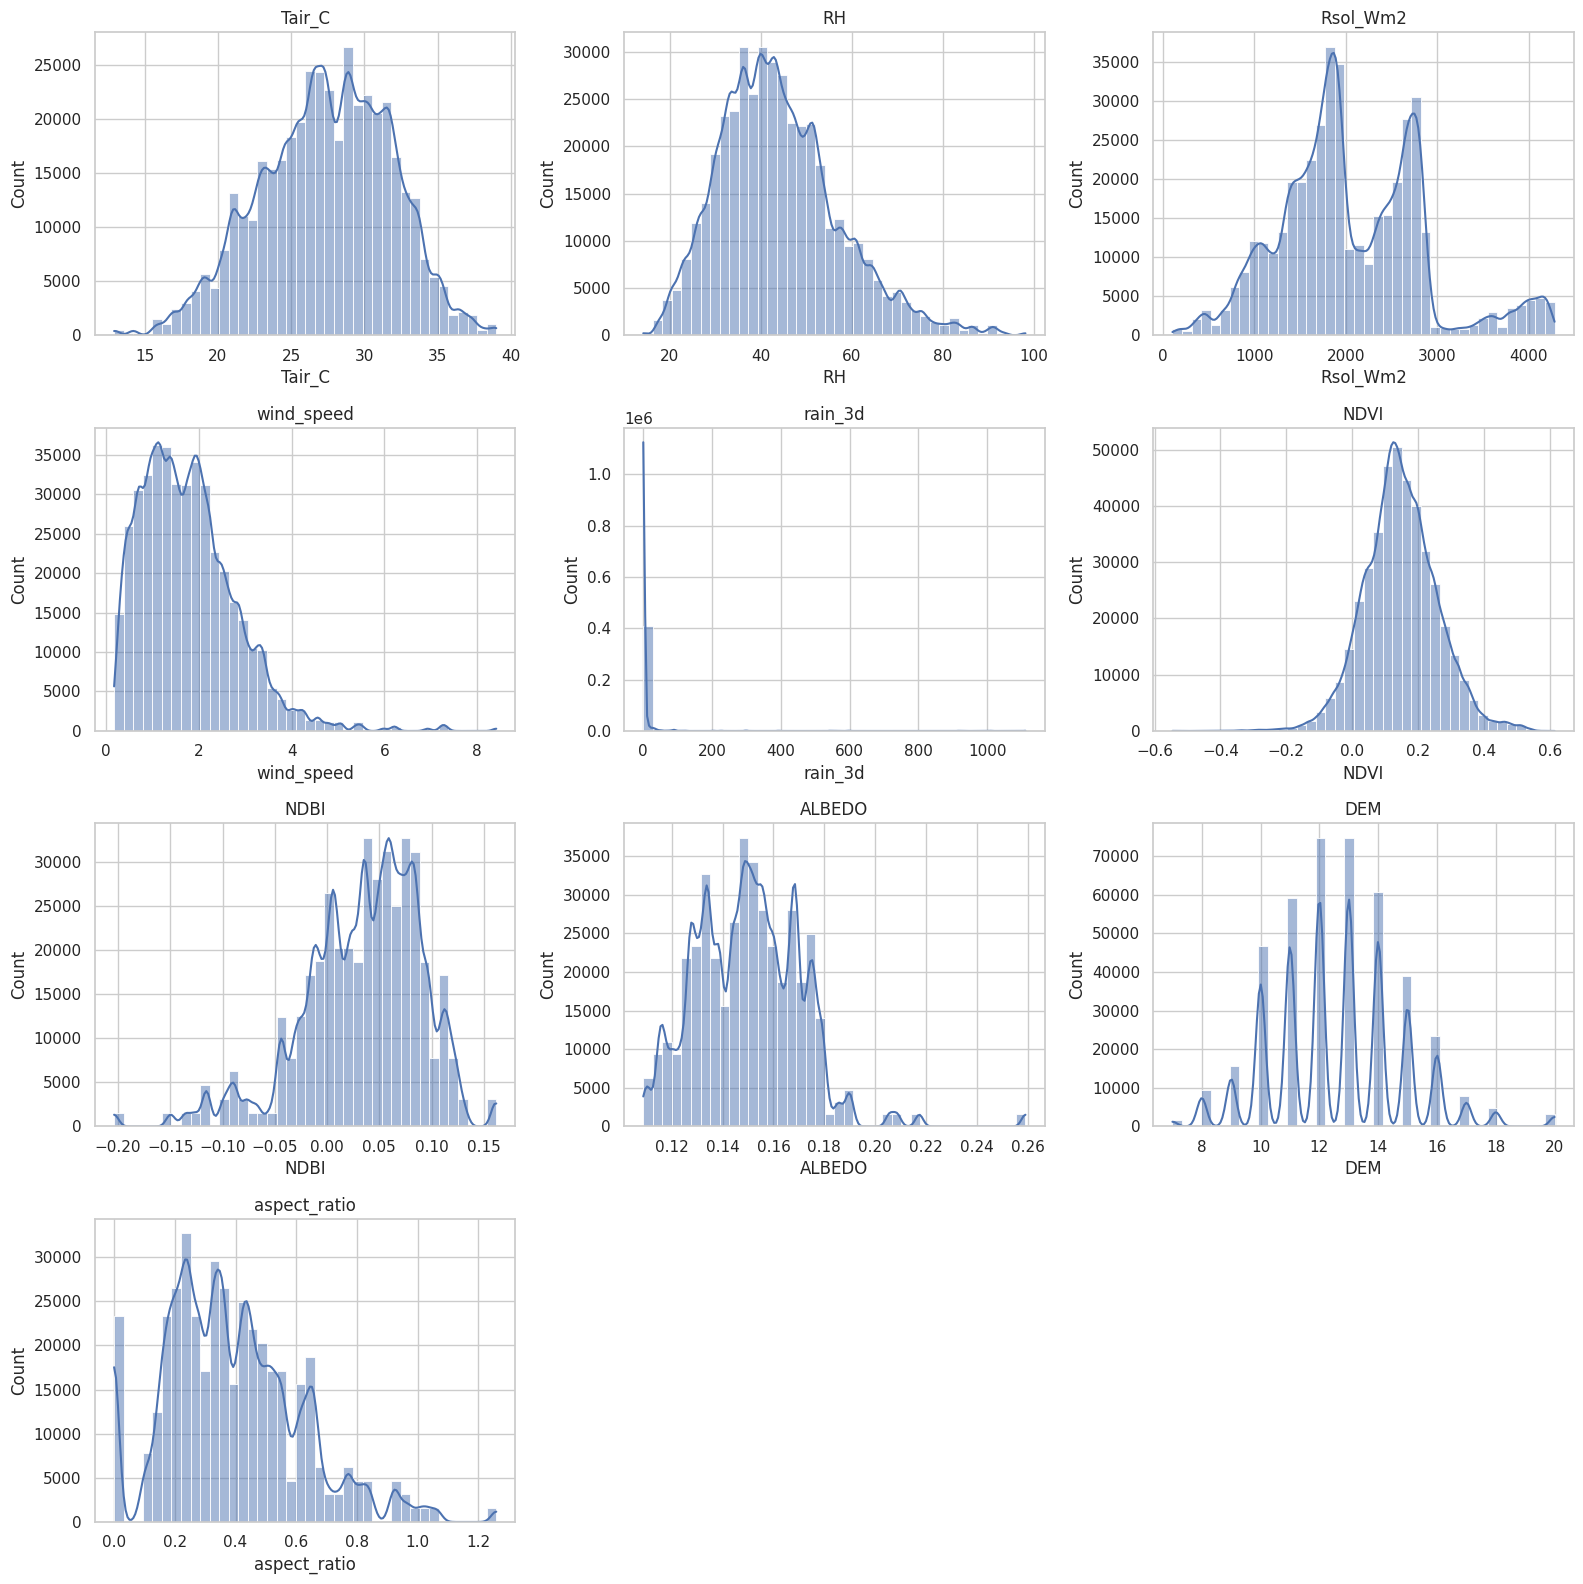


BOXPLOTS


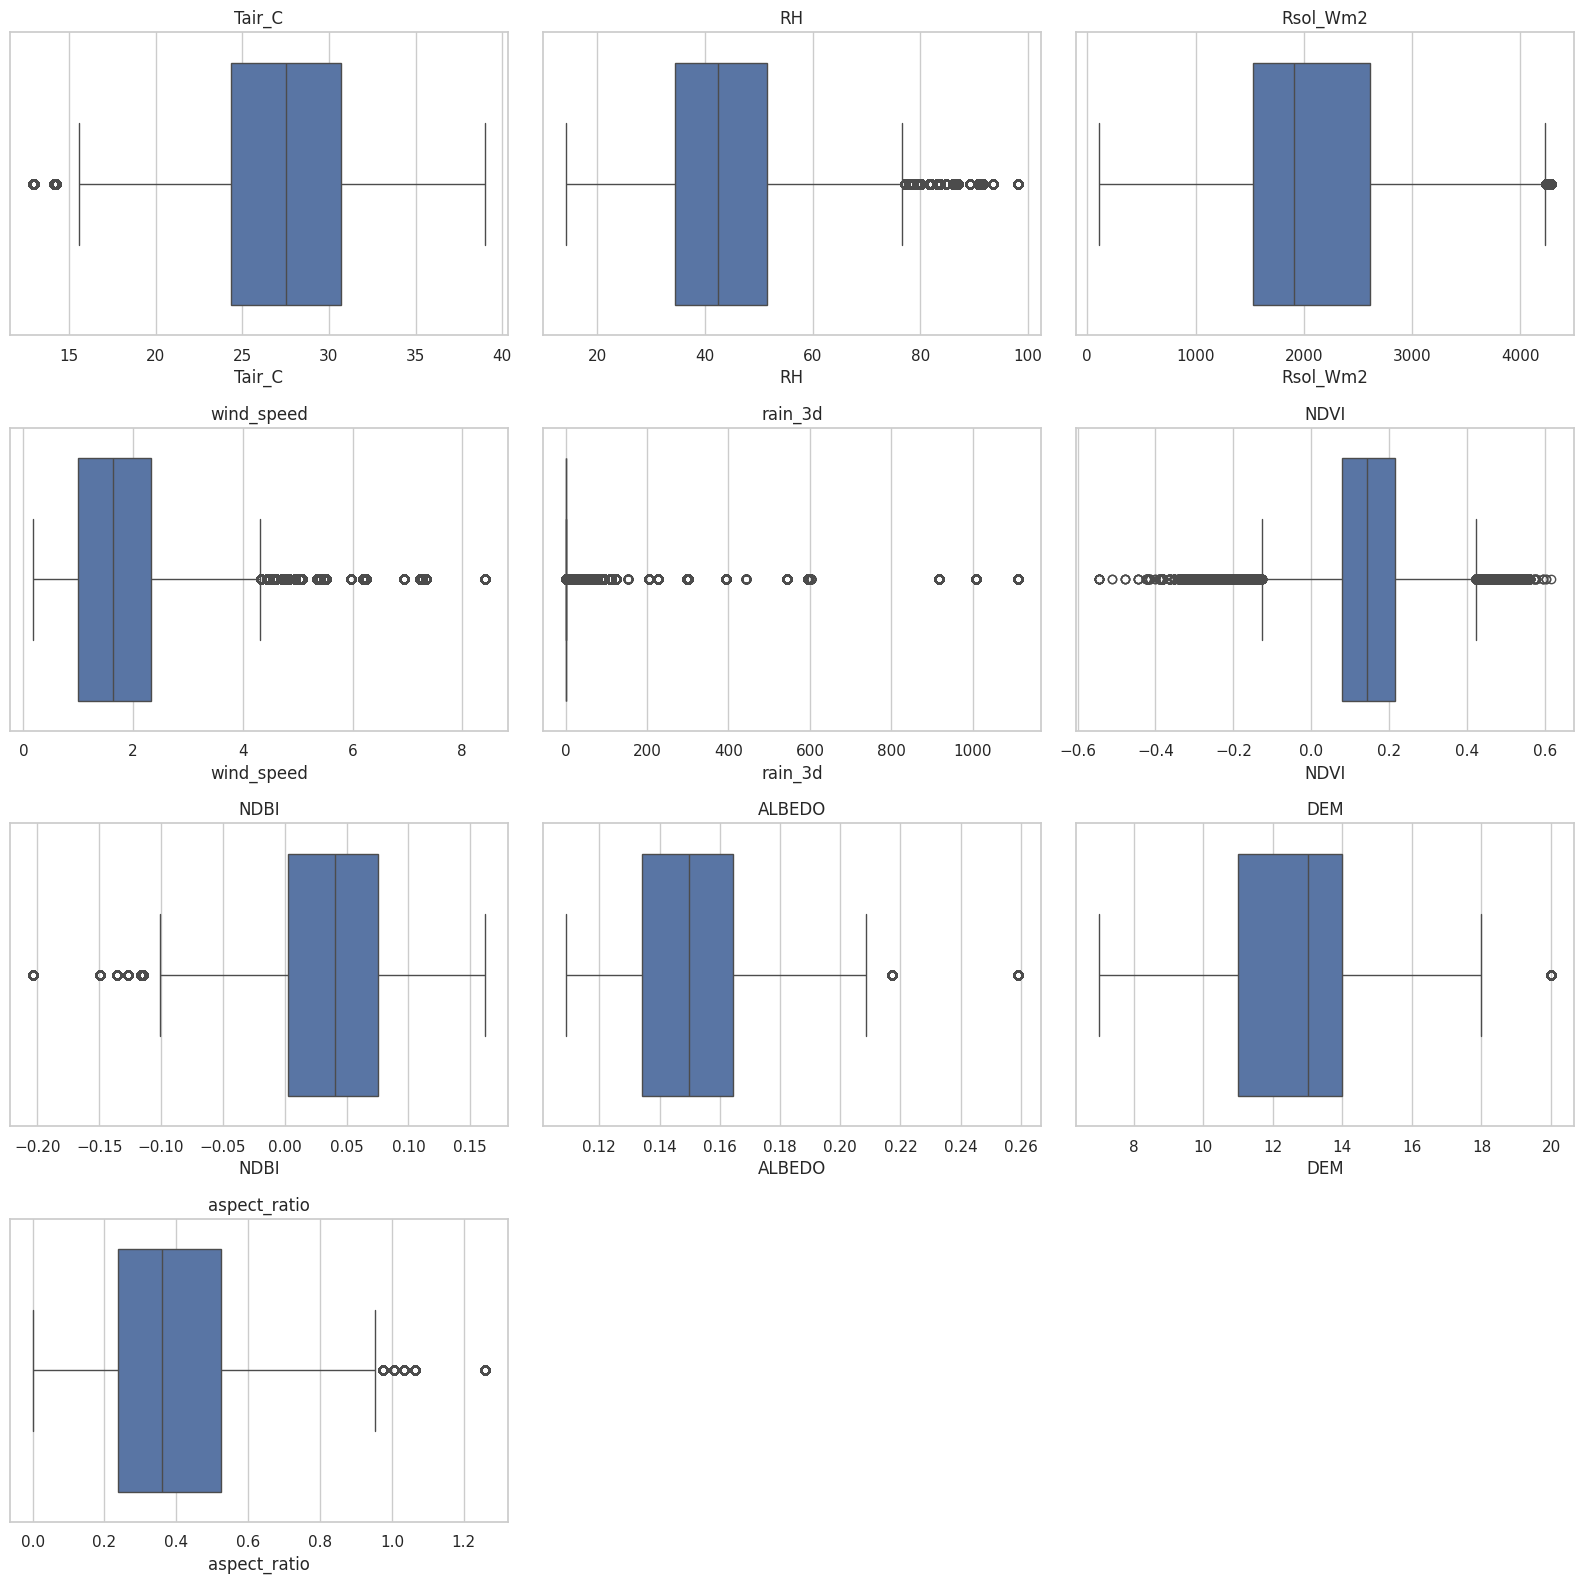


EVOLUCIÓN TEMPORAL


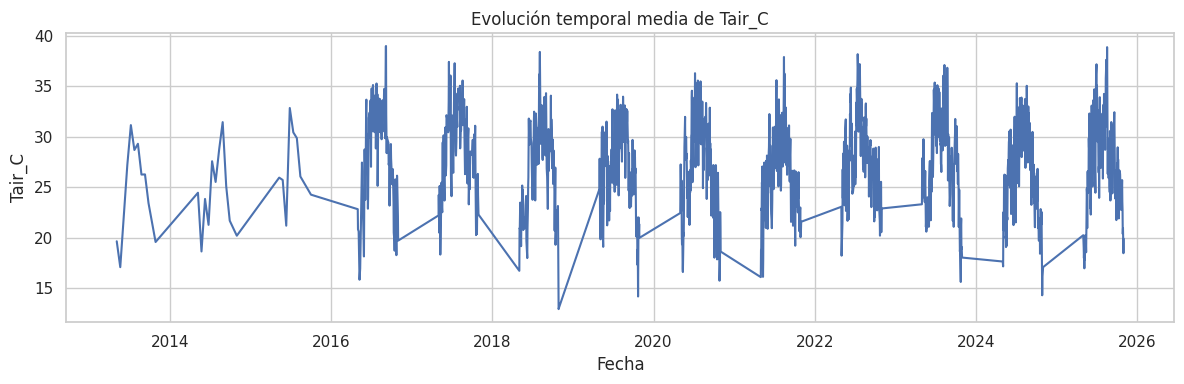

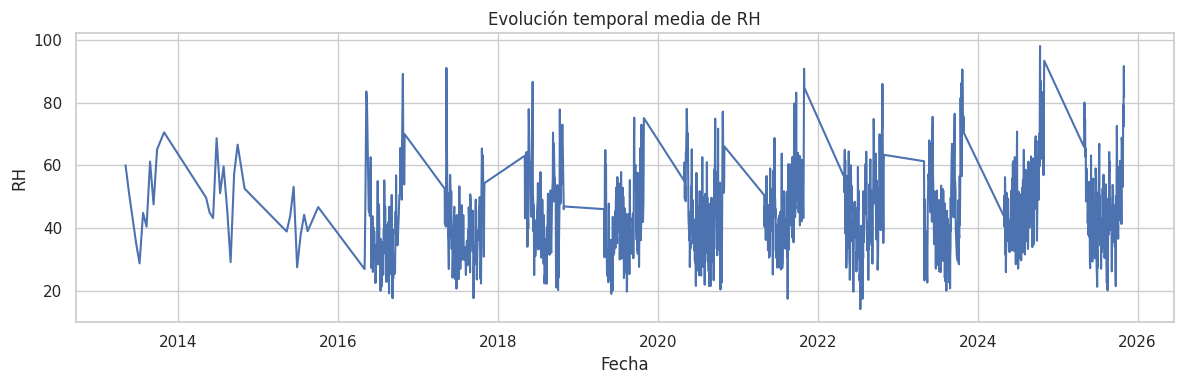

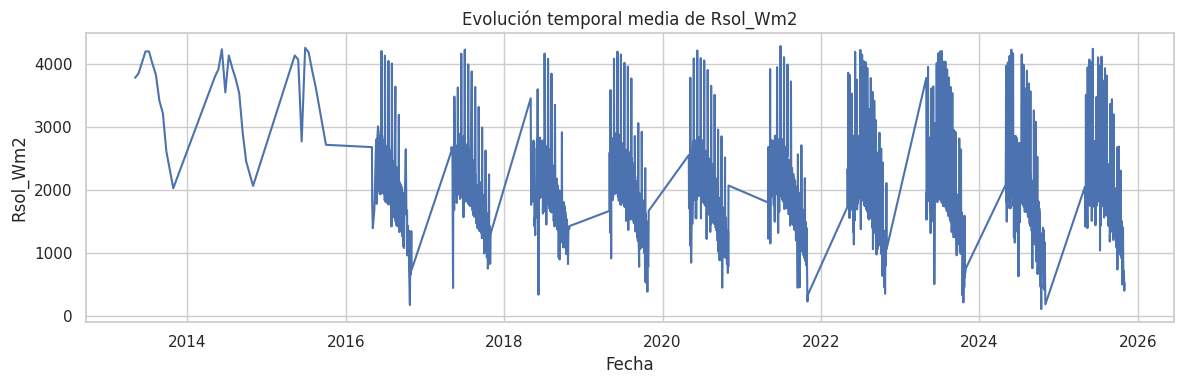

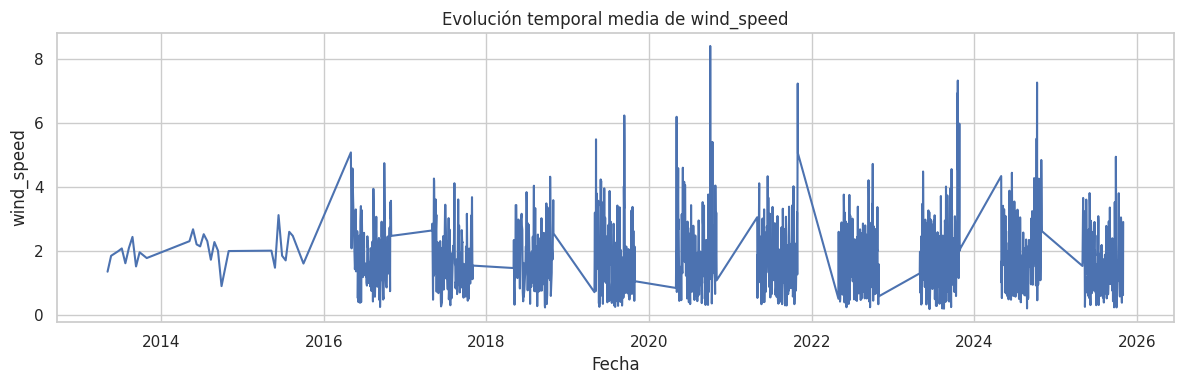

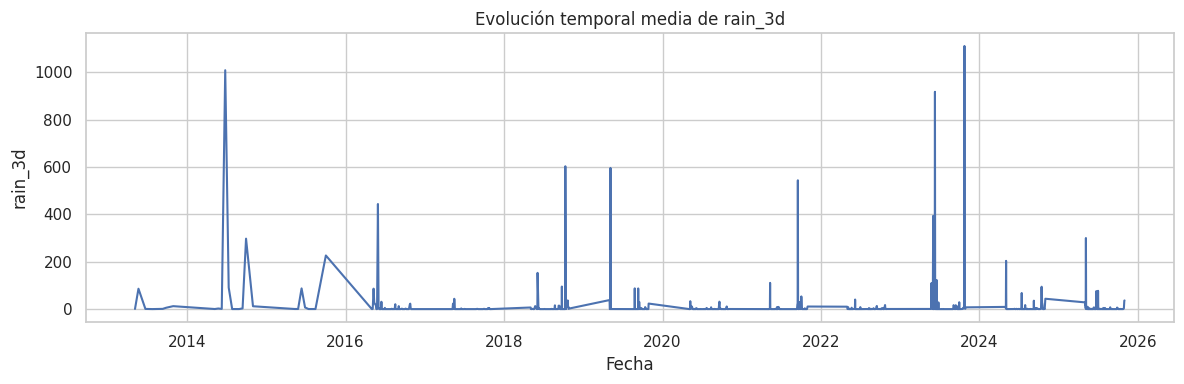

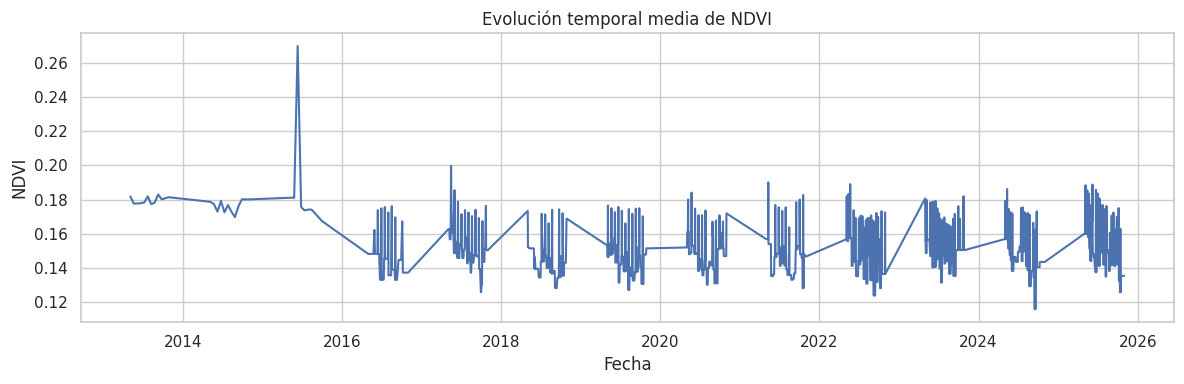


OUTLIERS


,variable,outliers,percentage
4,rain_3d,78484,18.67
6,NDBI,10900,2.59
5,NDVI,8765,2.08
1,RH,7863,1.87
3,wind_speed,7830,1.86
9,aspect_ratio,7783,1.85
8,DEM,3112,0.74
7,ALBEDO,3112,0.74
0,Tair_C,1080,0.26
2,Rsol_Wm2,810,0.19


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
df= df_clean
# ============================================================
# VARIABLES AUXILIARES
# ============================================================

aux_vars = [
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d",
    "NDVI",
    "NDBI",
    "ALBEDO",
    "DEM",
    "aspect_ratio"
]

aux_vars = [v for v in aux_vars if v in df.columns]

# ============================================================
# VARIABLES DINÁMICAS (TEMPORALES)
# ============================================================

temporal_vars = [
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d",
    "NDVI"
]

temporal_vars = [
    v for v in temporal_vars
    if v in df.columns
]

print("Variables auxiliares analizadas:")
print(aux_vars)

# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

print("\n====================================")
print("ESTADÍSTICAS DESCRIPTIVAS")
print("====================================")

display(
    df[aux_vars]
    .describe()
    .T
)

# ============================================================
# HISTOGRAMAS
# ============================================================

print("\n====================================")
print("DISTRIBUCIONES")
print("====================================")

n_cols = 3
n_rows = int(np.ceil(len(aux_vars) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(aux_vars):

    sns.histplot(
        df[col].dropna(),
        bins=40,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# BOXPLOTS
# ============================================================

print("\n====================================")
print("BOXPLOTS")
print("====================================")

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(aux_vars):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# EVOLUCIÓN TEMPORAL MEDIA
# SOLO VARIABLES DINÁMICAS
# ============================================================

print("\n====================================")
print("EVOLUCIÓN TEMPORAL")
print("====================================")

df_daily = (
    df.groupby("date")[temporal_vars]
    .mean()
    .reset_index()
)

for col in temporal_vars:

    plt.figure(figsize=(12, 4))

    sns.lineplot(
        data=df_daily,
        x="date",
        y=col
    )

    plt.title(f"Evolución temporal media de {col}")
    plt.xlabel("Fecha")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

# ============================================================
# OUTLIERS MEDIANTE IQR
# ============================================================

print("\n====================================")
print("OUTLIERS")
print("====================================")

outlier_summary = []

for col in aux_vars:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        (
            (df[col] < lower) |
            (df[col] > upper)
        )
    ).sum()

    outlier_summary.append({
        "variable": col,
        "outliers": n_outliers,
        "percentage": round(
            100 * n_outliers / len(df),
            2
        )
    })

outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.sort_values(
        "percentage",
        ascending=False
    )
)

## 2.3. Relaciones estadísticas y temporales

En esta sección se estudian las relaciones estadísticas entre las variables del dataset, así como la evolución temporal de la temperatura superficial, con el objetivo de identificar dependencias físicas y patrones temporales relevantes para el modelado espacio-temporal.

CORRELACIÓN DE PEARSON


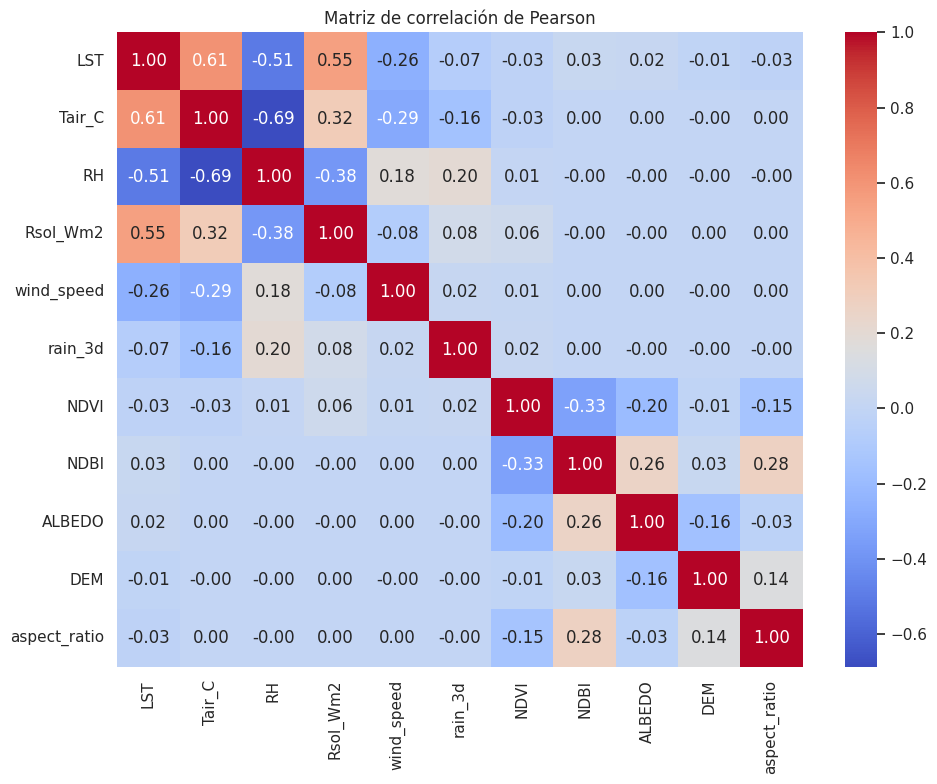


CORRELACIÓN CON LST


,LST
LST,1.000000
Tair_C,0.608011
Rsol_Wm2,0.546294
NDBI,0.025942
ALBEDO,0.019944
DEM,-0.011602
NDVI,-0.027037
aspect_ratio,-0.027650
rain_3d,-0.068836
wind_speed,-0.258902


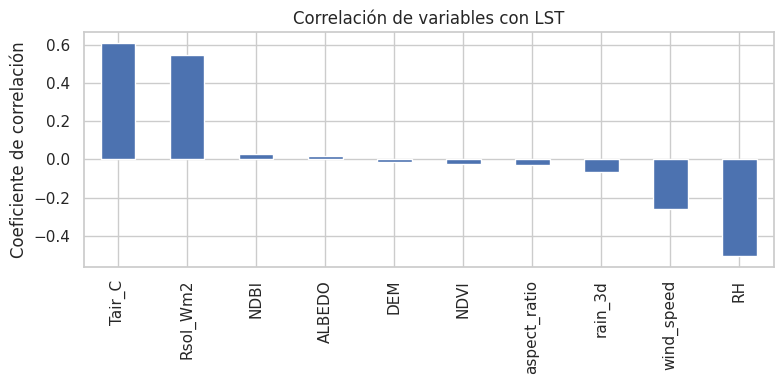


MUTUAL INFORMATION


,0
Tair_C,1.438792
RH,1.404132
Rsol_Wm2,1.400930
wind_speed,1.326993
rain_3d,0.403164
NDVI,0.039148
DEM,0.023585
NDBI,0.023331
aspect_ratio,0.022680
ALBEDO,0.022482


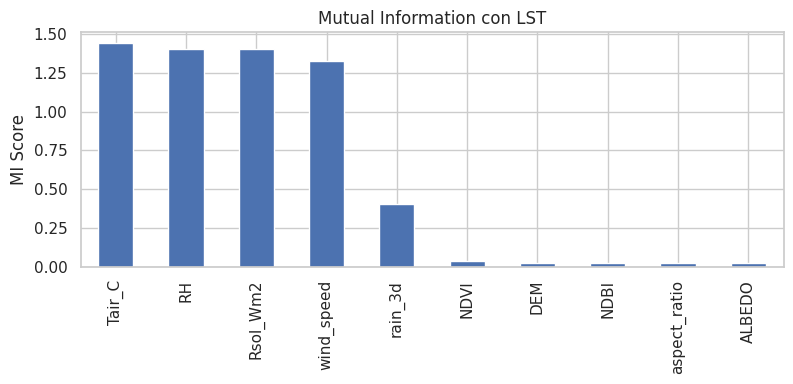


EVOLUCIÓN TEMPORAL DE LST


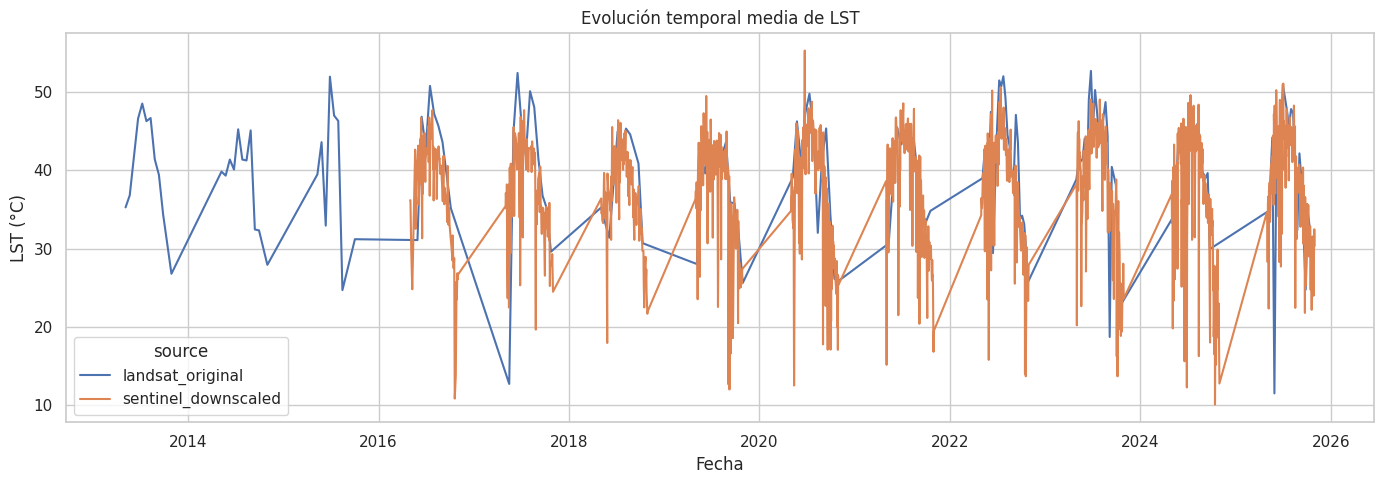


AUTOCORRELACIÓN TEMPORAL


<Figure size 800x400 with 0 Axes>

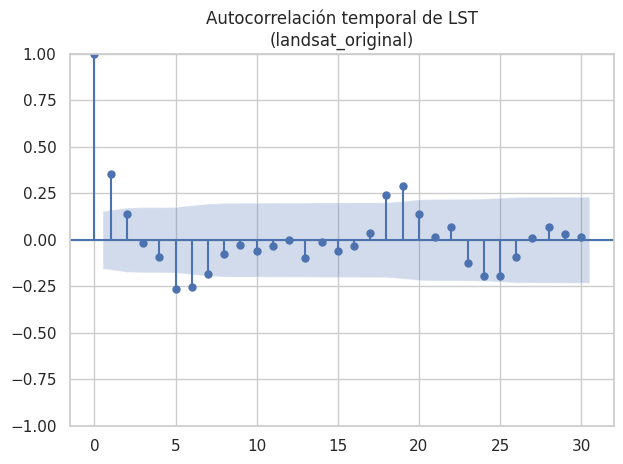

<Figure size 800x400 with 0 Axes>

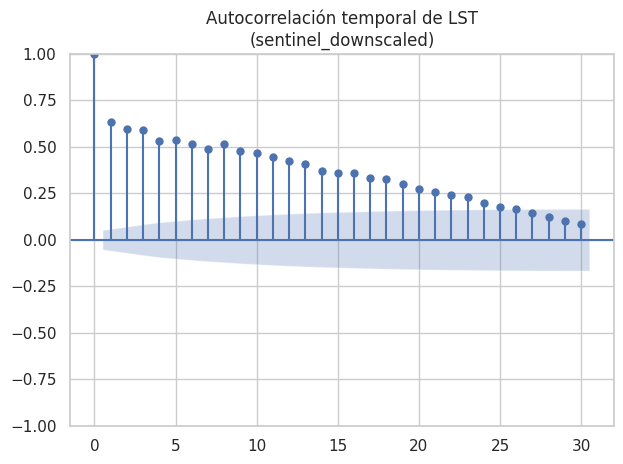

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.feature_selection import mutual_info_regression
from statsmodels.graphics.tsaplots import plot_acf

sns.set(style="whitegrid")

# ============================================================
# VARIABLES PARA CORRELACIÓN
# ============================================================

analysis_vars = [
    "LST",
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d",
    "NDVI",
    "NDBI",
    "ALBEDO",
    "DEM",
    "aspect_ratio"
]

analysis_vars = [
    v for v in analysis_vars
    if v in df.columns
]

# ============================================================
# MATRIZ DE CORRELACIÓN PEARSON
# ============================================================

print("====================================")
print("CORRELACIÓN DE PEARSON")
print("====================================")

corr_matrix = (
    df[analysis_vars]
    .corr(method="pearson")
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación de Pearson")

plt.tight_layout()
plt.show()

# ============================================================
# CORRELACIÓN CON LST
# ============================================================

print("\n====================================")
print("CORRELACIÓN CON LST")
print("====================================")

corr_target = (
    corr_matrix["LST"]
    .sort_values(ascending=False)
)

display(corr_target)

plt.figure(figsize=(8, 4))

corr_target.drop("LST").plot(
    kind="bar"
)

plt.ylabel("Coeficiente de correlación")
plt.title("Correlación de variables con LST")

plt.tight_layout()
plt.show()

# ============================================================
# MUTUAL INFORMATION
# ============================================================

print("\n====================================")
print("MUTUAL INFORMATION")
print("====================================")

mi_features = [
    v for v in analysis_vars
    if v != "LST"
]

mi_df = df[["LST"] + mi_features].dropna()

X = mi_df[mi_features]
y = mi_df["LST"]

mi_scores = mutual_info_regression(
    X,
    y,
    random_state=42
)

mi_series = pd.Series(
    mi_scores,
    index=mi_features
).sort_values(ascending=False)

display(mi_series)

plt.figure(figsize=(8, 4))

mi_series.plot(
    kind="bar"
)

plt.ylabel("MI Score")
plt.title("Mutual Information con LST")

plt.tight_layout()
plt.show()

# ============================================================
# EVOLUCIÓN TEMPORAL DE LST
# ============================================================

print("\n====================================")
print("EVOLUCIÓN TEMPORAL DE LST")
print("====================================")

lst_daily = (
    df.groupby(["date", "source"])["LST"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=lst_daily,
    x="date",
    y="LST",
    hue="source"
)

plt.title("Evolución temporal media de LST")
plt.xlabel("Fecha")
plt.ylabel("LST (°C)")

plt.tight_layout()
plt.show()

# ============================================================
# AUTOCORRELACIÓN TEMPORAL
# ============================================================

print("\n====================================")
print("AUTOCORRELACIÓN TEMPORAL")
print("====================================")

for source_name in df["source"].unique():

    series = (
        df[df["source"] == source_name]
        .groupby("date")["LST"]
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))

    plot_acf(
        series,
        lags=30
    )

    plt.title(
        f"Autocorrelación temporal de LST\n({source_name})"
    )

    plt.tight_layout()
    plt.show()

## 2.4. Comparación entre datos observados y downscaled

En esta sección se comparan las distribuciones y patrones temporales de la temperatura superficial observada y downscaled, con el objetivo de analizar las diferencias estadísticas introducidas por el proceso de downscaling.

ESTADÍSTICAS DE LST POR FUENTE


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
landsat_original,40539.0,40.779696,7.250775,8.732364,36.105577,42.386188,45.729012,54.612446
sentinel_downscaled,379890.0,37.649882,7.396322,7.134060,33.461502,39.297800,43.044330,58.999080



DISTRIBUCIÓN DE LST


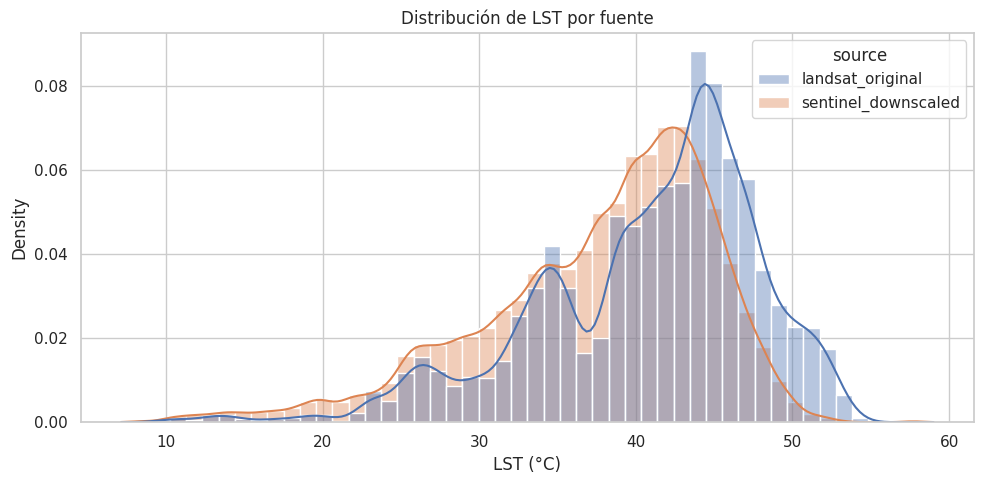


BOXPLOT DE LST


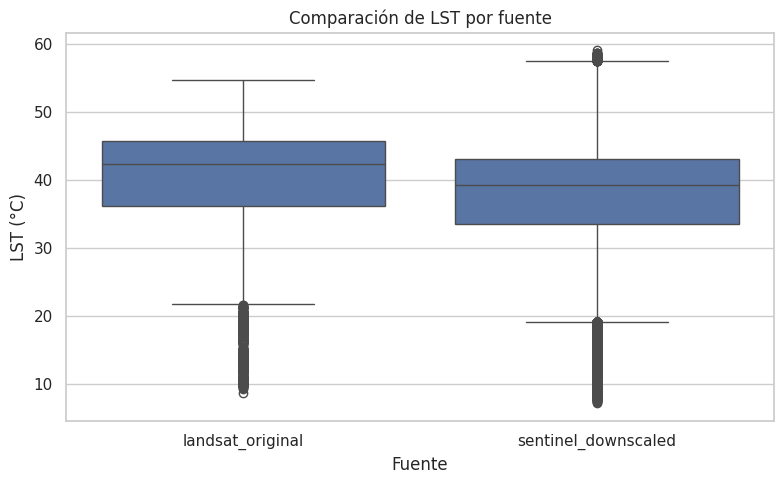


EVOLUCIÓN TEMPORAL


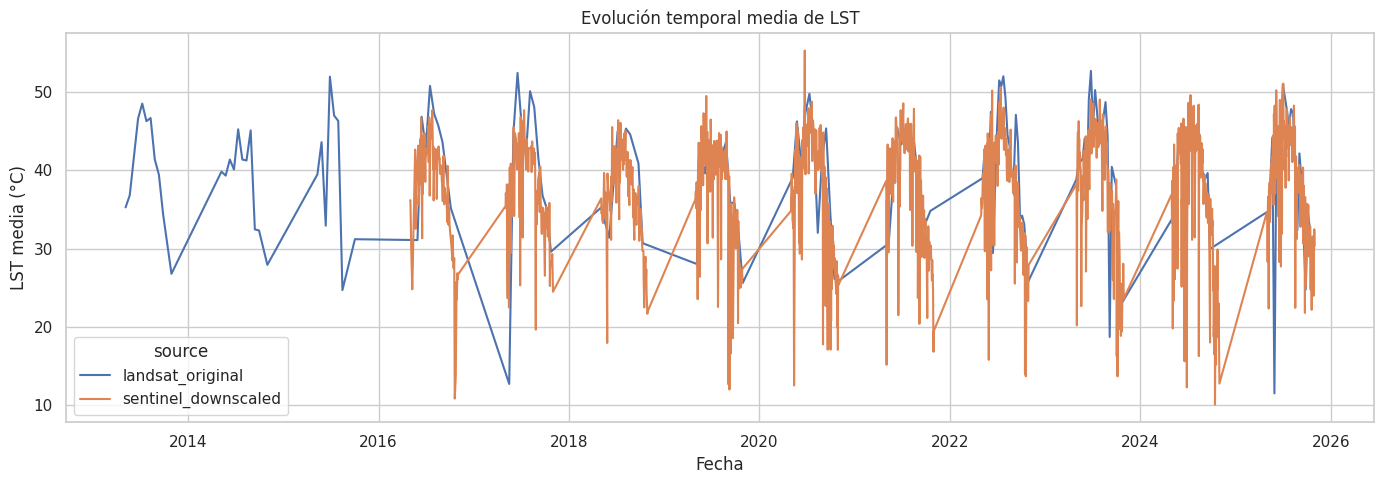


COMPARACIÓN MENSUAL


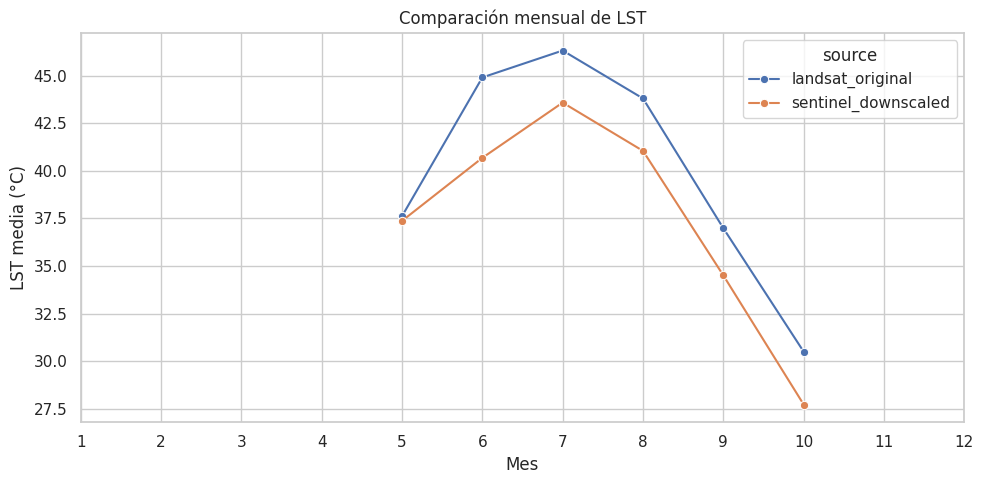


DIFERENCIA MEDIA MENSUAL


source,landsat_original,sentinel_downscaled,difference
month,,,
5,37.618685,37.372264,-0.246421
6,44.911867,40.685031,-4.226836
7,46.326716,43.589900,-2.736817
8,43.806692,41.051634,-2.755058
9,36.985892,34.506492,-2.479400
10,30.496415,27.719260,-2.777155


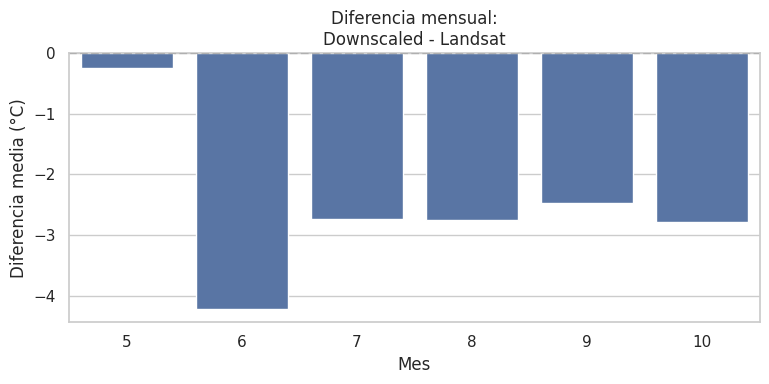


PCA


/tmp/ipykernel_830/2713025419.py:239: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


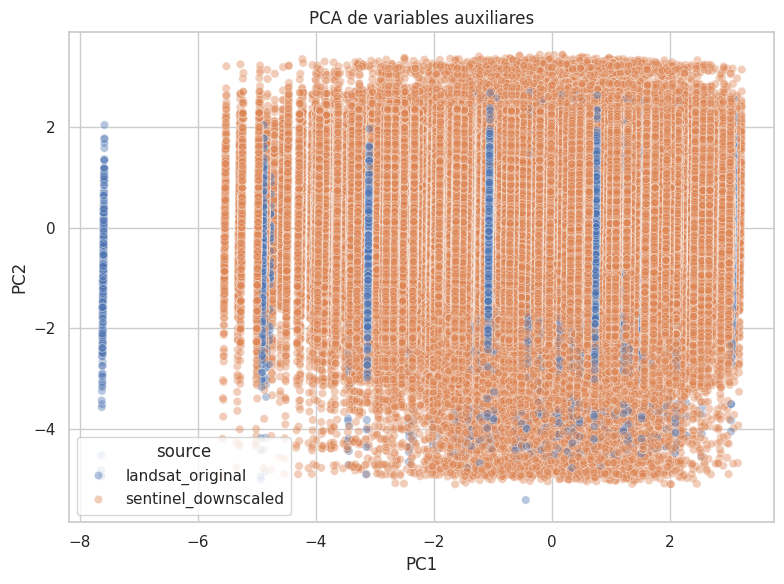


Varianza explicada:
PC1: 0.2083
PC2: 0.1634
Acumulada: 0.3717


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# ============================================================
# COMPARACIÓN DE LST ENTRE FUENTES
# ============================================================

print("====================================")
print("ESTADÍSTICAS DE LST POR FUENTE")
print("====================================")

lst_stats = (
    df.groupby("source")["LST"]
    .describe()
)

display(lst_stats)

# ============================================================
# HISTOGRAMA + KDE
# ============================================================

print("\n====================================")
print("DISTRIBUCIÓN DE LST")
print("====================================")

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="LST",
    hue="source",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.4
)

plt.xlabel("LST (°C)")
plt.ylabel("Density")
plt.title("Distribución de LST por fuente")

plt.tight_layout()
plt.show()

# ============================================================
# BOXPLOT COMPARATIVO
# ============================================================

print("\n====================================")
print("BOXPLOT DE LST")
print("====================================")

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="source",
    y="LST"
)

plt.xlabel("Fuente")
plt.ylabel("LST (°C)")
plt.title("Comparación de LST por fuente")

plt.tight_layout()
plt.show()

# ============================================================
# EVOLUCIÓN TEMPORAL MEDIA DE LST
# ============================================================

print("\n====================================")
print("EVOLUCIÓN TEMPORAL")
print("====================================")

lst_daily = (
    df.groupby(["date", "source"])["LST"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=lst_daily,
    x="date",
    y="LST",
    hue="source"
)

plt.xlabel("Fecha")
plt.ylabel("LST media (°C)")
plt.title("Evolución temporal media de LST")

plt.tight_layout()
plt.show()

# ============================================================
# COMPARACIÓN MENSUAL
# ============================================================

print("\n====================================")
print("COMPARACIÓN MENSUAL")
print("====================================")

df["month"] = df["date"].dt.month

monthly_lst = (
    df.groupby(["month", "source"])["LST"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_lst,
    x="month",
    y="LST",
    hue="source",
    marker="o"
)

plt.xlabel("Mes")
plt.ylabel("LST media (°C)")
plt.title("Comparación mensual de LST")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

# ============================================================
# DIFERENCIA ENTRE MEDIAS MENSUALES
# ============================================================

print("\n====================================")
print("DIFERENCIA MEDIA MENSUAL")
print("====================================")

monthly_pivot = monthly_lst.pivot(
    index="month",
    columns="source",
    values="LST"
)

if (
    "landsat_original" in monthly_pivot.columns and
    "sentinel_downscaled" in monthly_pivot.columns
):

    monthly_pivot["difference"] = (
        monthly_pivot["sentinel_downscaled"] -
        monthly_pivot["landsat_original"]
    )

    display(monthly_pivot)

    plt.figure(figsize=(8, 4))

    sns.barplot(
        x=monthly_pivot.index,
        y=monthly_pivot["difference"]
    )

    plt.axhline(0, color="black", linestyle="--")

    plt.xlabel("Mes")
    plt.ylabel("Diferencia media (°C)")
    plt.title("Diferencia mensual:\nDownscaled - Landsat")

    plt.tight_layout()
    plt.show()

# ============================================================
# PCA DE VARIABLES AUXILIARES
# ============================================================

print("\n====================================")
print("PCA")
print("====================================")

pca_features = [
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d",
    "NDVI",
    "NDBI",
    "ALBEDO",
    "DEM",
    "aspect_ratio"
]

pca_features = [
    v for v in pca_features
    if v in df.columns
]

pca_df = df[pca_features + ["source"]].dropna()

X = pca_df[pca_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "source": pca_df["source"].values
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="source",
    alpha=0.4
)

plt.title("PCA de variables auxiliares")

plt.tight_layout()
plt.show()

# ============================================================
# VARIANZA EXPLICADA
# ============================================================

explained_var = pca.explained_variance_ratio_

print("\nVarianza explicada:")
print(
    f"PC1: {explained_var[0]:.4f}"
)

print(
    f"PC2: {explained_var[1]:.4f}"
)

print(
    f"Acumulada: {explained_var.sum():.4f}"
)

# 3. XGBoost



##3.1 Preprocesamiento de datos

 Se preparan y unifican los conjuntos de datos Landsat y Sentinel-3, se generan variables temporales y espaciales adicionales y se construyen los conjuntos de entrenamiento, validación y prueba siguiendo el mismo esquema experimental utilizado en los modelos basados en grafos.

In [ ]:
# ============================================================
# XGBOOST COMPARABLE CON GCN
# TRAIN = Landsat train + Sentinel reducido
# VAL   = Landsat real
# TEST  = Landsat real
# ============================================================

!pip -q install xgboost

import os
import random
import numpy as np
import pandas as pd

from google.colab import drive
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

drive.mount("/content/drive")

# ============================================================
# 0. CONFIGURACIÓN
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

SENTINEL_CSV = os.path.join(
    BASE_PATH,
    "datos_sentinel_downscalled.csv"
)

ORIGINAL_CSV = os.path.join(
    BASE_PATH,
    "datos_landsat.csv"
)

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ============================================================
# 1. CARGAR DATASETS
# ============================================================

df_s = pd.read_csv(SENTINEL_CSV)
df_o = pd.read_csv(ORIGINAL_CSV)

df_s["source"] = "sentinel_downscaled"
df_o["source"] = "landsat_original"

df_s["date"] = pd.to_datetime(df_s["date"])
df_o["date"] = pd.to_datetime(df_o["date"])

df_s["node_id"] = df_s["node_id"].astype(str)
df_o["node_id"] = df_o["node_id"].astype(str)

for df_tmp in [df_s, df_o]:
    if "lat" in df_tmp.columns:
        df_tmp.rename(columns={"lat": "latitude"}, inplace=True)
    if "lon" in df_tmp.columns:
        df_tmp.rename(columns={"lon": "longitude"}, inplace=True)

# ============================================================
# 2. AÑADIR FEATURES TEMPORALES Y ESPACIALES
# ============================================================

def add_spatial_temporal_features(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])
    df["day_of_year"] = df["date"].dt.dayofyear
    df["sin_doy"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["cos_doy"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

    node_df = (
        df[["node_id", "latitude", "longitude"]]
        .drop_duplicates("node_id")
        .copy()
    )

    node_df["lat_key"] = node_df["latitude"].round(6)
    node_df["lon_key"] = node_df["longitude"].round(6)

    lat_vals = np.sort(node_df["lat_key"].unique())[::-1]
    lon_vals = np.sort(node_df["lon_key"].unique())

    lat_to_row = {lat: i for i, lat in enumerate(lat_vals)}
    lon_to_col = {lon: j for j, lon in enumerate(lon_vals)}

    node_df["row"] = node_df["lat_key"].map(lat_to_row)
    node_df["col"] = node_df["lon_key"].map(lon_to_col)

    node_df["row_norm"] = node_df["row"] / (len(lat_vals) - 1)
    node_df["col_norm"] = node_df["col"] / (len(lon_vals) - 1)

    df = df.drop(columns=["row", "col", "row_norm", "col_norm"], errors="ignore")

    df = df.merge(
        node_df[["node_id", "row", "col", "row_norm", "col_norm"]],
        on="node_id",
        how="left",
        validate="many_to_one"
    )

    return df

df_s = add_spatial_temporal_features(df_s)
df_o = add_spatial_temporal_features(df_o)

# ============================================================
# 3. FEATURES COMPARABLES CON GCN
# ============================================================

target_col = "LST"

feature_cols = [
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d_log",
    "is_rainy",
    "DEM",
    "NDBI",
    "ALBEDO",
    "aspect_ratio",
    "has_buildings",
    "row_norm",
    "col_norm",
    "sin_doy",
    "cos_doy"
]

base_cols = [
    "source",
    "node_id",
    "date",
    "latitude",
    "longitude",
    target_col
]

needed_cols = base_cols + feature_cols

missing_s = [c for c in needed_cols if c not in df_s.columns]
missing_o = [c for c in needed_cols if c not in df_o.columns]

if missing_s:
    raise ValueError(f"Faltan columnas en Sentinel: {missing_s}")

if missing_o:
    raise ValueError(f"Faltan columnas en Landsat original: {missing_o}")

df_s = df_s[needed_cols].copy()
df_o = df_o[needed_cols].copy()

df = pd.concat([df_s, df_o], ignore_index=True)

df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
df["node_id"] = df["node_id"].astype(str)

df = df.dropna(subset=feature_cols + [target_col]).copy()

print("Dataset mixto:", df.shape)
print(df["source"].value_counts())
print("\nFechas por fuente:")
print(df.groupby("source")["date"].nunique())

# ============================================================
# 4. SPLIT HÍBRIDO
# ============================================================

landsat_dates = np.array(
    sorted(df.loc[df["source"] == "landsat_original", "date"].unique())
)

sentinel_dates_all = np.array(
    sorted(df.loc[df["source"] == "sentinel_downscaled", "date"].unique())
)

n_landsat = len(landsat_dates)

landsat_train_end = int(0.70 * n_landsat)
landsat_val_end = int(0.85 * n_landsat)

landsat_train_dates = landsat_dates[:landsat_train_end]
val_dates = landsat_dates[landsat_train_end:landsat_val_end]
test_dates = landsat_dates[landsat_val_end:]

n_sentinel_target = min(
    len(sentinel_dates_all),
    SENTINEL_RATIO * len(landsat_train_dates)
)

rng = np.random.default_rng(RANDOM_STATE)

sentinel_train_dates = np.array(
    sorted(
        rng.choice(
            sentinel_dates_all,
            size=n_sentinel_target,
            replace=False
        )
    )
)

train_mask = (
    (
        (df["source"] == "landsat_original") &
        (df["date"].isin(landsat_train_dates))
    )
    |
    (
        (df["source"] == "sentinel_downscaled") &
        (df["date"].isin(sentinel_train_dates))
    )
)

val_mask = (
    (df["source"] == "landsat_original") &
    (df["date"].isin(val_dates))
)

test_mask = (
    (df["source"] == "landsat_original") &
    (df["date"].isin(test_dates))
)

train_df = df.loc[train_mask].copy()
val_df = df.loc[val_mask].copy()
test_df = df.loc[test_mask].copy()

print("\n==============================")
print("SPLIT XGBOOST")
print("==============================")
print("Landsat train fechas:", len(landsat_train_dates))
print("Sentinel train fechas:", len(sentinel_train_dates))
print("Val Landsat fechas:", len(val_dates))
print("Test Landsat fechas:", len(test_dates))

print("\nFilas:")
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

print("\nTrain por fuente:")
print(train_df["source"].value_counts())

# ============================================================
# 5. MATRICES
# ============================================================

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("\nX_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset mixto: (441489, 21)
source
sentinel_downscaled    400950
landsat_original        40539
Name: count, dtype: int64

Fechas por fuente:
source
landsat_original        161
sentinel_downscaled    1485
Name: date, dtype: int64

SPLIT XGBOOST
Landsat train fechas: 112
Sentinel train fechas: 896
Val Landsat fechas: 24
Test Landsat fechas: 25

Filas:
Train: (270010, 21)
Val:   (5981, 21)
Test:  (6468, 21)

Train por fuente:
source
sentinel_downscaled    241920
landsat_original        28090
Name: count, dtype: int64

X_train: (270010, 15)
X_val:   (5981, 15)
X_test:  (6468, 15)


##3.2. Entrenamiento modelo

Se optimizan automáticamente los hiperparámetros de XGBoost mediante Optuna y, posteriormente, se entrena el modelo con la mejor configuración encontrada para maximizar su capacidad predictiva.

In [ ]:
# ============================================================
# 1. IMPORTACIONES
# ============================================================
# Si no lo tienes instalado:
!pip install optuna xgboost optuna-integration

import numpy as np
import pandas as pd
import optuna
import time

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.integration import XGBoostPruningCallback

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 12.6 MB/s eta 0:00:00


/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


In [ ]:
# ============================================================
# 3. SAMPLER Y PRUNER
# ============================================================
sampler = TPESampler(
    seed=42,
    multivariate=True
)

pruner = MedianPruner(
    n_startup_trials=10,   # no poda los 10 primeros trials
    n_warmup_steps=20,     # espera al menos 20 iteraciones internas
    interval_steps=10      # comprueba poda cada 10 pasos
)

/tmp/ipykernel_3714/3973270734.py:4: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = TPESampler(


In [ ]:
# ============================================================
# 4. FUNCIÓN OBJETIVO CORREGIDA
#    OJO: callbacks va en el constructor, no en fit()
# ============================================================
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": 42,
        "tree_method": "hist",
        "early_stopping_rounds": 50,
        "callbacks": [XGBoostPruningCallback(trial, "validation_0-rmse")],
    }

    model = XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_val_pred = model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    return val_rmse

In [ ]:
# ============================================================
# 5. CREAR ESTUDIO
# ============================================================
study = optuna.create_study(
    study_name="xgboost_lst_optuna_pruned",
    direction="minimize",
    sampler=sampler,
    pruner=pruner
)

# ============================================================
# 6. LANZAR OPTIMIZACIÓN
# ============================================================
study.optimize(
    objective,
    n_trials=50,
    timeout=None,
    show_progress_bar=True
)

[I 2026-06-02 17:34:46,012] A new study created in memory with name: xgboost_lst_optuna_pruned


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-02 17:34:54,420] Trial 0 finished with value: 4.3510289863610705 and parameters: {'n_estimators': 749, 'learning_rate': 0.0862735828664018, 'max_depth': 7, 'min_child_weight': 10, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973, 'reg_alpha': 2.1423021757741068, 'reg_lambda': 0.10129197956845731}. Best is trial 0 with value: 4.3510289863610705.
[I 2026-06-02 17:35:52,506] Trial 1 finished with value: 5.237011240559977 and parameters: {'n_estimators': 1150, 'learning_rate': 0.005318033256270142, 'max_depth': 8, 'min_child_weight': 13, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.9170225492671691, 'reg_alpha': 0.0033205591037519565, 'reg_lambda': 0.042051564509138675}. Best is trial 0 with value: 4.3510289863610705.
[I 2026-06-02 17:36:04,804] Trial 2 finished with value: 5.305542801872564 and parameters: {'n_estimators': 818, 'learning_rate': 0.011963764382790322, 'max_depth': 6, 'min_ch

In [ ]:
# ============================================================
# 5. MEJOR RESULTADO
# ============================================================
print("Best trial:")
print("  Validation RMSE:", study.best_trial.value)

print("\nBest hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

Best trial:
  Validation RMSE: 4.3510289863610705

Best hyperparameters:
  n_estimators: 749
  learning_rate: 0.0862735828664018
  max_depth: 7
  min_child_weight: 10
  subsample: 0.6624074561769746
  colsample_bytree: 0.662397808134481
  gamma: 0.2904180608409973
  reg_alpha: 2.1423021757741068
  reg_lambda: 0.10129197956845731


In [ ]:
# ============================================================
# 6. REENTRENAR EL MEJOR MODELO
# ============================================================
import joblib
best_params = study.best_trial.params.copy()

best_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=42,
    eval_metric="rmse",
    tree_method="hist",
    early_stopping_rounds=50
)
start_time = time.perf_counter()

best_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

total_time_s = time.perf_counter() - start_time
n_epochs = best_model.best_iteration + 1

y_test_pred = best_model.predict(X_test)


# Ruta donde quieres guardar el modelo
ruta = "/content/drive/MyDrive/TFM/xgboost_model.pkl"

# Guardar modelo
joblib.dump(best_model, ruta)

print(f"Modelo guardado en: {ruta}")

[0]	validation_0-rmse:10.84429	validation_1-rmse:9.35972
[50]	validation_0-rmse:2.58812	validation_1-rmse:4.46239
[100]	validation_0-rmse:1.90144	validation_1-rmse:4.41841
[150]	validation_0-rmse:1.51616	validation_1-rmse:4.38966
[185]	validation_0-rmse:1.37179	validation_1-rmse:4.38296
Modelo guardado en: /content/drive/MyDrive/TFM/xgboost_model.pkl


##3.3. Evaluación

Se analiza el rendimiento del modelo utilizando diferentes métricas de regresión y se estudia tanto el comportamiento global de las predicciones como su distribución espacial y temporal. El objetivo es comparar los resultados obtenidos con los de las arquitecturas neuronales propuestas y evaluar la capacidad de generalización del modelo.

In [ ]:
import joblib
best_model = joblib.load("/content/drive/MyDrive/TFM/xgboost_model.pkl")
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)

In [ ]:
# ============================================================
# 8. EVALUACIÓN FINAL
# ============================================================
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)


def compute_metrics(y_true, y_pred, eps=1e-8):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mape = (
        np.mean(
            np.abs(
                (y_true - y_pred) / np.maximum(np.abs(y_true), eps)
            )
        ) * 100
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }
train_metrics = compute_metrics(y_train, y_train_pred)
val_metrics = compute_metrics(y_val, y_val_pred)
test_metrics = compute_metrics(y_test, y_test_pred)

save_model_test_results(
    model_name="XGBoost",
    total_training_time_s=total_time_s,
    n_epochs=n_epochs,
    test_metrics=test_metrics
)

print("Train metrics:")
print(train_metrics)

print("\nValidation metrics:")
print(val_metrics)

print("\nTest metrics:")
print(test_metrics)

Resultados acumulados guardados en:
/content/drive/MyDrive/TFM/model_results_summary.csv


,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE,sentinel_ratio
0,XGBoost,2.337024,126,0.018548,3.071004,4.298590,0.584298,8.186274,3
1,GCN,27.936010,53,0.527095,2.303982,3.715620,0.689407,6.796395,3
2,GCN_GRU,430.489783,33,13.045145,2.266650,3.620564,0.705095,6.559174,3
3,XGBoost,1.586087,69,0.022987,2.480746,3.592164,0.709703,7.042518,1
4,GCN,26.592134,37,0.718706,2.427666,3.828797,0.670197,7.218503,1
5,GCN_GRU,201.691587,26,7.757369,2.602865,3.931059,0.652345,7.479530,1
6,XGBoost,2.289224,641,0.003571,2.815163,4.023797,0.635748,8.010942,0
7,GCN,3.104944,40,0.077624,2.198127,3.374826,0.743769,6.332814,0
8,GCN_GRU,129.083542,37,3.488744,3.110610,4.495594,0.545322,8.952583,0
9,XGBoost,3.157494,170,0.018573,2.904734,3.837335,0.668725,7.971094,2


Train metrics:
{'MAE': 1.1885313388192524, 'RMSE': np.float64(1.619088054281049), 'R2': 0.9805820952416583, 'MAPE': np.float64(6.8850746369859275)}

Validation metrics:
{'MAE': 3.0859954838153105, 'RMSE': np.float64(4.3510289863610705), 'R2': 0.7241114875602909, 'MAPE': np.float64(9.33279491862587)}

Test metrics:
{'MAE': 4.441382318477992, 'RMSE': np.float64(6.391520873357395), 'R2': 0.0809526188934574, 'MAPE': np.float64(11.343558737381933)}


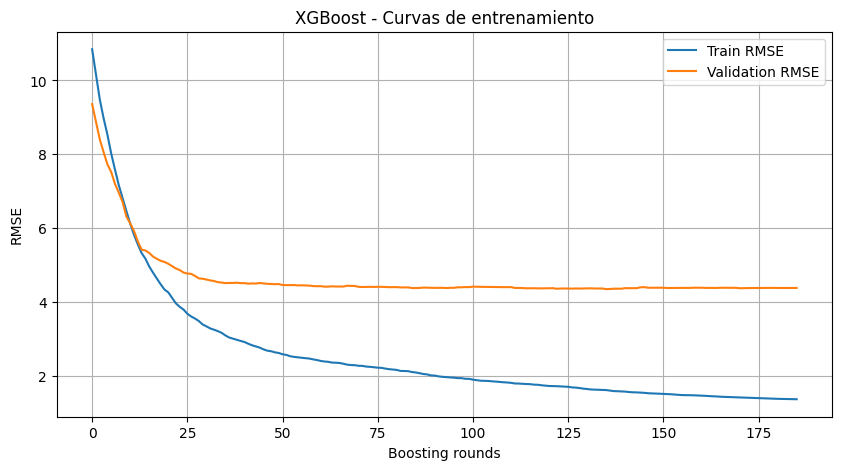

In [ ]:
# ============================================================
# 9. CURVAS DE ENTRENAMIENTO DEL MEJOR MODELO
# ============================================================
import matplotlib.pyplot as plt

results = best_model.evals_result()

train_rmse = results["validation_0"]["rmse"]
val_rmse = results["validation_1"]["rmse"]

plt.figure(figsize=(10, 5))
plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Validation RMSE")
plt.xlabel("Boosting rounds")
plt.ylabel("RMSE")
plt.title("XGBoost - Curvas de entrenamiento")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ============================================================
# 10. IMPORTANCIA DE HIPERPARÁMETROS
# ============================================================
from optuna.importance import get_param_importances

param_importances = get_param_importances(study)
print("Importancia de hiperparámetros:")
for k, v in param_importances.items():
    print(f"{k}: {v:.4f}")

Importancia de hiperparámetros:
colsample_bytree: 0.4195
learning_rate: 0.2729
max_depth: 0.1013
n_estimators: 0.0731
subsample: 0.0517
gamma: 0.0427
min_child_weight: 0.0318
reg_alpha: 0.0049
reg_lambda: 0.0020


In [ ]:
# ============================================================
# 1. ERROR MEDIO POR NODO
# ============================================================
import numpy as np
import pandas as pd

# Copia del conjunto de test alineado con las predicciones
pred_test_df = test_df[["node_id", "date", "LST"]].copy()

# Añadir predicción y errores
pred_test_df["y_pred"] = y_test_pred
pred_test_df["abs_error"] = np.abs(pred_test_df["LST"] - pred_test_df["y_pred"])
pred_test_df["sq_error"] = (pred_test_df["LST"] - pred_test_df["y_pred"]) ** 2

# Error medio por nodo
node_metrics = pred_test_df.groupby("node_id").agg(
    mae_node=("abs_error", "mean"),
    rmse_node=("sq_error", lambda x: np.sqrt(np.mean(x))),
    n_samples=("LST", "count")
).reset_index()

# Ordenar de peor a mejor según MAE
node_metrics = node_metrics.sort_values("mae_node", ascending=False).reset_index(drop=True)

print("Métricas por nodo:")
display(node_metrics.head(10))

Métricas por nodo:


,node_id,mae_node,rmse_node,n_samples
0,84,6.105925,9.766552,25
1,66,5.852312,9.380997,25
2,88,5.501443,9.576199,25
3,201,5.463776,7.364265,24
4,181,5.389308,7.393230,24
5,112,5.350372,7.514886,24
6,129,5.322863,7.437607,24
7,124,5.315089,9.188328,25
8,33,5.277669,8.621077,25
9,128,5.275367,7.304319,24


In [ ]:
# ============================================================
# 1. PREPARAR DATAFRAME DE PREDICCIONES
# ============================================================
pred_test_df = test_df[["node_id", "date", "LST"]].copy()

pred_test_df["y_pred"] = y_test_pred

# Ordenar por seguridad
pred_test_df = pred_test_df.sort_values(["node_id", "date"]).reset_index(drop=True)

display(pred_test_df.head())

,node_id,date,LST,y_pred
0,0,2024-07-30,43.855937,39.075886
1,0,2024-08-07,44.724114,32.242603
2,0,2024-08-15,43.674782,41.300900
3,0,2024-08-23,39.405675,41.430874
4,0,2024-09-08,38.311909,32.710213


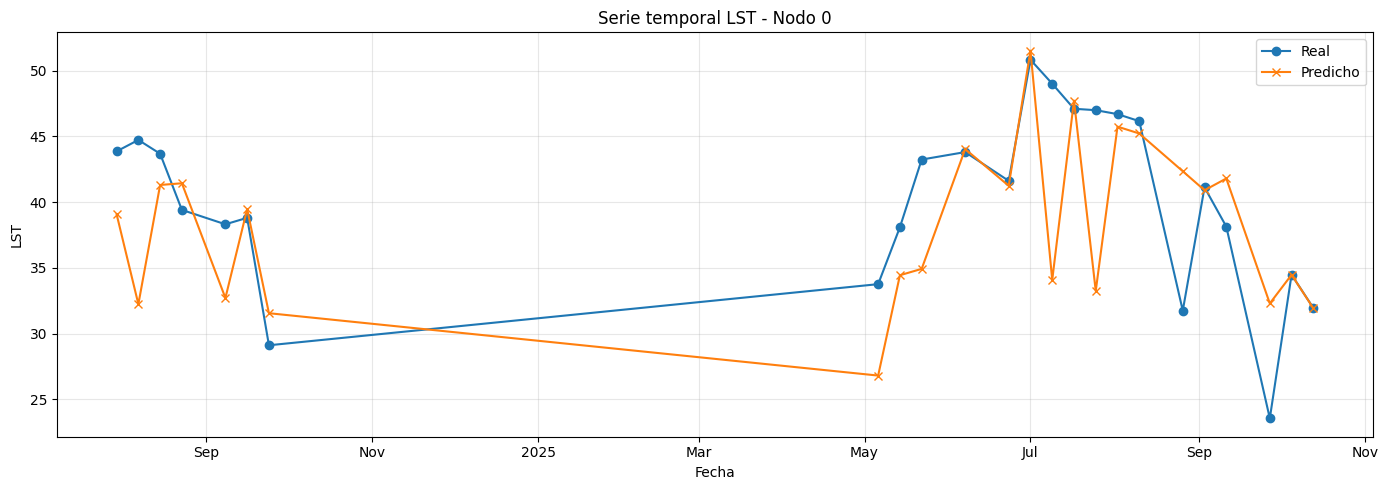

In [ ]:
# ============================================================
# SERIE TEMPORAL PARA UN NODO
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

node_example = pred_test_df["node_id"].iloc[0]

df_node = (
    pred_test_df[pred_test_df["node_id"] == node_example]
    .copy()
)

# Convertir explícitamente a datetime
df_node["date"] = pd.to_datetime(
    df_node["date"],
    errors="coerce"
)

df_node = df_node.sort_values("date")

plt.figure(figsize=(14,5))

plt.plot(
    df_node["date"],
    df_node["LST"],
    marker="o",
    label="Real"
)

plt.plot(
    df_node["date"],
    df_node["y_pred"],
    marker="x",
    label="Predicho"
)

ax = plt.gca()

# Mostrar solo algunas fechas
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.title(f"Serie temporal LST - Nodo {node_example}")
plt.xlabel("Fecha")
plt.ylabel("LST")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Modelos recurrentes


##4.1.Preprocesamiento de datos

Se construyen las secuencias temporales necesarias para los modelos recurrentes, manteniendo el mismo esquema de partición híbrida utilizado en los experimentos anteriores para garantizar una comparación justa.

In [5]:
##4.1. Preparación de los datos
# ============================================================
# PREPROCESADO RECURRENTE COMPARABLE CON GCN/XGBOOST
# TRAIN = Landsat train + Sentinel reducido
# VAL   = Landsat real
# TEST  = Landsat real
# ============================================================

import os
import random
import pandas as pd
import numpy as np

from google.colab import drive
from sklearn.preprocessing import StandardScaler

drive.mount("/content/drive")

# ============================================================
# 0. CONFIGURACIÓN
# ============================================================

BASE_PATH = "/content/drive/MyDrive/TFM"

SENTINEL_CSV = os.path.join(
    BASE_PATH,
    "datos_sentinel_downscalled.csv"
)

ORIGINAL_CSV = os.path.join(
    BASE_PATH,
    "datos_landsat.csv"
)

RANDOM_STATE = 42

SEQ_LEN = 5

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ============================================================
# 1. CARGA DE DATASETS
# ============================================================

df_s = pd.read_csv(SENTINEL_CSV)
df_o = pd.read_csv(ORIGINAL_CSV)

df_s["source"] = "sentinel_downscaled"
df_o["source"] = "landsat_original"

df_s["date"] = pd.to_datetime(df_s["date"])
df_o["date"] = pd.to_datetime(df_o["date"])

df_s["node_id"] = df_s["node_id"].astype(str)
df_o["node_id"] = df_o["node_id"].astype(str)

for df_tmp in [df_s, df_o]:
    if "lat" in df_tmp.columns:
        df_tmp.rename(columns={"lat": "latitude"}, inplace=True)
    if "lon" in df_tmp.columns:
        df_tmp.rename(columns={"lon": "longitude"}, inplace=True)

# ============================================================
# 2. FEATURES TEMPORALES Y ESPACIALES
# ============================================================

def add_spatial_temporal_features(df):
    df = df.copy()

    df["day_of_year"] = df["date"].dt.dayofyear
    df["month"] = df["date"].dt.month

    df["sin_doy"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["cos_doy"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

    node_df = (
        df[["node_id", "latitude", "longitude"]]
        .drop_duplicates("node_id")
        .copy()
    )

    node_df["lat_key"] = node_df["latitude"].round(6)
    node_df["lon_key"] = node_df["longitude"].round(6)

    lat_vals = np.sort(node_df["lat_key"].unique())[::-1]
    lon_vals = np.sort(node_df["lon_key"].unique())

    lat_to_row = {lat: i for i, lat in enumerate(lat_vals)}
    lon_to_col = {lon: j for j, lon in enumerate(lon_vals)}

    node_df["row"] = node_df["lat_key"].map(lat_to_row)
    node_df["col"] = node_df["lon_key"].map(lon_to_col)

    node_df["row_norm"] = node_df["row"] / (len(lat_vals) - 1)
    node_df["col_norm"] = node_df["col"] / (len(lon_vals) - 1)

    df = df.drop(columns=["row", "col", "row_norm", "col_norm"], errors="ignore")

    df = df.merge(
        node_df[["node_id", "row", "col", "row_norm", "col_norm"]],
        on="node_id",
        how="left",
        validate="many_to_one"
    )

    return df

df_s = add_spatial_temporal_features(df_s)
df_o = add_spatial_temporal_features(df_o)

# ============================================================
# 3. DEFINIR FEATURES
# ============================================================

FEATURES_DYNAMIC = [
    "LST",
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "rain_3d_log",
    "is_rainy",
    "ALBEDO"
]

FEATURES_STATIC = [
    "DEM",
    "NDBI",
    "aspect_ratio",
    "has_buildings"
]

FEATURES_SPACE = [
    "row_norm",
    "col_norm"
]

FEATURES_TIME = [
    "sin_doy",
    "cos_doy",
    "month"
]

FEATURES = FEATURES_DYNAMIC + FEATURES_STATIC + FEATURES_SPACE + FEATURES_TIME

TARGET = "LST"

base_cols = [
    "source",
    "node_id",
    "date",
    "latitude",
    "longitude"
]

needed_cols = list(dict.fromkeys(base_cols + FEATURES + [TARGET]))

missing_s = [c for c in needed_cols if c not in df_s.columns]
missing_o = [c for c in needed_cols if c not in df_o.columns]

if missing_s:
    raise ValueError(f"Faltan columnas en Sentinel: {missing_s}")

if missing_o:
    raise ValueError(f"Faltan columnas en Landsat original: {missing_o}")

df_s = df_s[needed_cols].copy()
df_o = df_o[needed_cols].copy()

# ============================================================
# 4. UNIR DATASETS Y LIMPIAR
# ============================================================

df = pd.concat([df_s, df_o], ignore_index=True)

df["date"] = pd.to_datetime(df["date"])
df["node_id"] = df["node_id"].astype(str)

df = df.sort_values(["node_id", "date"]).reset_index(drop=True)

df = df.dropna(subset=FEATURES + [TARGET]).copy()

print("Dataset mixto:", df.shape)
print(df["source"].value_counts())

print("\nFechas por fuente:")
print(df.groupby("source")["date"].nunique())

print("\nFeatures usadas:")
print(FEATURES)
print("Target:", TARGET)

# ============================================================
# 5. SPLIT HÍBRIDO
# TRAIN = Landsat train + Sentinel reducido
# VAL   = Landsat real
# TEST  = Landsat real
# ============================================================

df["date_str"] = df["date"].dt.strftime("%Y-%m-%d")

landsat_dates = np.array(
    sorted(df.loc[df["source"] == "landsat_original", "date_str"].unique())
)

sentinel_dates_all = np.array(
    sorted(df.loc[df["source"] == "sentinel_downscaled", "date_str"].unique())
)

n_landsat = len(landsat_dates)

landsat_train_end = int(0.70 * n_landsat)
landsat_val_end = int(0.85 * n_landsat)

landsat_train_dates = landsat_dates[:landsat_train_end]
val_dates = landsat_dates[landsat_train_end:landsat_val_end]
test_dates = landsat_dates[landsat_val_end:]

n_sentinel_target = min(
    len(sentinel_dates_all),
    SENTINEL_RATIO * len(landsat_train_dates)
)

rng = np.random.default_rng(RANDOM_STATE)

sentinel_train_dates = np.array(
    sorted(
        rng.choice(
            sentinel_dates_all,
            size=n_sentinel_target,
            replace=False
        )
    )
)

train_mask = (
    (
        (df["source"] == "landsat_original") &
        (df["date_str"].isin(landsat_train_dates))
    )
    |
    (
        (df["source"] == "sentinel_downscaled") &
        (df["date_str"].isin(sentinel_train_dates))
    )
)

val_mask = (
    (df["source"] == "landsat_original") &
    (df["date_str"].isin(val_dates))
)

test_mask = (
    (df["source"] == "landsat_original") &
    (df["date_str"].isin(test_dates))
)

df_train = df.loc[train_mask].copy()
df_val = df.loc[val_mask].copy()
df_test = df.loc[test_mask].copy()

print("\n==============================")
print("SPLIT RECURRENTE")
print("==============================")
print("Landsat train fechas:", len(landsat_train_dates))
print("Sentinel train fechas:", len(sentinel_train_dates))
print("Val Landsat fechas:", len(val_dates))
print("Test Landsat fechas:", len(test_dates))

print("\nShapes:")
print("train:", df_train.shape)
print("val:  ", df_val.shape)
print("test: ", df_test.shape)

print("\nTrain por fuente:")
print(df_train["source"].value_counts())

# ============================================================
# 6. ESCALADO
# ============================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaler.fit(df_train[FEATURES])
y_scaler.fit(df_train[[TARGET]])

df_train_scaled = df_train.copy()
df_val_scaled = df_val.copy()
df_test_scaled = df_test.copy()

df_train_scaled[FEATURES] = x_scaler.transform(df_train[FEATURES])
df_val_scaled[FEATURES] = x_scaler.transform(df_val[FEATURES])
df_test_scaled[FEATURES] = x_scaler.transform(df_test[FEATURES])

df_train_scaled[[TARGET]] = y_scaler.transform(df_train[[TARGET]])
df_val_scaled[[TARGET]] = y_scaler.transform(df_val[[TARGET]])
df_test_scaled[[TARGET]] = y_scaler.transform(df_test[[TARGET]])

print("\nx_scaler n_features_in_:", x_scaler.n_features_in_)
print("y_scaler n_features_in_:", y_scaler.n_features_in_)
print("Escalado completado.")

# ============================================================
# 7. CONSTRUCCIÓN DE SECUENCIAS
# ============================================================

def make_sequences(df_in, feature_cols, target_col, seq_len=4):
    X_list, y_list, meta_list = [], [], []

    for node_id, g in df_in.groupby("node_id"):
        g = g.sort_values("date").reset_index(drop=True)

        X_node = g[feature_cols].values
        y_node = g[target_col].values
        dates_node = g["date"].values
        source_node = g["source"].values

        if len(g) <= seq_len:
            continue

        for i in range(seq_len, len(g)):
            X_seq = X_node[i-seq_len:i]
            y_target = y_node[i]

            X_list.append(X_seq)
            y_list.append(y_target)
            meta_list.append((node_id, dates_node[i], source_node[i]))

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = np.array(meta_list, dtype=object)

    return X, y, meta

X_train_seq, y_train_seq, meta_train = make_sequences(
    df_train_scaled,
    FEATURES,
    TARGET,
    SEQ_LEN
)

X_val_seq, y_val_seq, meta_val = make_sequences(
    df_val_scaled,
    FEATURES,
    TARGET,
    SEQ_LEN
)

X_test_seq, y_test_seq, meta_test = make_sequences(
    df_test_scaled,
    FEATURES,
    TARGET,
    SEQ_LEN
)

X_test_lstm = X_test_seq
y_test_lstm = y_test_seq

print("\nShapes secuencias:")
print("X_train:", X_train_seq.shape, "y_train:", y_train_seq.shape)
print("X_val:", X_val_seq.shape, "y_val:", y_val_seq.shape)
print("X_test:", X_test_seq.shape, "y_test:", y_test_seq.shape)

Mounted at /content/drive
Dataset mixto: (441489, 22)
source
sentinel_downscaled    400950
landsat_original        40539
Name: count, dtype: int64

Fechas por fuente:
source
landsat_original        161
sentinel_downscaled    1485
Name: date, dtype: int64

Features usadas:
['LST', 'Tair_C', 'RH', 'Rsol_Wm2', 'wind_speed', 'rain_3d_log', 'is_rainy', 'ALBEDO', 'DEM', 'NDBI', 'aspect_ratio', 'has_buildings', 'row_norm', 'col_norm', 'sin_doy', 'cos_doy', 'month']
Target: LST

SPLIT RECURRENTE
Landsat train fechas: 112
Sentinel train fechas: 336
Val Landsat fechas: 24
Test Landsat fechas: 25

Shapes:
train: (118810, 23)
val:   (5981, 23)
test:  (6468, 23)

Train por fuente:
source
sentinel_downscaled    90720
landsat_original       28090
Name: count, dtype: int64

x_scaler n_features_in_: 17
y_scaler n_features_in_: 1
Escalado completado.

Shapes secuencias:
X_train: (117460, 5, 17) y_train: (117460,)
X_val: (4631, 5, 17) y_val: (4631,)
X_test: (5118, 5, 17) y_test: (5118,)


##4.2. Creación de Arquitecturas y entrenamiento

Se implementan y entrenan diferentes variantes de redes LSTM y GRU con distintas complejidades arquitectónicas, aplicando mecanismos de regularización y parada temprana para evitar sobreajuste.


In [6]:
# ============================================================
# NUEVAS ARQUITECTURAS RECURRENTES PARA COMPARAR
# ============================================================
import os
import json
import numpy as np
import tensorflow as tf
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_seq.shape[2]
input_shape = (SEQ_LEN, n_features)

def compile_model(model, lr=5e-4):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.Huber(),
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )
    return model

def build_lstm_baseline():
    model = Sequential([
        LSTM(
            16,
            input_shape=input_shape,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ),
        Dense(1)
    ])
    return compile_model(model)

def build_lstm_stacked():
    model = Sequential([
        LSTM(
            32,
            input_shape=input_shape,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ),
        LSTM(
            16,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1)
    ])
    return compile_model(model)

def build_gru_baseline():
    model = Sequential([
        GRU(
            16,
            input_shape=input_shape,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ),
        Dense(1)
    ])
    return compile_model(model)

def build_gru_stacked():
    model = Sequential([
        GRU(
            32,
            input_shape=input_shape,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ),
        GRU(
            16,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1)
    ])
    return compile_model(model)

architectures = {
    "lstm_baseline": build_lstm_baseline,
    "lstm_stacked": build_lstm_stacked,
    "gru_baseline": build_gru_baseline,
    "gru_stacked": build_gru_stacked,


}

print("Arquitecturas definidas:")
for name in architectures.keys():
    print("-", name)

Arquitecturas definidas:
- lstm_baseline
- lstm_stacked
- gru_baseline
- gru_stacked


In [ ]:
# ============================================================
# CALLBACKS DINÁMICOS POR MODELO
# ============================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SAVE_DIR = "/content/drive/MyDrive/TFM/modelos_recurrentes"
os.makedirs(SAVE_DIR, exist_ok=True)

def get_callbacks(model_name):
    best_model_path = os.path.join(SAVE_DIR, f"best_{model_name}.keras")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1
        )
    ]
    return callbacks, best_model_path

print("Directorio de guardado:", SAVE_DIR)

Directorio de guardado: /content/drive/MyDrive/TFM/modelos_recurrentes


In [ ]:
# ============================================================
# ENTRENAMIENTO DE TODAS LAS ARQUITECTURAS
# ============================================================
EPOCHS = 50
BATCH_SIZE = 64


training_times_recurrent = {}
trained_models = {}
training_histories = {}
best_model_paths = {}

for model_name, build_fn in architectures.items():
    print("\n" + "="*70)
    print(f"Entrenando modelo: {model_name}")
    print("="*70)

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    model = build_fn()
    callbacks, best_path = get_callbacks(model_name)

    print(model.summary())
    start_time = time.perf_counter()
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    total_training_time = time.perf_counter() - start_time
    n_epochs_trained = len(history.history["loss"])
    seconds_per_epoch = total_training_time / n_epochs_trained

    training_times_recurrent[model_name] = {
        "total_training_time_s": total_training_time,
        "n_epochs": n_epochs_trained,
        "seconds_per_epoch": seconds_per_epoch
    }

    trained_models[model_name] = model
    training_histories[model_name] = history.history
    best_model_paths[model_name] = best_path

print("\nEntrenamiento finalizado.")
print("Modelos entrenados:", list(trained_models.keys()))


Entrenando modelo: lstm_baseline


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193 (8.57 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 5, 32)          │         4,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,585 (29.63 KB)

 Trainable params: 7,585 (29.63 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
1835/1836 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2756 - mae: 0.5426 - rmse: 0.9280
Epoch 1: val_loss improved from None to 0.15579, saving model to /content/drive/MyDrive/TFM/modelos_recurrentes/best_gru_stacked.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFM/modelos_recurrentes/best_gru_stacked.keras
1836/1836 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - loss: 0.2516 - mae: 0.5046 - rmse: 0.8911 - val_loss: 0.1558 - val_mae: 0.4035 - val_rmse: 0.5817 - learning_rate: 5.0000e-04
Epoch 2/50
1836/1836 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2340 - mae: 0.4765 - rmse: 0.8631
Epoch 2: val_loss did not improve from 0.15579
1836/1836 ━━━━━━━━━━━━━━━━━━━━ 79s 40ms/step - loss: 0.2272 - mae: 0.4677 - rmse: 0.8476 - val_loss: 0.1668 - val_mae: 0.4274 - val_rmse: 0.5981 - learning_rate: 5.0000e-04
Epoch 3/50
1835/1836 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2216 - mae: 0.4590 - rmse: 0.8315
Epoch 3: val_loss did not improve from 0.15579
1836/1836 ━━━━━━━━

In [ ]:
# ============================================================
# GUARDAR TODOS LOS MODELOS E HISTORIALES
# ============================================================
saved_models_info = []

for model_name, model in trained_models.items():
    final_model_path = os.path.join(SAVE_DIR, f"{model_name}_final.keras")
    history_path = os.path.join(SAVE_DIR, f"{model_name}_history.json")

    # Guardar modelo final
    model.save(final_model_path)

    # Guardar historial
    with open(history_path, "w") as f:
        json.dump(training_histories[model_name], f)

    saved_models_info.append({
        "model_name": model_name,
        "best_checkpoint_path": best_model_paths[model_name],
        "final_model_path": final_model_path,
        "history_path": history_path
    })

# Guardar resumen global
summary_path = os.path.join(SAVE_DIR, "saved_models_summary.json")
with open(summary_path, "w") as f:
    json.dump(saved_models_info, f, indent=4)

print("Todos los modelos e historiales han sido guardados.")
print("Resumen:", summary_path)

saved_models_info

Todos los modelos e historiales han sido guardados.
Resumen: /content/drive/MyDrive/TFM/modelos_recurrentes/saved_models_summary.json


[{'model_name': 'lstm_baseline',
  'best_checkpoint_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/best_lstm_baseline.keras',
  'final_model_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/lstm_baseline_final.keras',
  'history_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/lstm_baseline_history.json'},
 {'model_name': 'lstm_stacked',
  'best_checkpoint_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/best_lstm_stacked.keras',
  'final_model_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/lstm_stacked_final.keras',
  'history_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/lstm_stacked_history.json'},
 {'model_name': 'gru_baseline',
  'best_checkpoint_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/best_gru_baseline.keras',
  'final_model_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/gru_baseline_final.keras',
  'history_path': '/content/drive/MyDrive/TFM/modelos_recurrentes/gru_baseline_history.json'},
 {'model_name': 'gru_sta

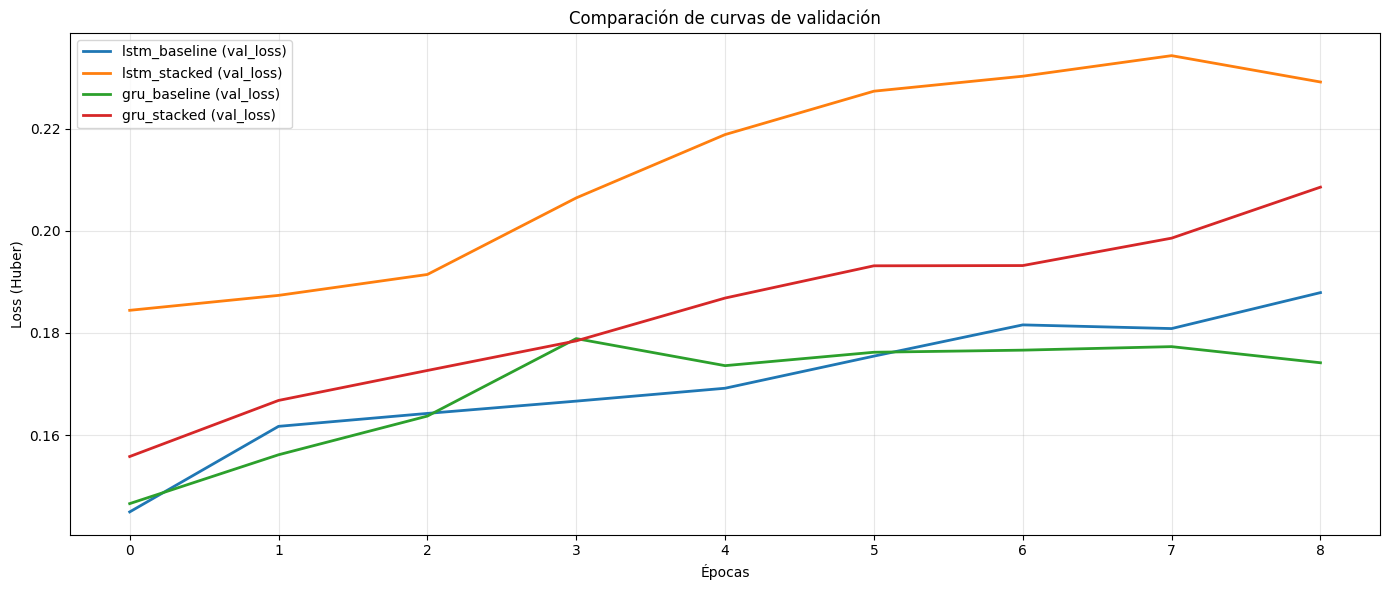

In [ ]:
# ============================================================
# CURVAS DE VALIDACIÓN (COMPARACIÓN ENTRE MODELOS)
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for model_name, history in training_histories.items():
    plt.plot(
        history["val_loss"],
        label=f"{model_name} (val_loss)",
        linewidth=2
    )

plt.title("Comparación de curvas de validación")
plt.xlabel("Épocas")
plt.ylabel("Loss (Huber)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##4.3 Evalucación y comparativa

Se evalúa el rendimiento de todas las arquitecturas mediante métricas de regresión, se establece un ranking de modelos y se analizan visualmente sus predicciones para identificar la configuración recurrente más adecuada para el problema

In [ ]:
# ============================================================
# CARGA DE MODELOS RECURRENTES DESDE DRIVE
# ============================================================
import os
import tensorflow as tf
from tensorflow.keras.models import load_model

SAVE_DIR = "/content/drive/MyDrive/TFM/modelos_recurrentes"

model_filenames = {
    "lstm_baseline": "best_lstm_baseline.keras",
    "lstm_stacked": "best_lstm_stacked.keras",
    "gru_baseline": "best_gru_baseline.keras",
    "gru_stacked": "best_gru_stacked.keras",
}

loaded_models = {}

for model_name, filename in model_filenames.items():
    model_path = os.path.join(SAVE_DIR, filename)

    if os.path.exists(model_path):
        loaded_models[model_name] = load_model(model_path)
        print(f"✅ Cargado: {model_name} -> {model_path}")
    else:
        print(f"⚠️ No encontrado: {model_path}")

print("\nModelos disponibles:", list(loaded_models.keys()))

✅ Cargado: lstm_baseline -> /content/drive/MyDrive/TFM/modelos_recurrentes/best_lstm_baseline.keras
✅ Cargado: lstm_stacked -> /content/drive/MyDrive/TFM/modelos_recurrentes/best_lstm_stacked.keras
✅ Cargado: gru_baseline -> /content/drive/MyDrive/TFM/modelos_recurrentes/best_gru_baseline.keras
✅ Cargado: gru_stacked -> /content/drive/MyDrive/TFM/modelos_recurrentes/best_gru_stacked.keras

Modelos disponibles: ['lstm_baseline', 'lstm_stacked', 'gru_baseline', 'gru_stacked']


In [ ]:
# ============================================================
# PREDICCIONES Y MÉTRICAS DE TODOS LOS MODELOS
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

def regression_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {
        "Modelo": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }

all_predictions = {}
all_metrics = []

# y_test_seq está escalado, así que lo pasamos a escala real
y_test_real = y_scaler.inverse_transform(
    np.array(y_test_seq).reshape(-1, 1)
).ravel()

for model_name, model in loaded_models.items():
    y_pred_scaled = model.predict(X_test_seq, verbose=0).ravel()

    y_pred_real = y_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).ravel()

    all_predictions[model_name] = y_pred_real
    all_metrics.append(regression_metrics(y_test_real, y_pred_real, model_name))

comparison_recurrent_df = pd.DataFrame(all_metrics).sort_values("RMSE").reset_index(drop=True)
# ============================================================
# GUARDAR MÉTRICAS TEST + LATENCIA EN CSV COMÚN
# ============================================================

for _, row in comparison_recurrent_df.iterrows():

    model_name = row["Modelo"]

    test_metrics = {
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "R2": row["R2"],
        "MAPE": row["MAPE"]
    }

    save_model_test_results(
        model_name=model_name,
        total_training_time_s=training_times_recurrent[model_name]["total_training_time_s"],
        n_epochs=training_times_recurrent[model_name]["n_epochs"],
        test_metrics=test_metrics
    )
display(comparison_recurrent_df)

Resultados acumulados guardados en:
/content/drive/MyDrive/TFM/model_results_summary.csv


,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE,sentinel_ratio
0,XGBoost,2.337024,126,0.018548,3.071004,4.298590,0.584298,8.186274,3
1,GCN,27.936010,53,0.527095,2.303982,3.715620,0.689407,6.796395,3
2,GCN_GRU,430.489783,33,13.045145,2.266650,3.620564,0.705095,6.559174,3
3,XGBoost,1.586087,69,0.022987,2.480746,3.592164,0.709703,7.042518,1
4,GCN,26.592134,37,0.718706,2.427666,3.828797,0.670197,7.218503,1
5,GCN_GRU,201.691587,26,7.757369,2.602865,3.931059,0.652345,7.479530,1
6,XGBoost,2.289224,641,0.003571,2.815163,4.023797,0.635748,8.010942,0
7,GCN,3.104944,40,0.077624,2.198127,3.374826,0.743769,6.332814,0
8,GCN_GRU,129.083542,37,3.488744,3.110610,4.495594,0.545322,8.952583,0
9,XGBoost,3.157494,170,0.018573,2.904734,3.837335,0.668725,7.971094,2


Resultados acumulados guardados en:
/content/drive/MyDrive/TFM/model_results_summary.csv


,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE,sentinel_ratio
0,XGBoost,2.337024,126,0.018548,3.071004,4.298590,0.584298,8.186274,3
1,GCN,27.936010,53,0.527095,2.303982,3.715620,0.689407,6.796395,3
2,GCN_GRU,430.489783,33,13.045145,2.266650,3.620564,0.705095,6.559174,3
3,XGBoost,1.586087,69,0.022987,2.480746,3.592164,0.709703,7.042518,1
4,GCN,26.592134,37,0.718706,2.427666,3.828797,0.670197,7.218503,1
5,GCN_GRU,201.691587,26,7.757369,2.602865,3.931059,0.652345,7.479530,1
6,XGBoost,2.289224,641,0.003571,2.815163,4.023797,0.635748,8.010942,0
7,GCN,3.104944,40,0.077624,2.198127,3.374826,0.743769,6.332814,0
8,GCN_GRU,129.083542,37,3.488744,3.110610,4.495594,0.545322,8.952583,0
9,XGBoost,3.157494,170,0.018573,2.904734,3.837335,0.668725,7.971094,2


Resultados acumulados guardados en:
/content/drive/MyDrive/TFM/model_results_summary.csv


,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE,sentinel_ratio
0,XGBoost,2.337024,126,0.018548,3.071004,4.298590,0.584298,8.186274,3
1,GCN,27.936010,53,0.527095,2.303982,3.715620,0.689407,6.796395,3
2,GCN_GRU,430.489783,33,13.045145,2.266650,3.620564,0.705095,6.559174,3
3,XGBoost,1.586087,69,0.022987,2.480746,3.592164,0.709703,7.042518,1
4,GCN,26.592134,37,0.718706,2.427666,3.828797,0.670197,7.218503,1
5,GCN_GRU,201.691587,26,7.757369,2.602865,3.931059,0.652345,7.479530,1
6,XGBoost,2.289224,641,0.003571,2.815163,4.023797,0.635748,8.010942,0
7,GCN,3.104944,40,0.077624,2.198127,3.374826,0.743769,6.332814,0
8,GCN_GRU,129.083542,37,3.488744,3.110610,4.495594,0.545322,8.952583,0
9,XGBoost,3.157494,170,0.018573,2.904734,3.837335,0.668725,7.971094,2


Resultados acumulados guardados en:
/content/drive/MyDrive/TFM/model_results_summary.csv


,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE,sentinel_ratio
0,XGBoost,2.337024,126,0.018548,3.071004,4.298590,0.584298,8.186274,3
1,GCN,27.936010,53,0.527095,2.303982,3.715620,0.689407,6.796395,3
2,GCN_GRU,430.489783,33,13.045145,2.266650,3.620564,0.705095,6.559174,3
3,XGBoost,1.586087,69,0.022987,2.480746,3.592164,0.709703,7.042518,1
4,GCN,26.592134,37,0.718706,2.427666,3.828797,0.670197,7.218503,1
5,GCN_GRU,201.691587,26,7.757369,2.602865,3.931059,0.652345,7.479530,1
6,XGBoost,2.289224,641,0.003571,2.815163,4.023797,0.635748,8.010942,0
7,GCN,3.104944,40,0.077624,2.198127,3.374826,0.743769,6.332814,0
8,GCN_GRU,129.083542,37,3.488744,3.110610,4.495594,0.545322,8.952583,0
9,XGBoost,3.157494,170,0.018573,2.904734,3.837335,0.668725,7.971094,2


,Modelo,RMSE,MAE,R2,MAPE
0,lstm_baseline,5.237514,4.301679,0.482597,0.117469
1,gru_baseline,5.505337,4.569237,0.428328,0.122501
2,gru_stacked,5.658932,4.638422,0.395985,0.123462
3,lstm_stacked,6.142130,4.811111,0.288431,0.127105


In [ ]:
# ============================================================
# RANKING POR MÉTRICAS
# ============================================================
ranking_df = comparison_recurrent_df.copy()

ranking_df["rank_RMSE"] = ranking_df["RMSE"].rank(method="min")
ranking_df["rank_MAE"] = ranking_df["MAE"].rank(method="min")
ranking_df["rank_R2"] = ranking_df["R2"].rank(method="min", ascending=False)
ranking_df["rank_MAPE"] = ranking_df["MAPE"].rank(method="min")

ranking_df["rank_global"] = (
    ranking_df["rank_RMSE"] +
    ranking_df["rank_MAE"] +
    ranking_df["rank_R2"] +
    ranking_df["rank_MAPE"]
)

ranking_df = ranking_df.sort_values("rank_global").reset_index(drop=True)
display(ranking_df)

,Modelo,RMSE,MAE,R2,MAPE,rank_RMSE,rank_MAE,rank_R2,rank_MAPE,rank_global
0,lstm_baseline,5.237514,4.301679,0.482597,0.117469,1.0,1.0,1.0,1.0,4.0
1,gru_baseline,5.505337,4.569237,0.428328,0.122501,2.0,2.0,2.0,2.0,8.0
2,gru_stacked,5.658932,4.638422,0.395985,0.123462,3.0,3.0,3.0,3.0,12.0
3,lstm_stacked,6.142130,4.811111,0.288431,0.127105,4.0,4.0,4.0,4.0,16.0


In [ ]:
# ============================================================
# DATAFRAME CON FECHAS, NODOS, VALORES REALES Y PREDICCIONES
# ============================================================
import numpy as np
import pandas as pd

# y_test_seq está escalado -> lo pasamos a escala real
y_test_real = y_scaler.inverse_transform(
    np.array(y_test_seq).reshape(-1, 1)
).ravel()

results_df = pd.DataFrame({
    "node_id": meta_test[:, 0],
    "date": pd.to_datetime(meta_test[:, 1]),
    "y_true": y_test_real
})

# Añadir predicciones de cada modelo
for model_name, model in loaded_models.items():
    y_pred_scaled = model.predict(X_test_seq, verbose=0).ravel()
    y_pred_real = y_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).ravel()

    results_df[f"pred_{model_name}"] = y_pred_real

results_df = results_df.sort_values(["node_id", "date"]).reset_index(drop=True)

display(results_df.head())
print("Número de nodos en test:", results_df["node_id"].nunique())

,node_id,date,y_true,pred_lstm_baseline,pred_lstm_stacked,pred_gru_baseline,pred_gru_stacked
0,0,2024-09-16,38.804104,36.140915,37.652721,34.839951,36.350426
1,0,2024-09-24,29.117434,35.688782,36.725830,33.991817,35.210388
2,0,2025-05-06,33.762524,32.194321,34.426697,31.263859,32.313633
3,0,2025-05-14,38.089737,40.314236,40.100864,38.664162,38.227833
4,0,2025-05-22,43.233856,41.457031,41.604824,39.060303,39.232731


Número de nodos en test: 270


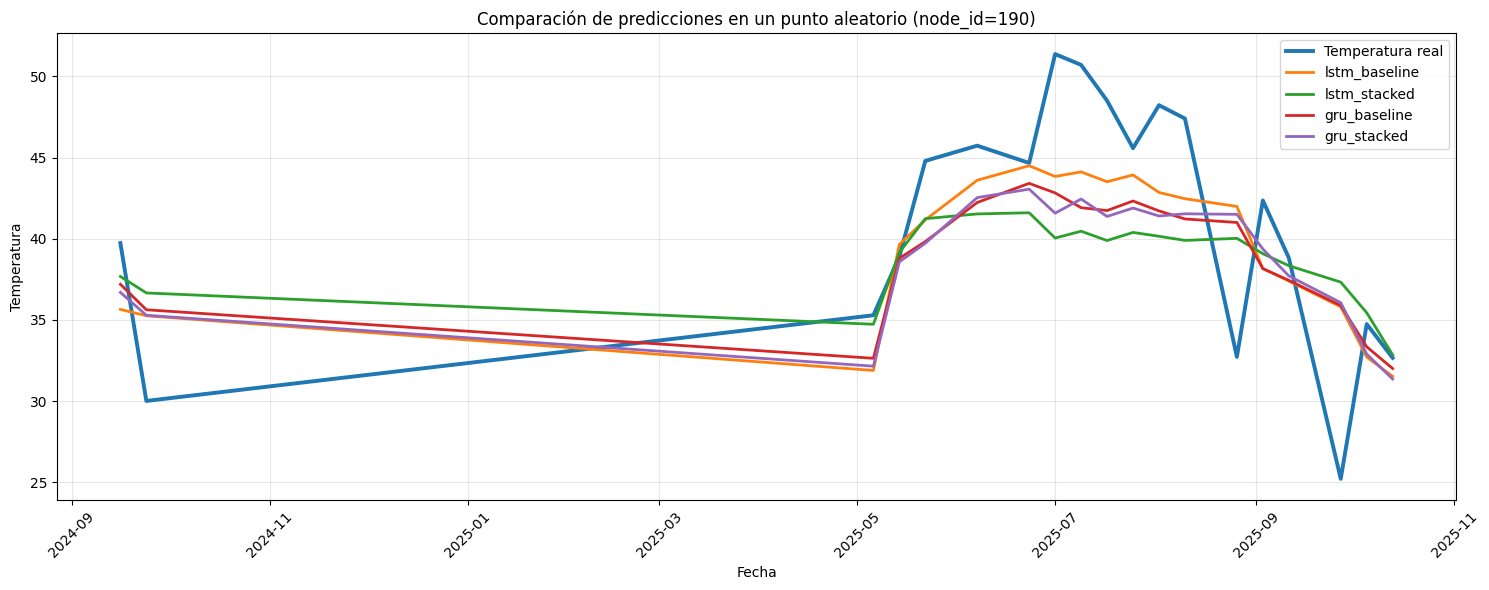

In [ ]:
# ============================================================
# GRÁFICA PARA UN PUNTO ALEATORIO (node_id)
# ============================================================
import matplotlib.pyplot as plt

# Elegir un nodo aleatorio con semilla fija para reproducibilidad
np.random.seed(42)
random_node = np.random.choice(results_df["node_id"].unique())

node_df = results_df[results_df["node_id"] == random_node].copy()
node_df = node_df.sort_values("date")

plt.figure(figsize=(15, 6))

# Curva real
plt.plot(
    node_df["date"],
    node_df["y_true"],
    label="Temperatura real",
    linewidth=2.8
)

# Curvas predichas
pred_cols = [col for col in node_df.columns if col.startswith("pred_")]

for col in pred_cols:
    plt.plot(
        node_df["date"],
        node_df[col],
        label=col.replace("pred_", ""),
        linewidth=2
    )

plt.title(f"Comparación de predicciones en un punto aleatorio (node_id={random_node})")
plt.xlabel("Fecha")
plt.ylabel("Temperatura")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# INFORMACIÓN DEL NODO SELECCIONADO
# ============================================================
print(f"node_id seleccionado: {random_node}")
print(f"Número de fechas disponibles: {len(node_df)}")
print("Rango temporal:")
print("Desde:", node_df["date"].min())
print("Hasta:", node_df["date"].max())

display(node_df[["date", "y_true"] + pred_cols].head(10))

node_id seleccionado: 190
Número de fechas disponibles: 19
Rango temporal:
Desde: 2024-09-16 00:00:00
Hasta: 2025-10-13 00:00:00


,date,y_true,pred_lstm_baseline,pred_lstm_stacked,pred_gru_baseline,pred_gru_stacked
1938,2024-09-16,39.733803,35.647110,37.676823,37.194336,36.695026
1939,2024-09-24,30.009537,35.255833,36.661266,35.625813,35.286976
1940,2025-05-06,35.286961,31.886662,34.731743,32.635357,32.149696
1941,2025-05-14,38.892971,39.648315,39.157375,38.795471,38.574299
1942,2025-05-22,44.795891,41.163807,41.236599,39.825649,39.723343
1943,2025-06-07,45.732430,43.603058,41.528889,42.234074,42.534935
1944,2025-06-23,44.666008,44.498878,41.600403,43.411942,43.053993
1945,2025-07-01,51.375584,43.834518,40.042660,42.821819,41.574383
1946,2025-07-09,50.709068,44.118916,40.464172,41.912800,42.445522
1947,2025-07-17,48.504444,43.509590,39.888241,41.736591,41.371483


#5.Construcción grafo

En esta fase se construye la representación espacio-temporal utilizada por los modelos basados en grafos. Primero se cargan y unifican los datos procedentes de Landsat y Sentinel-3, incorporando variables espaciales y temporales adicionales. A continuación, se define la estructura del grafo a partir de la disposición espacial de los nodos y se generan las conexiones entre vecinos.

Posteriormente, se realiza la partición híbrida de los datos en entrenamiento, validación y prueba, se escalan las variables utilizando únicamente la información del conjunto de entrenamiento y se transforman los datos en tensores espacio-temporales compatibles con PyTorch Geometric. Finalmente, se obtienen los índices temporales correspondientes a cada partición para facilitar el entrenamiento y la evaluación de los modelos GCN. :contentReference[oaicite:0]{index=0}

In [ ]:
import os
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import StandardScaler
from google.colab import drive

# ============================================================
# CONSTRUCCIÓN DEL GRAFO
# TRAIN = Landsat train + Sentinel downscaled reducido
# VAL   = Landsat original
# TEST  = Landsat original
# ============================================================

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/TFM"

SENTINEL_CSV = os.path.join(BASE_PATH, "datos_sentinel_downscalled.csv")
LANDSAT_CSV = os.path.join(BASE_PATH, "datos_landsat.csv")

RANDOM_STATE = 42

target_col = "LST"

feature_cols = [
    "Tair_C",
    "RH",
    "Rsol_Wm2",
    "wind_speed",
    "DEM",
    "NDBI",
    "ALBEDO",
    "aspect_ratio",
    "has_buildings",
    "row_norm",
    "col_norm",
    "sin_doy",
    "cos_doy",
    "rain_3d_log",
    "is_rainy",
]

base_cols = [
    "source",
    "node_id",
    "date",
    "latitude",
    "longitude",
    target_col,
]

needed_cols = base_cols + feature_cols

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def normalize_basic_columns(df, source_name):
    df = df.copy()

    df["source"] = source_name

    if "lat" in df.columns:
        df = df.rename(columns={"lat": "latitude"})

    if "lon" in df.columns:
        df = df.rename(columns={"lon": "longitude"})

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["node_id"] = df["node_id"].astype(str)

    return df


def add_spatial_temporal_features(df):
    df = df.copy()

    df["day_of_year"] = df["date"].dt.dayofyear
    df["sin_doy"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["cos_doy"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

    node_df = (
        df[["node_id", "latitude", "longitude"]]
        .drop_duplicates("node_id")
        .copy()
    )

    node_df["lat_key"] = node_df["latitude"].round(6)
    node_df["lon_key"] = node_df["longitude"].round(6)

    lat_vals = np.sort(node_df["lat_key"].unique())[::-1]
    lon_vals = np.sort(node_df["lon_key"].unique())

    n_rows = len(lat_vals)
    n_cols = len(lon_vals)

    node_df["row"] = node_df["lat_key"].map({lat: i for i, lat in enumerate(lat_vals)})
    node_df["col"] = node_df["lon_key"].map({lon: j for j, lon in enumerate(lon_vals)})

    node_df["row_norm"] = node_df["row"] / max(n_rows - 1, 1)
    node_df["col_norm"] = node_df["col"] / max(n_cols - 1, 1)

    df = df.drop(columns=["row", "col", "row_norm", "col_norm"], errors="ignore")

    df = df.merge(
        node_df[["node_id", "row", "col", "row_norm", "col_norm"]],
        on="node_id",
        how="left",
        validate="many_to_one"
    )

    return df


def check_required_columns(df, name):
    missing = [c for c in needed_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en {name}: {missing}")


def build_grid_edge_index(node_df, n_rows, n_cols):
    pos_to_nodeid = dict(
        zip(
            zip(node_df["row"].astype(int), node_df["col"].astype(int)),
            node_df["node_id"].astype(str)
        )
    )

    nodeid_to_idx = {
        node_id: i
        for i, node_id in enumerate(node_df["node_id"].astype(str).tolist())
    }

    edges = []
    neighbors_dict = {}

    displacements = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1)
    ]

    for _, row in node_df.iterrows():
        node_id = str(row["node_id"])
        r = int(row["row"])
        c = int(row["col"])
        src_idx = nodeid_to_idx[node_id]

        neighbors = []

        for dr, dc in displacements:
            rr = r + dr
            cc = c + dc

            if 0 <= rr < n_rows and 0 <= cc < n_cols:
                neigh_id = pos_to_nodeid.get((rr, cc))

                if neigh_id is not None:
                    dst_idx = nodeid_to_idx[str(neigh_id)]
                    edges.append((src_idx, dst_idx))
                    neighbors.append(str(neigh_id))

        neighbors_dict[node_id] = neighbors

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    degree_df = pd.DataFrame({
        "node_id": list(neighbors_dict.keys()),
        "degree": [len(v) for v in neighbors_dict.values()]
    })

    return edge_index, neighbors_dict, degree_df, nodeid_to_idx


def build_spatiotemporal_tensor(
    df,
    node_df,
    feature_cols,
    target_col,
    fill_method="ffill_bfill",
    time_col="datetime_key"
):
    df = df.copy()
    node_df = node_df.copy()

    df["node_id"] = df["node_id"].astype(str)
    node_df["node_id"] = node_df["node_id"].astype(str)

    if time_col not in df.columns:
        df[time_col] = pd.to_datetime(df["date"], errors="coerce")

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

    dup_count = df.duplicated(subset=[time_col, "node_id"]).sum()
    print("Duplicados time_col + node_id:", dup_count)

    if dup_count > 0:
        df = (
            df.sort_values([time_col, "node_id", "source"])
            .drop_duplicates(subset=[time_col, "node_id"], keep="first")
            .copy()
        )

    node_order = node_df["node_id"].astype(str).tolist()
    times = np.sort(df[time_col].dropna().unique())

    full_index = pd.MultiIndex.from_product(
        [times, node_order],
        names=[time_col, "node_id"]
    )

    work_df = df.set_index([time_col, "node_id"]).sort_index()
    work_df = work_df.reindex(full_index)

    mask = (
        work_df[feature_cols]
        .notna()
        .all(axis=1)
        .values
        .reshape(len(times), len(node_order))
    )

    cols_to_fill = feature_cols + [target_col]

    if fill_method == "ffill_bfill":
        work_df[cols_to_fill] = (
            work_df[cols_to_fill]
            .groupby(level="node_id")
            .ffill()
            .groupby(level="node_id")
            .bfill()
        )
    elif fill_method == "zero":
        work_df[cols_to_fill] = work_df[cols_to_fill].fillna(0)
    elif fill_method is None:
        pass
    else:
        raise ValueError("fill_method debe ser 'ffill_bfill', 'zero' o None")

    X = work_df[feature_cols].values.reshape(
        len(times),
        len(node_order),
        len(feature_cols)
    )

    y = work_df[target_col].values.reshape(
        len(times),
        len(node_order)
    )

    source_arr = work_df["source"].values.reshape(
        len(times),
        len(node_order)
    )

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.bool)

    return X, y, mask, times, node_order, source_arr


# ============================================================
# 1. CARGAR DATASETS
# ============================================================

df_s = pd.read_csv(SENTINEL_CSV)
df_o = pd.read_csv(LANDSAT_CSV)

df_s = normalize_basic_columns(df_s, "sentinel_downscaled")
df_o = normalize_basic_columns(df_o, "landsat_original")

df_s = add_spatial_temporal_features(df_s)
df_o = add_spatial_temporal_features(df_o)

check_required_columns(df_s, "Sentinel downscaled")
check_required_columns(df_o, "Landsat original")

df_s = df_s[needed_cols].copy()
df_o = df_o[needed_cols].copy()

# ============================================================
# 2. UNIR DATASETS SIN REPETIR CASUÍSTICA DE LLUVIA
# ============================================================

df = pd.concat([df_s, df_o], ignore_index=True)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["node_id"] = df["node_id"].astype(str)

df = df.sort_values(["date", "node_id", "source"]).reset_index(drop=True)

print("Dataset mixto:", df.shape)
print(df["source"].value_counts())

print("\nFechas por fuente:")
print(df.groupby("source")["date"].nunique())

print("\nNaNs relevantes:")
print(df[feature_cols + [target_col]].isna().sum())

# ============================================================
# 3. GEOMETRÍA DEL GRAFO DESDE LANDSAT
# ============================================================

node_df = (
    df_o[["node_id", "latitude", "longitude"]]
    .drop_duplicates("node_id")
    .sort_values("node_id")
    .reset_index(drop=True)
)

node_df["lat_key"] = node_df["latitude"].round(6)
node_df["lon_key"] = node_df["longitude"].round(6)

lat_vals = np.sort(node_df["lat_key"].unique())[::-1]
lon_vals = np.sort(node_df["lon_key"].unique())

n_rows = len(lat_vals)
n_cols = len(lon_vals)

node_df["row"] = node_df["lat_key"].map({lat: i for i, lat in enumerate(lat_vals)})
node_df["col"] = node_df["lon_key"].map({lon: j for j, lon in enumerate(lon_vals)})

print(f"\nMalla detectada: {n_rows} filas x {n_cols} columnas = {n_rows * n_cols}")
print("Nodos únicos:", node_df["node_id"].nunique())

assert node_df["node_id"].nunique() == n_rows * n_cols, \
    "El número de nodos no coincide con la malla inferida."

assert not node_df[["row", "col"]].duplicated().any(), \
    "Hay nodos duplicados en la misma posición."

edge_index, neighbors_dict, degree_df, nodeid_to_idx = build_grid_edge_index(
    node_df,
    n_rows,
    n_cols
)

print("edge_index shape:", tuple(edge_index.shape))
print("\nDistribución de grados:")
print(degree_df["degree"].value_counts().sort_index())

# ============================================================
# 4. SPLIT HÍBRIDO
# ============================================================

df["date_str"] = df["date"].dt.strftime("%Y-%m-%d")

landsat_dates = np.array(
    sorted(df.loc[df["source"] == "landsat_original", "date_str"].unique())
)

sentinel_dates_all = np.array(
    sorted(df.loc[df["source"] == "sentinel_downscaled", "date_str"].unique())
)

n_landsat = len(landsat_dates)

landsat_train_end = int(0.70 * n_landsat)
landsat_val_end = int(0.85 * n_landsat)

landsat_train_dates = landsat_dates[:landsat_train_end]
val_dates = landsat_dates[landsat_train_end:landsat_val_end]
test_dates = landsat_dates[landsat_val_end:]

n_sentinel_target = min(
    len(sentinel_dates_all),
    SENTINEL_RATIO * len(landsat_train_dates)
)

rng = np.random.default_rng(RANDOM_STATE)

sentinel_train_dates = np.array(
    sorted(
        rng.choice(
            sentinel_dates_all,
            size=n_sentinel_target,
            replace=False
        )
    )
)

train_dates = np.array(
    sorted(
        np.concatenate([
            landsat_train_dates,
            sentinel_train_dates
        ])
    )
)

train_mask_rows = (
    (
        (df["source"] == "landsat_original") &
        (df["date_str"].isin(landsat_train_dates))
    )
    |
    (
        (df["source"] == "sentinel_downscaled") &
        (df["date_str"].isin(sentinel_train_dates))
    )
)

val_mask_rows = (
    (df["source"] == "landsat_original") &
    (df["date_str"].isin(val_dates))
)

test_mask_rows = (
    (df["source"] == "landsat_original") &
    (df["date_str"].isin(test_dates))
)

print("\n==============================")
print("SPLIT HÍBRIDO")
print("==============================")
print("Fechas Landsat totales:", len(landsat_dates))
print("Fechas Sentinel totales:", len(sentinel_dates_all))
print("\nLandsat train:", len(landsat_train_dates))
print("Sentinel train usado:", len(sentinel_train_dates))
print("Val Landsat:", len(val_dates))
print("Test Landsat:", len(test_dates))
print("\nTrain total:", len(train_dates))

print("\nFilas train:", train_mask_rows.sum())
print("Filas val:", val_mask_rows.sum())
print("Filas test:", test_mask_rows.sum())

print("\nDistribución train por fuente:")
print(df.loc[train_mask_rows, "source"].value_counts())

# ============================================================
# 5. ESCALADO FIT SOLO EN TRAIN
# ============================================================

df_scaled = df.copy()

scaler_X = StandardScaler()
scaler_X.fit(df.loc[train_mask_rows, feature_cols])

df_scaled.loc[:, feature_cols] = scaler_X.transform(
    df[feature_cols]
)

scaler_y = StandardScaler()
scaler_y.fit(df.loc[train_mask_rows, [target_col]])

df_scaled.loc[:, [target_col]] = scaler_y.transform(
    df[[target_col]]
)

# ============================================================
# 6. CREAR TENSORES ESPACIO-TEMPORALES
# ============================================================

X, y, mask, dates, node_order, source_arr = build_spatiotemporal_tensor(
    df=df_scaled,
    node_df=node_df,
    feature_cols=feature_cols,
    target_col=target_col,
    fill_method="ffill_bfill"
)

print("\nX shape [T, N, F]:", tuple(X.shape))
print("y shape [T, N]:", tuple(y.shape))
print("mask shape [T, N]:", tuple(mask.shape))
print("edge_index:", tuple(edge_index.shape))
print("Features:", feature_cols)

# ============================================================
# 7. ÍNDICES TEMPORALES TRAIN / VAL / TEST
# ============================================================

date_strings = pd.to_datetime(dates).strftime("%Y-%m-%d")

train_time_idx = np.where(np.isin(date_strings, train_dates))[0]
val_time_idx = np.where(np.isin(date_strings, val_dates))[0]
test_time_idx = np.where(np.isin(date_strings, test_dates))[0]

print("\nTime idx train:", len(train_time_idx))
print("Time idx val:", len(val_time_idx))
print("Time idx test:", len(test_time_idx))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset mixto: (441489, 21)
source
sentinel_downscaled    400950
landsat_original        40539
Name: count, dtype: int64

Fechas por fuente:
source
landsat_original        161
sentinel_downscaled    1485
Name: date, dtype: int64

NaNs relevantes:
Tair_C           0
RH               0
Rsol_Wm2         0
wind_speed       0
DEM              0
NDBI             0
ALBEDO           0
aspect_ratio     0
has_buildings    0
row_norm         0
col_norm         0
sin_doy          0
cos_doy          0
rain_3d_log      0
is_rainy         0
LST              0
dtype: int64

Malla detectada: 15 filas x 18 columnas = 270
Nodos únicos: 270
edge_index shape: (2, 1966)

Distribución de grados:
degree
3      4
5     58
8    208
Name: count, dtype: int64

SPLIT HÍBRIDO
Fechas Landsat totales: 161
Fechas Sentinel totales: 1485

Landsat train: 112
Sentinel train usado: 336
Val Landsa

/tmp/ipykernel_3714/1548263906.py:444: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.09213938  0.63647566  0.18081194 ... -0.73051551 -0.27485179
  0.18081194]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_cols] = scaler_X.transform(
/tmp/ipykernel_3714/1548263906.py:444: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.24244699  0.24244699 -4.12461292 ...  0.24244699  0.24244699
  0.24244699]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_cols] = scaler_X.transform(
/tmp/ipykernel_3714/1548263906.py:444: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.32483506 0.32483506 0.32483506 ... 0.32483506 0.32483506 0.32483506]' has dtype in

Duplicados time_col + node_id: 0

X shape [T, N, F]: (1646, 270, 15)
y shape [T, N]: (1646, 270)
mask shape [T, N]: (1646, 270)
edge_index: (2, 1966)
Features: ['Tair_C', 'RH', 'Rsol_Wm2', 'wind_speed', 'DEM', 'NDBI', 'ALBEDO', 'aspect_ratio', 'has_buildings', 'row_norm', 'col_norm', 'sin_doy', 'cos_doy', 'rain_3d_log', 'is_rainy']

Time idx train: 448
Time idx val: 24
Time idx test: 25


#6. GCN

In [ ]:
!pip install torch_geometric

In [ ]:
# ============================================================
# SNAPSHOTS TEMPORALES PARA GCN
# Compatible con date/hour o fechas en diferentes formatos
# ============================================================

import torch
import time
import pandas as pd
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 1. NORMALIZAR FECHAS A STRING YYYY-MM-DD
# ============================================================

def normalize_to_date_str_array(values):
    return pd.to_datetime(values).strftime("%Y-%m-%d").to_numpy()

dates_str = normalize_to_date_str_array(dates)

train_dates_str = set(normalize_to_date_str_array(train_dates))
val_dates_str   = set(normalize_to_date_str_array(val_dates))
test_dates_str  = set(normalize_to_date_str_array(test_dates))

print("Snapshots totales:", len(dates_str))
print("Train fechas set:", len(train_dates_str))
print("Val fechas set:", len(val_dates_str))
print("Test fechas set:", len(test_dates_str))

print("\nEjemplo dates:", dates_str[:5])
print("Ejemplo train:", list(train_dates_str)[:5])
print("Ejemplo val:", list(val_dates_str)[:5])
print("Ejemplo test:", list(test_dates_str)[:5])

# ============================================================
# 2. CREAR SNAPSHOTS
# ============================================================

def build_graph_snapshots(X, y, mask, dates, dates_str, edge_index):
    graphs = []

    for t in range(X.shape[0]):
        g = Data(
            x=X[t],
            y=y[t],
            edge_index=edge_index,
        )

        g.node_mask = mask[t]
        g.date = dates_str[t]
        g.time_raw = str(dates[t])

        graphs.append(g)

    return graphs

all_graphs = build_graph_snapshots(
    X=X,
    y=y,
    mask=mask,
    dates=dates,
    dates_str=dates_str,
    edge_index=edge_index
)

# ============================================================
# 3. SPLIT POR FECHA
# ============================================================

train_graphs = [
    g for g in all_graphs
    if g.date in train_dates_str
]

val_graphs = [
    g for g in all_graphs
    if g.date in val_dates_str
]

test_graphs = [
    g for g in all_graphs
    if g.date in test_dates_str
]

print(f"\nTrain snapshots: {len(train_graphs)}")
print(f"Val snapshots:   {len(val_graphs)}")
print(f"Test snapshots:  {len(test_graphs)}")

if len(train_graphs) == 0:
    raise ValueError("train_graphs está vacío. Revisa que train_dates coincida con dates.")

if len(val_graphs) == 0:
    print("AVISO: val_graphs está vacío.")

if len(test_graphs) == 0:
    print("AVISO: test_graphs está vacío.")

# ============================================================
# 4. DATA LOADERS
# ============================================================

train_loader = DataLoader(
    train_graphs,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_graphs,
    batch_size=16,
    shuffle=False
) if len(val_graphs) > 0 else None

test_loader = DataLoader(
    test_graphs,
    batch_size=16,
    shuffle=False
) if len(test_graphs) > 0 else None

Device: cuda
Snapshots totales: 1646
Train fechas set: 1008
Val fechas set: 24
Test fechas set: 25

Ejemplo dates: ['2013-05-05' '2013-05-21' '2013-06-22' '2013-07-08' '2013-07-24']
Ejemplo train: ['2016-08-18', '2025-05-11', '2023-08-18', '2024-09-12', '2019-08-21']
Ejemplo val: ['2023-08-05', '2023-07-28', '2023-06-10', '2023-08-13', '2024-07-14']
Ejemplo test: ['2025-07-09', '2025-07-25', '2025-05-22', '2025-07-01', '2025-10-05']

Train snapshots: 1008
Val snapshots:   24
Test snapshots:  25


In [ ]:
import torch.nn as nn
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
class GCNRegressorResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.20):
        super().__init__()

        self.input_proj = nn.Linear(in_channels, hidden_channels)

        self.conv1 = GCNConv(
            hidden_channels,
            hidden_channels,
            add_self_loops=True,
            normalize=True
        )
        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels,
            add_self_loops=True,
            normalize=True
        )
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x0 = self.input_proj(x)

        h = self.conv1(x0, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)

        # conexión residual
        h = h + x0

        h = F.dropout(h, p=self.dropout, training=self.training)

        out = self.head(h).squeeze(-1)
        return out

model = GCNRegressorResidual(
    in_channels=X.shape[-1],
    hidden_channels=64,
    dropout=0.20
).to(device)

In [ ]:
# ============================================================
# ENTRENAMIENTO, EARLY STOPPING Y MÉTRICAS
# ============================================================
import copy
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def masked_mse_loss(pred, target, mask):
    pred = pred[mask]
    target = target[mask]
    return F.mse_loss(pred, target)

#prueba
def masked_loss(pred, target, mask):
    pred = pred[mask]
    target = target[mask]
    return F.huber_loss(pred, target, delta=1.0)

def inverse_transform_target(arr_1d, scaler_y):
    """
    arr_1d: numpy array shape [n]
    scaler_y: StandardScaler ajustado sobre el target
    """
    return scaler_y.inverse_transform(arr_1d.reshape(-1, 1)).reshape(-1)

def compute_metrics(y_true, y_pred, eps=1e-8):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    denom = np.maximum(np.abs(y_true), eps)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }

@torch.no_grad()
def evaluate(model, loader, scaler_y, device):
    model.eval()

    total_loss = 0.0
    total_graphs = 0

    all_preds = []
    all_targets = []

    for batch in loader:
        batch = batch.to(device)

        pred = model(batch)
        loss = masked_loss(pred, batch.y, batch.node_mask)
        #loss = masked_mse_loss(pred, batch.y, batch.node_mask)

        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs

        pred_masked = pred[batch.node_mask].detach().cpu().numpy()
        y_masked = batch.y[batch.node_mask].detach().cpu().numpy()

        # desnormalizamos para métricas interpretables
        pred_real = inverse_transform_target(pred_masked, scaler_y)
        y_real = inverse_transform_target(y_masked, scaler_y)

        all_preds.append(pred_real)
        all_targets.append(y_real)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    metrics = compute_metrics(all_targets, all_preds)
    avg_loss = total_loss / total_graphs

    return avg_loss, metrics

def train_model(
    model,
    train_loader,
    val_loader,
    scaler_y,
    device,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=20,
    grad_clip=1.0
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=6
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_RMSE": [],
        "val_MAE": [],
        "val_R2": [],
        "val_MAPE": []
    }

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        total_graphs = 0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()

            pred = model(batch)
            #loss = masked_mse_loss(pred, batch.y, batch.node_mask)
            loss = masked_loss(pred, batch.y, batch.node_mask)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()

            running_loss += loss.item() * batch.num_graphs
            total_graphs += batch.num_graphs

        train_loss = running_loss / total_graphs
        val_loss, val_metrics = evaluate(model, val_loader, scaler_y, device)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_RMSE"].append(val_metrics["RMSE"])
        history["val_MAE"].append(val_metrics["MAE"])
        history["val_R2"].append(val_metrics["R2"])
        history["val_MAPE"].append(val_metrics["MAPE"])

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"RMSE={val_metrics['RMSE']:.4f} | "
            f"MAE={val_metrics['MAE']:.4f} | "
            f"R2={val_metrics['R2']:.4f} | "
            f"MAPE={val_metrics['MAPE']:.2f}% | "
            f"lr={current_lr:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping en epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    return model, history

In [ ]:
start_time_gcn = time.perf_counter()
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    scaler_y=scaler_y,
    device=device,
    lr=7e-4,
    weight_decay=1e-5,
    max_epochs=250,
    patience=30,
    grad_clip=1.0
)

total_training_time_gcn = time.perf_counter() - start_time_gcn
n_epochs_gcn = len(history["train_loss"])

test_loss, test_metrics = evaluate(model, test_loader, scaler_y, device)

print("\n===== RESULTADOS EN TEST =====")
for k, v in test_metrics.items():
    if k == "MAPE":
        print(f"{k}: {v:.2f}%")
    else:
        print(f"{k}: {v:.4f}")

save_model_test_results(
    model_name="GCN",
    total_training_time_s=total_training_time_gcn,
    n_epochs=n_epochs_gcn,
    test_metrics=test_metrics
)

Epoch 001 | train_loss=0.2084 | val_loss=0.1026 | RMSE=5.5714 | MAE=3.5951 | R2=0.5477 | MAPE=11.78% | lr=7.00e-04
Epoch 002 | train_loss=0.1780 | val_loss=0.0954 | RMSE=5.3640 | MAE=3.3982 | R2=0.5807 | MAPE=11.43% | lr=7.00e-04
Epoch 003 | train_loss=0.1757 | val_loss=0.0971 | RMSE=5.4027 | MAE=3.4663 | R2=0.5746 | MAPE=11.49% | lr=7.00e-04
Epoch 004 | train_loss=0.1711 | val_loss=0.0876 | RMSE=5.2095 | MAE=3.1024 | R2=0.6045 | MAPE=10.71% | lr=7.00e-04
Epoch 005 | train_loss=0.1693 | val_loss=0.0954 | RMSE=5.3676 | MAE=3.4203 | R2=0.5801 | MAPE=11.45% | lr=7.00e-04
Epoch 006 | train_loss=0.1673 | val_loss=0.0877 | RMSE=5.1337 | MAE=3.2092 | R2=0.6159 | MAPE=10.75% | lr=7.00e-04
Epoch 007 | train_loss=0.1668 | val_loss=0.0944 | RMSE=5.2957 | MAE=3.4543 | R2=0.5913 | MAPE=11.03% | lr=7.00e-04
Epoch 008 | train_loss=0.1678 | val_loss=0.0847 | RMSE=5.1007 | MAE=3.0001 | R2=0.6209 | MAPE=10.01% | lr=7.00e-04
Epoch 009 | train_loss=0.1642 | val_loss=0.1352 | RMSE=6.3264 | MAE=4.0251 | R2=

,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE,sentinel_ratio
0,XGBoost,2.337024,126,0.018548,3.071004,4.298590,0.584298,8.186274,3
1,GCN,27.936010,53,0.527095,2.303982,3.715620,0.689407,6.796395,3
2,GCN_GRU,430.489783,33,13.045145,2.266650,3.620564,0.705095,6.559174,3
3,XGBoost,1.586087,69,0.022987,2.480746,3.592164,0.709703,7.042518,1
4,GCN,26.592134,37,0.718706,2.427666,3.828797,0.670197,7.218503,1
5,GCN_GRU,201.691587,26,7.757369,2.602865,3.931059,0.652345,7.479530,1
6,XGBoost,2.289224,641,0.003571,2.815163,4.023797,0.635748,8.010942,0
7,GCN,3.104944,40,0.077624,2.198127,3.374826,0.743769,6.332814,0
8,GCN_GRU,129.083542,37,3.488744,3.110610,4.495594,0.545322,8.952583,0
9,XGBoost,3.157494,170,0.018573,2.904734,3.837335,0.668725,7.971094,2


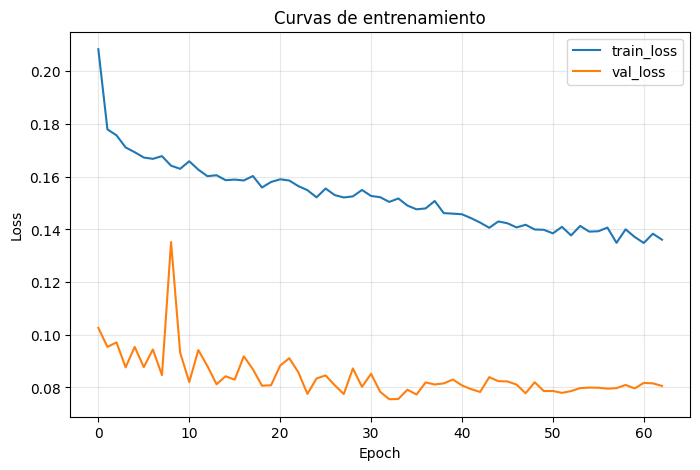

In [ ]:
# ============================================================
# 10. CURVAS DE ENTRENAMIENTO
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curvas de entrenamiento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Ablation study: efecto de una variable



En esta sección se evalúa la importancia de una variable a especificar dentro del modelo `GCNResidual`. Para ello, se comparan dos configuraciones: una entrenada con todas las variables originales y otra eliminando dicha variable del conjunto de entrada.

El experimento se repite con varias semillas para reducir la dependencia de una única inicialización aleatoria. Posteriormente, se comparan las métricas de test mediante medias, desviaciones estándar y diferencias pareadas por semilla. Así, se puede analizar si eliminarla empeora o mejora el rendimiento del modelo en términos de RMSE, MAE, R² y MAPE.

In [ ]:
# ============================================================
# ABLATION: GCNResidual CON / SIN VARIABLES DE LLUVIA
# Compatible con tu celda GCN actual
# ============================================================

import random
import contextlib
import io
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import StandardScaler
from torch_geometric.loader import DataLoader

# ============================================================
# CONFIGURACIÓN
# ============================================================

cols_to_ablate = [
    "wind_speed"
]

SEEDS = [42, 123, 2024, 7, 99]
BATCH_SIZE = 16

LR = 7e-4
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 250
PATIENCE = 30
GRAD_CLIP = 1.0

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def prepare_loaders_for_features(selected_feature_cols, batch_size=16):
    df_scaled_run = df.copy()

    # Evita warnings al escalar columnas enteras/binarias
    df_scaled_run[selected_feature_cols] = (
        df_scaled_run[selected_feature_cols]
        .astype(float)
    )

    df_scaled_run[target_col] = df_scaled_run[target_col].astype(float)

    # Escalado de X solo con TRAIN híbrido
    scaler_X_run = StandardScaler()
    scaler_X_run.fit(
        df_scaled_run.loc[train_mask_rows, selected_feature_cols]
    )

    df_scaled_run.loc[:, selected_feature_cols] = scaler_X_run.transform(
        df_scaled_run[selected_feature_cols]
    )

    # Escalado de y solo con TRAIN híbrido
    scaler_y_run = StandardScaler()
    scaler_y_run.fit(
        df_scaled_run.loc[train_mask_rows, [target_col]]
    )

    df_scaled_run.loc[:, [target_col]] = scaler_y_run.transform(
        df_scaled_run[[target_col]]
    )

    # Construcción tensorial
    X_run, y_run, mask_run, dates_run, node_order_run, source_arr_run = build_spatiotemporal_tensor(
        df=df_scaled_run,
        node_df=node_df,
        feature_cols=selected_feature_cols,
        target_col=target_col,
        fill_method="ffill_bfill"
    )

    dates_str_run = normalize_to_date_str_array(dates_run)

    all_graphs_run = build_graph_snapshots(
        X=X_run,
        y=y_run,
        mask=mask_run,
        dates=dates_run,
        dates_str=dates_str_run,
        edge_index=edge_index
    )

    train_dates_str_run = set(normalize_to_date_str_array(train_dates))
    val_dates_str_run = set(normalize_to_date_str_array(val_dates))
    test_dates_str_run = set(normalize_to_date_str_array(test_dates))

    train_graphs_run = [
        g for g in all_graphs_run
        if g.date in train_dates_str_run
    ]

    val_graphs_run = [
        g for g in all_graphs_run
        if g.date in val_dates_str_run
    ]

    test_graphs_run = [
        g for g in all_graphs_run
        if g.date in test_dates_str_run
    ]

    if len(train_graphs_run) == 0:
        raise ValueError("train_graphs_run está vacío.")

    if len(val_graphs_run) == 0:
        raise ValueError("val_graphs_run está vacío.")

    if len(test_graphs_run) == 0:
        raise ValueError("test_graphs_run está vacío.")

    train_loader_run = DataLoader(
        train_graphs_run,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader_run = DataLoader(
        val_graphs_run,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader_run = DataLoader(
        test_graphs_run,
        batch_size=batch_size,
        shuffle=False
    )

    return (
        train_loader_run,
        val_loader_run,
        test_loader_run,
        scaler_y_run,
        len(selected_feature_cols)
    )


def run_gcn_ablation_experiment(selected_feature_cols, label, seed, verbose=False):
    set_seed(seed)

    train_loader_run, val_loader_run, test_loader_run, scaler_y_run, n_features = (
        prepare_loaders_for_features(
            selected_feature_cols=selected_feature_cols,
            batch_size=BATCH_SIZE
        )
    )

    model_run = GCNRegressorResidual(
        in_channels=n_features,
        hidden_channels=64,
        dropout=0.20
    ).to(device)

    if verbose:
        model_run, history_run = train_model(
            model=model_run,
            train_loader=train_loader_run,
            val_loader=val_loader_run,
            scaler_y=scaler_y_run,
            device=device,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            grad_clip=GRAD_CLIP
        )
    else:
        with contextlib.redirect_stdout(io.StringIO()):
            model_run, history_run = train_model(
                model=model_run,
                train_loader=train_loader_run,
                val_loader=val_loader_run,
                scaler_y=scaler_y_run,
                device=device,
                lr=LR,
                weight_decay=WEIGHT_DECAY,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                grad_clip=GRAD_CLIP
            )

    test_loss, test_metrics = evaluate(
        model=model_run,
        loader=test_loader_run,
        scaler_y=scaler_y_run,
        device=device
    )

    return {
        "experiment": label,
        "seed": seed,
        "n_features": n_features,
        "test_loss": test_loss,
        **test_metrics
    }


# ============================================================
# FEATURES CON Y SIN VARIABLES
# ============================================================

missing_cols = [
    c for c in cols_to_ablate
    if c not in feature_cols
]

if missing_cols:
    raise ValueError(f"Estas columnas no están en feature_cols: {missing_cols}")

features_with_cols = feature_cols.copy()

features_without_cols = [
    c for c in feature_cols
    if c not in cols_to_ablate
]

print("Variables evaluadas como grupo:", cols_to_ablate)
print("Nº features CON variables:", len(features_with_cols))
print("Nº features SIN variables:", len(features_without_cols))

print("\nFeatures CON variables:")
print(features_with_cols)

print("\nFeatures SIN variables:")
print(features_without_cols)

# ============================================================
# EJECUCIÓN
# ============================================================

results = []

for seed in SEEDS:

    print(f"\nSeed {seed} | Entrenando CON variables...")

    results.append(
        run_gcn_ablation_experiment(
            selected_feature_cols=features_with_cols,
            label="CON_features",
            seed=seed,
            verbose=False
        )
    )

    print(f"Seed {seed} | Entrenando SIN variables...")

    results.append(
        run_gcn_ablation_experiment(
            selected_feature_cols=features_without_cols,
            label="SIN_features",
            seed=seed,
            verbose=False
        )
    )

results_df = pd.DataFrame(results)

display(results_df)

# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

summary_df = (
    results_df
    .groupby("experiment")[["RMSE", "MAE", "R2", "MAPE"]]
    .agg(["mean", "std"])
)

display(summary_df)

# ============================================================
# DIFERENCIA PAREADA POR SEED
# ============================================================

paired = results_df.pivot(
    index="seed",
    columns="experiment",
    values=["RMSE", "MAE", "R2", "MAPE"]
)

diff_df = pd.DataFrame({
    "seed": paired.index,

    "delta_RMSE_SIN_minus_CON":
        paired["RMSE"]["SIN_features"] -
        paired["RMSE"]["CON_features"],

    "delta_MAE_SIN_minus_CON":
        paired["MAE"]["SIN_features"] -
        paired["MAE"]["CON_features"],

    "delta_R2_SIN_minus_CON":
        paired["R2"]["SIN_features"] -
        paired["R2"]["CON_features"],

    "delta_MAPE_SIN_minus_CON":
        paired["MAPE"]["SIN_features"] -
        paired["MAPE"]["CON_features"],
})

display(diff_df)

print("\nInterpretación rápida:")
print("delta_RMSE_SIN_minus_CON > 0  → quitarla empeora RMSE.")
print("delta_MAE_SIN_minus_CON > 0   → quitarla empeora MAE.")
print("delta_R2_SIN_minus_CON < 0    → quitarla empeora R2.")
print("delta_MAPE_SIN_minus_CON > 0  → quitarla empeora MAPE.")

print("\nMedia de diferencias:")
display(diff_df.drop(columns="seed").mean().to_frame("media"))

Variables evaluadas como grupo: ['wind_speed']
Nº features CON variables: 15
Nº features SIN variables: 14

Features CON variables:
['Tair_C', 'RH', 'Rsol_Wm2', 'wind_speed', 'DEM', 'NDBI', 'ALBEDO', 'aspect_ratio', 'has_buildings', 'row_norm', 'col_norm', 'sin_doy', 'cos_doy', 'rain_3d_log', 'is_rainy']

Features SIN variables:
['Tair_C', 'RH', 'Rsol_Wm2', 'DEM', 'NDBI', 'ALBEDO', 'aspect_ratio', 'has_buildings', 'row_norm', 'col_norm', 'sin_doy', 'cos_doy', 'rain_3d_log', 'is_rainy']

Seed 42 | Entrenando CON variables...
Duplicados time_col + node_id: 0
Seed 42 | Entrenando SIN variables...
Duplicados time_col + node_id: 0

Seed 123 | Entrenando CON variables...
Duplicados time_col + node_id: 0
Seed 123 | Entrenando SIN variables...
Duplicados time_col + node_id: 0

Seed 2024 | Entrenando CON variables...
Duplicados time_col + node_id: 0
Seed 2024 | Entrenando SIN variables...
Duplicados time_col + node_id: 0

Seed 7 | Entrenando CON variables...
Duplicados time_col + node_id: 0
See

,experiment,seed,n_features,test_loss,RMSE,MAE,R2,MAPE
0,CON_features,42,15,0.046627,3.698356,2.280069,0.692286,6.646093
1,SIN_features,42,14,0.044830,3.617538,2.296603,0.705588,6.620269
2,CON_features,123,15,0.043512,3.572110,2.249601,0.712936,6.490180
3,SIN_features,123,14,0.038818,3.379633,2.114555,0.743038,6.175898
4,CON_features,2024,15,0.045702,3.649225,2.472552,0.700408,7.027736
5,SIN_features,2024,14,0.039964,3.429745,2.179117,0.735361,6.331593
6,CON_features,7,15,0.047697,3.706535,2.542236,0.690924,7.103209
7,SIN_features,7,14,0.044710,3.610340,2.504568,0.706758,7.118857
8,CON_features,99,15,0.046933,3.715031,2.294705,0.689505,6.754103
9,SIN_features,99,14,0.040459,3.440220,2.355586,0.733742,6.683867


RMSE                 MAE                  R2            \
                  mean       std      mean       std      mean       std   
experiment                                                                 
CON_features  3.668251  0.059509  2.367833  0.130778  0.697212  0.009755   
SIN_features  3.495495  0.110551  2.290086  0.152856  0.724898  0.017455   

                  MAPE            
                  mean       std  
experiment                        
CON_features  6.804264  0.257629  
SIN_features  6.586097  0.363179

,seed,delta_RMSE_SIN_minus_CON,delta_MAE_SIN_minus_CON,delta_R2_SIN_minus_CON,delta_MAPE_SIN_minus_CON
seed,,,,,
7,7,-0.096196,-0.037668,0.015835,0.015648
42,42,-0.080818,0.016533,0.013302,-0.025824
99,99,-0.274810,0.060881,0.044237,-0.070235
123,123,-0.192477,-0.135046,0.030102,-0.314282
2024,2024,-0.219479,-0.293435,0.034954,-0.696143



Interpretación rápida:
delta_RMSE_SIN_minus_CON > 0  → quitarla empeora RMSE.
delta_MAE_SIN_minus_CON > 0   → quitarla empeora MAE.
delta_R2_SIN_minus_CON < 0    → quitarla empeora R2.
delta_MAPE_SIN_minus_CON > 0  → quitarla empeora MAPE.

Media de diferencias:


,media
delta_RMSE_SIN_minus_CON,-0.172756
delta_MAE_SIN_minus_CON,-0.077747
delta_R2_SIN_minus_CON,0.027686
delta_MAPE_SIN_minus_CON,-0.218167


#8. GraphSage model

In [ ]:
# ============================================================
# 1. SNAPSHOTS TEMPORALES PARA GRAPHSAGE
# ============================================================

!pip -q install torch_geometric

import torch
import pandas as pd
import numpy as np
import time

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def normalize_to_date_str_array(values):
    return pd.to_datetime(values).strftime("%Y-%m-%d").to_numpy()

dates_str = normalize_to_date_str_array(dates)

train_dates_str = set(normalize_to_date_str_array(train_dates))
val_dates_str   = set(normalize_to_date_str_array(val_dates))
test_dates_str  = set(normalize_to_date_str_array(test_dates))

def build_graph_snapshots(X, y, mask, dates, dates_str, edge_index):
    graphs = []

    for t in range(X.shape[0]):
        g = Data(
            x=X[t],
            y=y[t],
            edge_index=edge_index
        )

        g.node_mask = mask[t]
        g.date = dates_str[t]
        g.time_raw = str(dates[t])

        graphs.append(g)

    return graphs

all_graphs = build_graph_snapshots(
    X=X,
    y=y,
    mask=mask,
    dates=dates,
    dates_str=dates_str,
    edge_index=edge_index
)

train_graphs = [g for g in all_graphs if g.date in train_dates_str]
val_graphs   = [g for g in all_graphs if g.date in val_dates_str]
test_graphs  = [g for g in all_graphs if g.date in test_dates_str]

print("Train snapshots:", len(train_graphs))
print("Val snapshots:  ", len(val_graphs))
print("Test snapshots: ", len(test_graphs))

train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=16, shuffle=False)

Device: cuda
Train snapshots: 448
Val snapshots:   24
Test snapshots:  25


In [ ]:
# ============================================================
# 2. MODELO GRAPHSAGE
# ============================================================

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGERegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.25):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        out = self.head(x).squeeze(-1)
        return out

model = GraphSAGERegressor(
    in_channels=X.shape[-1],
    hidden_channels=64,
    dropout=0.25
).to(device)

print(model)

GraphSAGERegressor(
  (conv1): SAGEConv(15, 64, aggr=mean)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
# ============================================================
# 3. LOSS, MÉTRICAS Y EVALUACIÓN
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def masked_mse_loss(pred, target, mask):
    pred = pred[mask]
    target = target[mask]
    return F.mse_loss(pred, target)

def inverse_transform_target(arr_1d, scaler_y):
    return scaler_y.inverse_transform(arr_1d.reshape(-1, 1)).reshape(-1)

def compute_metrics(y_true, y_pred, eps=1e-8):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    denom = np.maximum(np.abs(y_true), eps)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }

@torch.no_grad()
def evaluate(model, loader, scaler_y, device):
    model.eval()

    total_loss = 0.0
    total_graphs = 0

    all_preds = []
    all_targets = []

    for batch in loader:
        batch = batch.to(device)

        pred = model(batch)
        loss = masked_mse_loss(pred, batch.y, batch.node_mask)

        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs

        pred_masked = pred[batch.node_mask].detach().cpu().numpy()
        y_masked = batch.y[batch.node_mask].detach().cpu().numpy()

        pred_real = inverse_transform_target(pred_masked, scaler_y)
        y_real = inverse_transform_target(y_masked, scaler_y)

        all_preds.append(pred_real)
        all_targets.append(y_real)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    metrics = compute_metrics(all_targets, all_preds)
    avg_loss = total_loss / total_graphs

    return avg_loss, metrics

In [ ]:
# ============================================================
# 4. ENTRENAMIENTO GRAPHSAGE
# ============================================================

import copy

def train_graphsage(
    model,
    train_loader,
    val_loader,
    scaler_y,
    device,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=20,
    grad_clip=1.0
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=6
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_MAE": [],
        "val_MAE": [],
        "val_RMSE": [],
        "val_R2": [],
        "val_MAPE": []
    }

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()

        total_loss = 0.0
        total_graphs = 0

        train_preds = []
        train_targets = []

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()

            pred = model(batch)
            loss = masked_mse_loss(pred, batch.y, batch.node_mask)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()

            total_loss += loss.item() * batch.num_graphs
            total_graphs += batch.num_graphs

            pred_masked = pred[batch.node_mask].detach().cpu().numpy()
            y_masked = batch.y[batch.node_mask].detach().cpu().numpy()

            pred_real = inverse_transform_target(pred_masked, scaler_y)
            y_real = inverse_transform_target(y_masked, scaler_y)

            train_preds.append(pred_real)
            train_targets.append(y_real)

        train_loss = total_loss / total_graphs

        train_preds = np.concatenate(train_preds)
        train_targets = np.concatenate(train_targets)
        train_metrics = compute_metrics(train_targets, train_preds)

        val_loss, val_metrics = evaluate(model, val_loader, scaler_y, device)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_MAE"].append(train_metrics["MAE"])
        history["val_MAE"].append(val_metrics["MAE"])
        history["val_RMSE"].append(val_metrics["RMSE"])
        history["val_R2"].append(val_metrics["R2"])
        history["val_MAPE"].append(val_metrics["MAPE"])

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_MAE={train_metrics['MAE']:.4f} | "
            f"val_MAE={val_metrics['MAE']:.4f} | "
            f"val_RMSE={val_metrics['RMSE']:.4f} | "
            f"val_R2={val_metrics['R2']:.4f} | "
            f"lr={current_lr:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping en epoch {epoch}.")
            break

    model.load_state_dict(best_state)

    return model, history

start_time_sage = time.perf_counter()
model, history = train_graphsage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    scaler_y=scaler_y,
    device=device,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=20,
    grad_clip=1.0
)

total_training_time_sage = time.perf_counter() - start_time_sage
n_epochs_sage = len(history["train_loss"])

Epoch 001 | train_loss=0.7781 | val_loss=0.2921 | train_MAE=6.6202 | val_MAE=4.8469 | val_RMSE=6.2896 | val_R2=0.4235 | lr=1.00e-03
Epoch 002 | train_loss=0.5799 | val_loss=0.2829 | train_MAE=5.6042 | val_MAE=4.5441 | val_RMSE=6.2123 | val_R2=0.4376 | lr=1.00e-03
Epoch 003 | train_loss=0.6302 | val_loss=0.2289 | train_MAE=5.7031 | val_MAE=3.9678 | val_RMSE=5.5544 | val_R2=0.5504 | lr=1.00e-03
Epoch 004 | train_loss=0.5773 | val_loss=0.2287 | train_MAE=5.4602 | val_MAE=3.9260 | val_RMSE=5.5556 | val_R2=0.5502 | lr=1.00e-03
Epoch 005 | train_loss=0.5779 | val_loss=0.2348 | train_MAE=5.2674 | val_MAE=3.8052 | val_RMSE=5.6313 | val_R2=0.5379 | lr=1.00e-03
Epoch 006 | train_loss=0.5450 | val_loss=0.3033 | train_MAE=5.4850 | val_MAE=4.3963 | val_RMSE=6.4647 | val_R2=0.3910 | lr=1.00e-03
Epoch 007 | train_loss=0.5739 | val_loss=0.2235 | train_MAE=5.4362 | val_MAE=3.5879 | val_RMSE=5.4812 | val_R2=0.5622 | lr=1.00e-03
Epoch 008 | train_loss=0.5446 | val_loss=0.2145 | train_MAE=5.1604 | val_MAE

In [ ]:
# ============================================================
# 5. EVALUACIÓN FINAL EN TEST
# ============================================================

test_loss, test_metrics = evaluate(
    model=model,
    loader=test_loader,
    scaler_y=scaler_y,
    device=device
)
save_model_test_results(
    model_name="Graph Sage",
    total_training_time_s=total_training_time_sage,
    n_epochs=n_epochs_sage,
    test_metrics=test_metrics
)
print("\n===== RESULTADOS GRAPHSAGE EN TEST =====")
print(f"RMSE: {test_metrics['RMSE']:.4f}")
print(f"MAE:  {test_metrics['MAE']:.4f}")
print(f"R2:   {test_metrics['R2']:.4f}")
print(f"MAPE: {test_metrics['MAPE']:.2f}%")

Resultados acumulados guardados en:
/content/drive/MyDrive/TFM/model_results_summary.csv


,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE,sentinel_ratio
0,XGBoost,2.337024,126,0.018548,3.071004,4.298590,0.584298,8.186274,3
1,GCN,27.936010,53,0.527095,2.303982,3.715620,0.689407,6.796395,3
2,GCN_GRU,430.489783,33,13.045145,2.266650,3.620564,0.705095,6.559174,3
3,XGBoost,1.586087,69,0.022987,2.480746,3.592164,0.709703,7.042518,1
4,GCN,26.592134,37,0.718706,2.427666,3.828797,0.670197,7.218503,1
5,GCN_GRU,201.691587,26,7.757369,2.602865,3.931059,0.652345,7.479530,1
6,XGBoost,2.289224,641,0.003571,2.815163,4.023797,0.635748,8.010942,0
7,GCN,3.104944,40,0.077624,2.198127,3.374826,0.743769,6.332814,0
8,GCN_GRU,129.083542,37,3.488744,3.110610,4.495594,0.545322,8.952583,0
9,XGBoost,3.157494,170,0.018573,2.904734,3.837335,0.668725,7.971094,2



===== RESULTADOS GRAPHSAGE EN TEST =====
RMSE: 3.7973
MAE:  2.5294
R2:   0.6756
MAPE: 7.26%


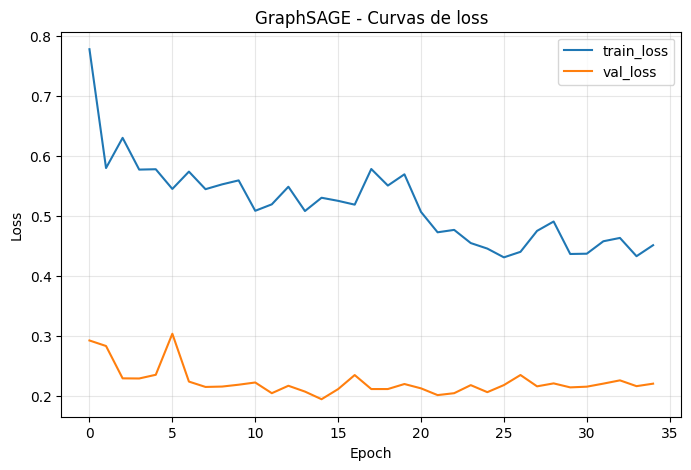

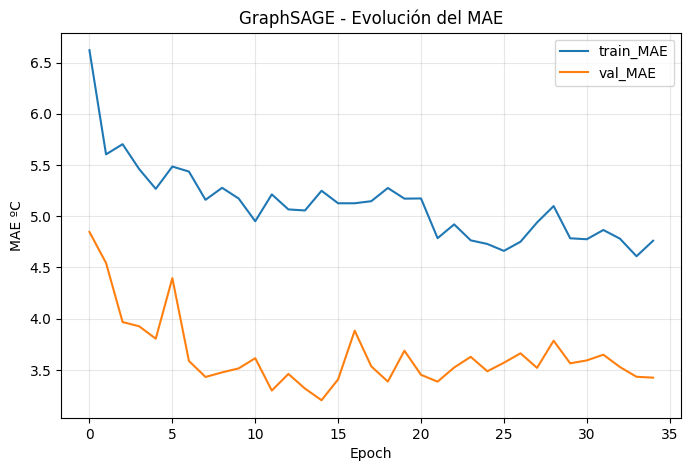

In [ ]:
# ============================================================
# 6. GRÁFICAS DE ENTRENAMIENTO
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GraphSAGE - Curvas de loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_MAE"], label="train_MAE")
plt.plot(history["val_MAE"], label="val_MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE ºC")
plt.title("GraphSAGE - Evolución del MAE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#9. GCN + GRU

In [ ]:
!pip install -q torch-geometric

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import time


BATCH_SIZE = 8

class SpatioTemporalWindowDataset(Dataset):
    def __init__(self, X, y, mask, target_time_indices, seq_len):
        self.X = X
        self.y = y
        self.mask = mask
        self.target_time_indices = sorted(list(target_time_indices))
        self.seq_len = seq_len

        self.samples = []

        for t in self.target_time_indices:
            start = t - seq_len + 1
            end = t + 1

            if start >= 0:
                context = list(range(start, end))
                self.samples.append((context, t))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        context, target_t = self.samples[idx]

        return {
            "x_seq": self.X[context],        # [S, N, F]
            "y": self.y[target_t],           # [N]
            "mask": self.mask[target_t],     # [N]
            "target_t": target_t
        }


train_dataset = SpatioTemporalWindowDataset(X, y, mask, train_time_idx, SEQ_LEN)
val_dataset   = SpatioTemporalWindowDataset(X, y, mask, val_time_idx, SEQ_LEN)
test_dataset  = SpatioTemporalWindowDataset(X, y, mask, test_time_idx, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Ventanas train:", len(train_dataset))
print("Ventanas val:", len(val_dataset))
print("Ventanas test:", len(test_dataset))

Ventanas train: 442
Ventanas val: 24
Ventanas test: 25


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv


# ==========================================================
# DROPEDGE
# ==========================================================

def drop_edge(edge_index, drop_prob=0.15, training=True):
    if (not training) or drop_prob <= 0:
        return edge_index

    num_edges = edge_index.size(1)
    keep_mask = torch.rand(num_edges, device=edge_index.device) > drop_prob

    return edge_index[:, keep_mask]


# ==========================================================
# MODELO REGULARIZADO: GCN + GRU
# ==========================================================

class Regularized_GCN_GRU_LSTPredictor(nn.Module):
    def __init__(
        self,
        in_channels,
        gcn_hidden=32,
        gru_hidden=32,
        dropout=0.35,
        edge_dropout=0.15
    ):
        super().__init__()

        self.edge_dropout = edge_dropout
        self.dropout = dropout

        # Menos capacidad que el modelo anterior
        self.gcn1 = GCNConv(in_channels, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)

        self.norm1 = nn.LayerNorm(gcn_hidden)
        self.norm2 = nn.LayerNorm(gcn_hidden)

        self.gru = nn.GRU(
            input_size=gcn_hidden,
            hidden_size=gru_hidden,
            num_layers=1,
            batch_first=True,
            dropout=0.0
        )

        self.temporal_norm = nn.LayerNorm(gru_hidden)

        self.head = nn.Sequential(
            nn.Linear(gru_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def encode_graph(self, x_t, edge_index):
        edge_index_used = drop_edge(
            edge_index,
            drop_prob=self.edge_dropout,
            training=self.training
        )

        h = self.gcn1(x_t, edge_index_used)
        h = self.norm1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.gcn2(h, edge_index_used)
        h = self.norm2(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        return h

    def forward(self, x_seq, edge_index):
        # x_seq: [B, S, N, F]
        B, S, N, F_in = x_seq.shape

        temporal_embeddings = []

        for s in range(S):
            x_t = x_seq[:, s]  # [B, N, F]

            batch_emb = []
            for b in range(B):
                h = self.encode_graph(x_t[b], edge_index)
                batch_emb.append(h)

            batch_emb = torch.stack(batch_emb, dim=0)  # [B, N, H]
            temporal_embeddings.append(batch_emb)

        h_seq = torch.stack(temporal_embeddings, dim=2)  # [B, N, S, H]
        h_seq = h_seq.reshape(B * N, S, -1)

        gru_out, _ = self.gru(h_seq)

        last_h = gru_out[:, -1, :]
        last_h = self.temporal_norm(last_h)

        pred = self.head(last_h).reshape(B, N)

        return pred

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = Regularized_GCN_GRU_LSTPredictor(
    in_channels=X.shape[-1],
    gcn_hidden=64,
    gru_hidden=64,
    dropout=0.20,
    edge_dropout=0.05

).to(device)

edge_index_device = edge_index.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    weight_decay=1e-3,
    lr=7e-4
)

loss_fn = torch.nn.SmoothL1Loss(beta=0.5)


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    total_nodes = 0

    for batch in loader:
        x_seq = batch["x_seq"].to(device)
        y_true = batch["y"].to(device)
        mask_b = batch["mask"].to(device)

        optimizer.zero_grad()

        y_pred = model(x_seq, edge_index_device)

        loss = loss_fn(y_pred[mask_b], y_true[mask_b])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * mask_b.sum().item()
        total_nodes += mask_b.sum().item()

    return total_loss / total_nodes


@torch.no_grad()
def evaluate_scaled(model, loader):
    model.eval()
    total_loss = 0
    total_nodes = 0

    for batch in loader:
        x_seq = batch["x_seq"].to(device)
        y_true = batch["y"].to(device)
        mask_b = batch["mask"].to(device)

        y_pred = model(x_seq, edge_index_device)

        loss = loss_fn(y_pred[mask_b], y_true[mask_b])

        total_loss += loss.item() * mask_b.sum().item()
        total_nodes += mask_b.sum().item()

    return total_loss / total_nodes

Device: cuda


In [ ]:
date_strings = pd.to_datetime(dates).strftime("%Y-%m-%d")

landsat_train_time_idx = np.where(
    np.isin(date_strings, landsat_train_dates)
)[0]

landsat_train_dataset = SpatioTemporalWindowDataset(
    X, y, mask,
    landsat_train_time_idx,
    SEQ_LEN
)

landsat_train_loader = DataLoader(
    landsat_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Ventanas Landsat train:", len(landsat_train_dataset))

Ventanas Landsat train: 106


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

MAX_EPOCHS = 200
PATIENCE = 15
MIN_DELTA = 1e-4

best_val_mae = float("inf")
best_state = None
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": [],
    "train_r2": [],
    "val_r2": []
}


@torch.no_grad()
def compute_metrics(model, loader):
    model.eval()

    preds_all = []
    trues_all = []

    total_loss = 0
    total_nodes = 0

    for batch in loader:
        x_seq = batch["x_seq"].to(device)
        y_true = batch["y"].to(device)
        mask_b = batch["mask"].to(device)

        y_pred = model(x_seq, edge_index_device)

        loss = loss_fn(y_pred[mask_b], y_true[mask_b])

        total_loss += loss.item() * mask_b.sum().item()
        total_nodes += mask_b.sum().item()

        preds_all.append(y_pred[mask_b].detach().cpu().numpy())
        trues_all.append(y_true[mask_b].detach().cpu().numpy())

    preds_all = np.concatenate(preds_all)
    trues_all = np.concatenate(trues_all)

    mae = mean_absolute_error(trues_all, preds_all)
    r2 = r2_score(trues_all, preds_all)

    mean_loss = total_loss / total_nodes

    return mean_loss, mae, r2

start_time_gcngru = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):

    train_loss = train_one_epoch(model, train_loader)

    train_loss_eval, train_mae, train_r2 = compute_metrics(model, train_loader)
    val_loss, val_mae, val_r2 = compute_metrics(model, val_loader)

    history["train_loss"].append(train_loss_eval)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)
    history["train_r2"].append(train_r2)
    history["val_r2"].append(val_r2)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train MAE: {train_mae:.4f} | "
            f"Val MAE: {val_mae:.4f} | "
            f"Val R2: {val_r2:.4f}"
        )

    if patience_counter >= PATIENCE:
        print(f"Early stopping en epoch {epoch}")
        break

total_training_time_gcngru = time.perf_counter() - start_time_gcngru
n_epochs_gcngru = len(history["train_loss"])
model.load_state_dict(best_state)
print("Mejor val MAE:", best_val_mae)

Epoch 001 | Train MAE: 0.4013 | Val MAE: 0.2894 | Val R2: 0.6704
Epoch 010 | Train MAE: 0.3422 | Val MAE: 0.2623 | Val R2: 0.6209
Epoch 020 | Train MAE: 0.2645 | Val MAE: 0.2685 | Val R2: 0.5747
Early stopping en epoch 26
Mejor val MAE: 0.24953605234622955


In [ ]:
# ==========================================================
# TEST
# ==========================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

@torch.no_grad()
def predict_loader_real_scale(model, loader, scaler_y):
    model.eval()

    preds_all = []
    trues_all = []

    for batch in loader:
        x_seq = batch["x_seq"].to(device)
        y_true = batch["y"].to(device)
        mask_b = batch["mask"].to(device)

        y_pred = model(x_seq, edge_index_device)

        pred_valid = (
            y_pred[mask_b]
            .detach()
            .cpu()
            .numpy()
            .reshape(-1, 1)
        )

        true_valid = (
            y_true[mask_b]
            .detach()
            .cpu()
            .numpy()
            .reshape(-1, 1)
        )

        pred_real = scaler_y.inverse_transform(pred_valid).ravel()
        true_real = scaler_y.inverse_transform(true_valid).ravel()

        preds_all.append(pred_real)
        trues_all.append(true_real)

    preds_all = np.concatenate(preds_all)
    trues_all = np.concatenate(trues_all)

    return preds_all, trues_all


# Predicciones en escala real
y_pred_test, y_true_test = predict_loader_real_scale(
    model,
    test_loader,
    scaler_y
)

# Métricas
test_metrics = {
    "RMSE": np.sqrt(mean_squared_error(y_true_test, y_pred_test)),
    "MAE": mean_absolute_error(y_true_test, y_pred_test),
    "R2": r2_score(y_true_test, y_pred_test),
    "MAPE": np.mean(
        np.abs(
            (y_true_test - y_pred_test)
            / np.maximum(np.abs(y_true_test), 1e-8)
        )
    ) * 100
}

print("\n===== TEST ANTES DEL FINE-TUNING =====")

for k, v in test_metrics.items():
    if k == "MAPE":
        print(f"{k}: {v:.2f}%")
    else:
        print(f"{k}: {v:.4f}")

# Guardar en CSV común
save_model_test_results(
    model_name="GCN_GRU",
    total_training_time_s=total_training_time_gcngru,
    n_epochs=n_epochs_gcngru,
    test_metrics=test_metrics
)


===== TEST ANTES DEL FINE-TUNING =====
RMSE: 3.8337
MAE: 2.4515
R2: 0.6694
MAPE: 7.16%
Resultados acumulados guardados en:
/content/drive/MyDrive/TFM/model_results_summary.csv


,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE,sentinel_ratio,seq_len
0,XGBoost,2.337024,126,0.018548,3.071004,4.298590,0.584298,8.186274,3,NaN
1,GCN,27.936010,53,0.527095,2.303982,3.715620,0.689407,6.796395,3,NaN
2,GCN_GRU,430.489783,33,13.045145,2.266650,3.620564,0.705095,6.559174,3,NaN
3,XGBoost,1.586087,69,0.022987,2.480746,3.592164,0.709703,7.042518,1,NaN
4,GCN,26.592134,37,0.718706,2.427666,3.828797,0.670197,7.218503,1,NaN
5,GCN_GRU,201.691587,26,7.757369,2.602865,3.931059,0.652345,7.479530,1,NaN
6,XGBoost,2.289224,641,0.003571,2.815163,4.023797,0.635748,8.010942,0,NaN
7,GCN,3.104944,40,0.077624,2.198127,3.374826,0.743769,6.332814,0,NaN
8,GCN_GRU,129.083542,37,3.488744,3.110610,4.495594,0.545322,8.952583,0,NaN
9,XGBoost,3.157494,170,0.018573,2.904734,3.837335,0.668725,7.971094,2,NaN


#10. Comparativa de resultados

In [ ]:
# ============================================================
# CARGAR Y VISUALIZAR TODOS LOS RESULTADOS
# ============================================================

import pandas as pd

RESULTS_PATH = "/content/drive/MyDrive/TFM/model_results_summary.csv"

results_df = pd.read_csv(RESULTS_PATH)

# Ordenar por RMSE (mejor arriba)
results_df = results_df.sort_values(
    "test_RMSE"
).reset_index(drop=True)

display(results_df)

print("\nNúmero de modelos:", len(results_df))

,model,total_training_time_s,n_epochs,seconds_per_epoch,test_MAE,test_RMSE,test_R2,test_MAPE
0,GCN_GRU,316.143063,27,11.709002,2.249449,3.547467,0.716883,6.450861
1,GCN_GRU_finetuned,344.405699,33,10.436536,2.249449,3.547467,0.716883,6.450861
2,GCN,13.477374,52,0.259180,2.428113,3.715995,0.689344,6.932085
3,Graph Sage,18.840024,39,0.483078,2.598989,3.902543,0.657370,7.566226
4,XGBoost,2.075494,126,0.016472,3.071004,4.298590,0.584298,8.186274
5,lstm_baseline,586.854853,9,65.206095,4.150006,5.125772,0.479485,0.113313
6,gru_baseline,302.100588,9,33.566732,4.264493,5.284193,0.446813,0.115256
7,gru_stacked,673.754138,9,74.861571,4.563125,5.695856,0.357264,0.121364
8,lstm_stacked,711.569589,9,79.063288,4.396811,5.774134,0.339477,0.118456



Número de modelos: 9


In [ ]:
# ============================================================
# TABLA RESUMEN PARA MEMORIA
# ============================================================

summary_df = results_df[[
    "model",
    "test_RMSE",
    "test_MAE",
    "test_R2",
    "test_MAPE",
    "total_training_time_s",
    "n_epochs",
    "seconds_per_epoch"
]].copy()

summary_df = summary_df.sort_values(
    "test_RMSE"
).reset_index(drop=True)

display(summary_df.round(4))

,model,test_RMSE,test_MAE,test_R2,test_MAPE,total_training_time_s,n_epochs,seconds_per_epoch
0,GCN_GRU,3.5475,2.2494,0.7169,6.4509,316.1431,27,11.7090
1,GCN_GRU_finetuned,3.5475,2.2494,0.7169,6.4509,344.4057,33,10.4365
2,GCN,3.7160,2.4281,0.6893,6.9321,13.4774,52,0.2592
3,Graph Sage,3.9025,2.5990,0.6574,7.5662,18.8400,39,0.4831
4,XGBoost,4.2986,3.0710,0.5843,8.1863,2.0755,126,0.0165
5,lstm_baseline,5.1258,4.1500,0.4795,0.1133,586.8549,9,65.2061
6,gru_baseline,5.2842,4.2645,0.4468,0.1153,302.1006,9,33.5667
7,gru_stacked,5.6959,4.5631,0.3573,0.1214,673.7541,9,74.8616
8,lstm_stacked,5.7741,4.3968,0.3395,0.1185,711.5696,9,79.0633


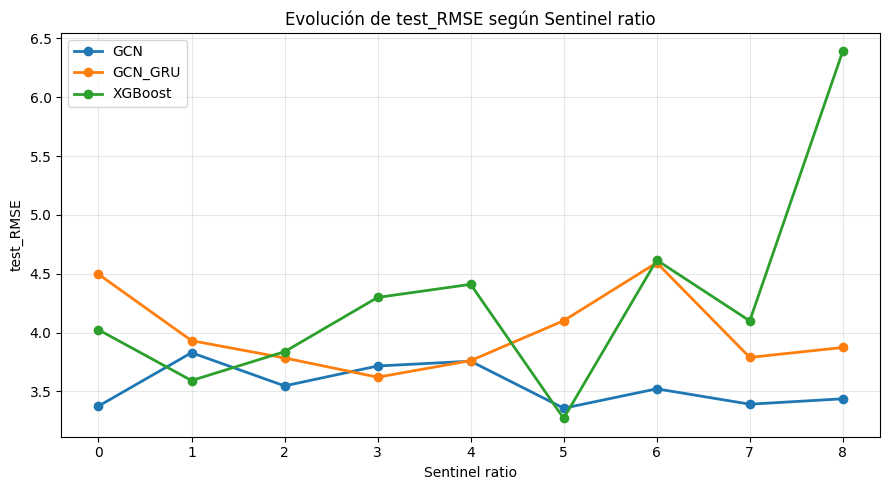

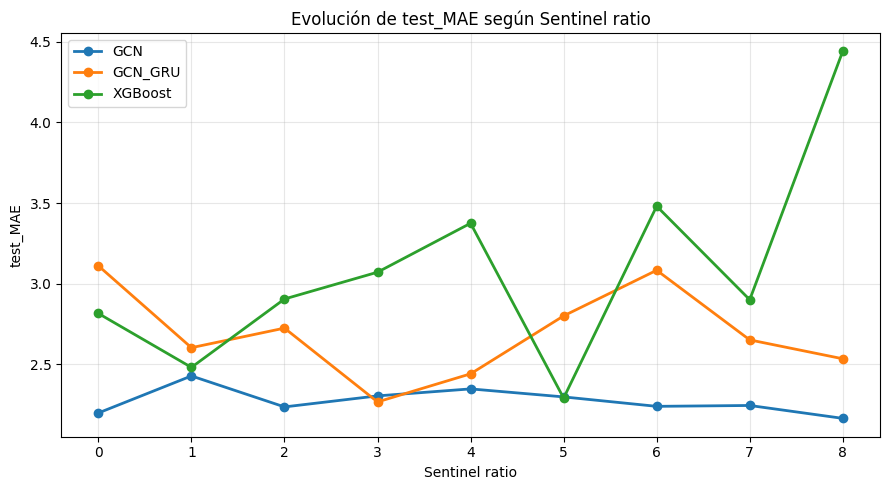

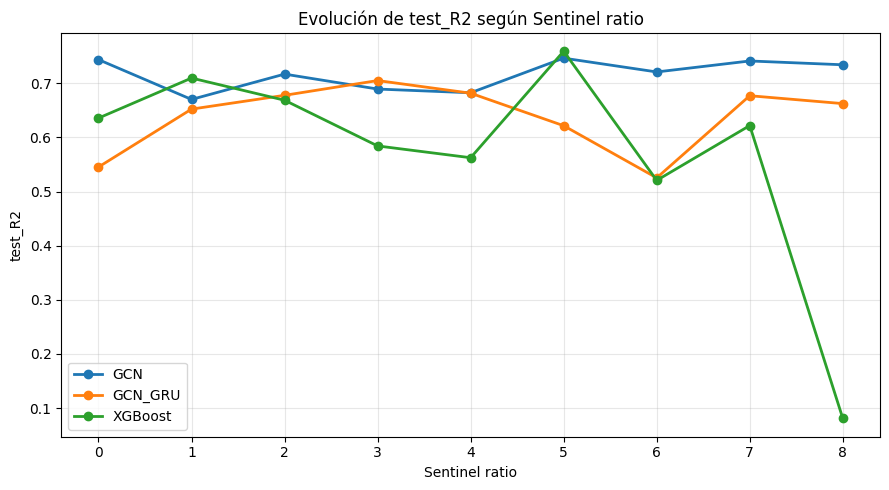

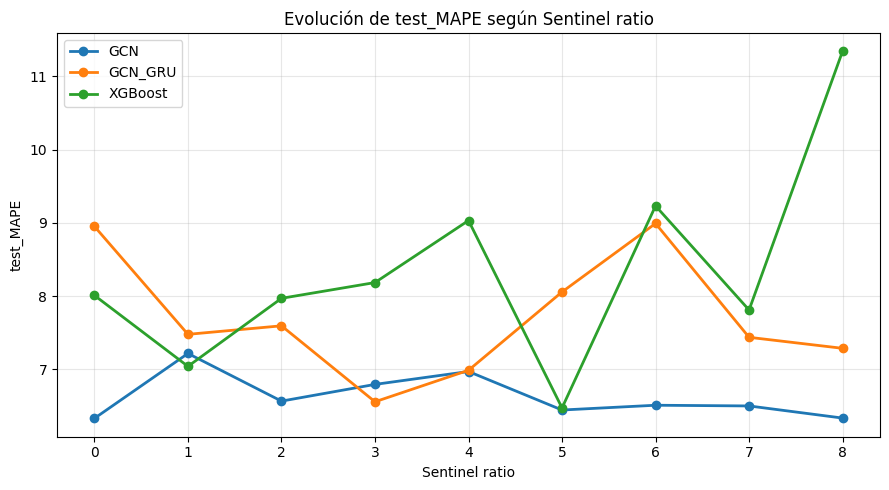

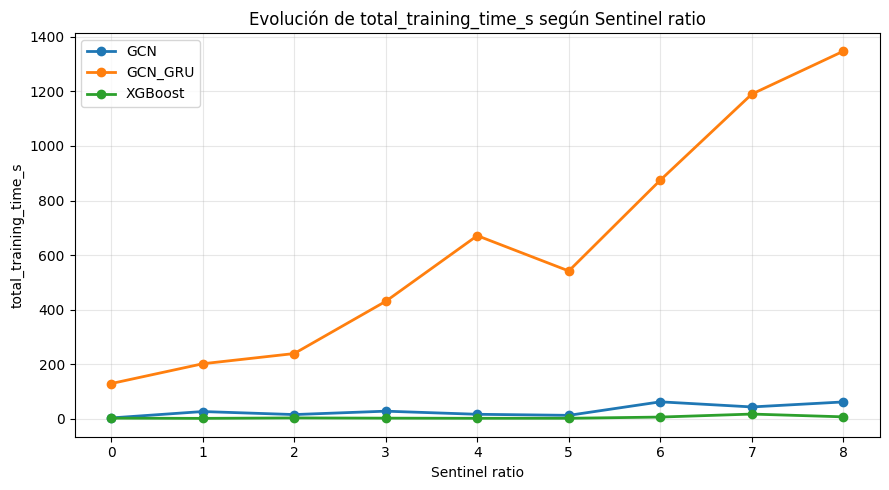

In [ ]:
# ============================================================
# GRÁFICAS MÉTRICAS vs SENTINEL_RATIO
# Una gráfica por métrica, con todos los modelos
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = "/content/drive/MyDrive/TFM/model_results_summary.csv"

df_results = pd.read_csv(RESULTS_PATH)

# Asegurar tipos correctos
df_results["sentinel_ratio"] = pd.to_numeric(
    df_results["sentinel_ratio"],
    errors="coerce"
)

# Métricas de test a representar
metrics = [
    "test_RMSE",
    "test_MAE",
    "test_R2",
    "test_MAPE",
    "total_training_time_s"
]

# Limpiar posibles filas sin sentinel_ratio
df_plot = df_results.dropna(
    subset=["sentinel_ratio"]
).copy()

df_plot = df_plot.sort_values(
    ["model", "sentinel_ratio"]
)

for metric in metrics:

    plt.figure(figsize=(9, 5))

    for model_name, df_model in df_plot.groupby("model"):

        plt.plot(
            df_model["sentinel_ratio"],
            df_model[metric],
            marker="o",
            linewidth=2,
            label=model_name
        )

    plt.title(f"Evolución de {metric} según Sentinel ratio")
    plt.xlabel("Sentinel ratio")
    plt.ylabel(metric)
    plt.xticks(sorted(df_plot["sentinel_ratio"].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()